<a href="https://colab.research.google.com/github/aislam2346/aislam/blob/main/NYC_Taxi_Drift_Pipeline_FINAL_SUBMISSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Section 1: Setup

In [ ]:
# Fix for numpy/numba compatibility issue by explicitly managing versions
# !pip uninstall numba numpy -y
# !pip install "numpy<2.0.0"
# !pip install "numba>=0.61"
# !pip install shap
# !pip install river
# !pip install "numba>=0.61" river shap --upgrade

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import duckdb
import pandas as pd
import numpy as np
import requests
import os
import hashlib
import json
import gc
import shutil
import holidays
from calendar import month_name
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pickle
import joblib
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from scipy.stats import ks_2samp, chi2_contingency, spearmanr
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import warnings
import math
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

warnings.filterwarnings('ignore')


In [ ]:
# ── Define file inputs and outputs for this script ─────────────────────────────────────────────────────────────────────
# This will be used for cleaning folders once pipeline is ready

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Raw parquet files — where TLC files live on your Drive
PARQUET_DIR = Path("/content/drive/MyDrive/ODATA57078/nyc_taxi_parquet_files")

# Support files
ZONE_LOOKUP_PATH = Path("/content/drive/MyDrive/ODATA57078/taxi_zone_lookup.csv")

ZONE_LOOKUP_SHP_PATH = Path("/content/drive/MyDrive/ODATA57078/taxi_zones")

# Output folders — created automatically if missing
BASE     = Path("/content/drive/MyDrive/ODATA57078")
STAGING_DIR = BASE / "staging"       # one parquet per month, e.g. staging/2019-01.parquet
GOLD_DIR = BASE / "gold"          # one parquet per month, e.g. gold/2019-01.parquet
FEAT_DIR = BASE / "features"      # final modeling table
CKPT_DIR = BASE / "checkpoints"   # watermark.json lives here
OUT_DIR  = BASE / "eda_outputs"   # saved plots
MODEL_DIR = BASE / "models"       # saved models
PREDICT_DIR = BASE / "predictions" # saved predictions
DRIFT_DIR = BASE / "drift_outputs" # saved drift outputs

for d in [STAGING_DIR, GOLD_DIR, FEAT_DIR, CKPT_DIR, OUT_DIR, PREDICT_DIR, DRIFT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── DuckDB — lives in /tmp, NOT on Drive ─────────────────────────────────────
# /tmp is wiped when Colab disconnects, which is fine
# staging and gold parquet files on Drive are the real persistent storage.
DB_PATH = Path("/tmp/taxi_work.duckdb")  # fast working copy

def get_connection():
    con = duckdb.connect(DB_PATH)
    con.execute("PRAGMA threads=4")
    con.execute("PRAGMA memory_limit='3GB'")
    return con

# ── Months to process ────────────────────────────────────────────────────────
# The watermark means already-completed months are always skipped.
MONTHS_TO_INGEST = [
    '2019-01', '2019-02', '2019-03',
    '2019-04', '2019-05', '2019-06',
    '2019-07', '2019-08', '2019-09',
    '2019-10', '2019-11', '2019-12',
    '2020-01', '2020-02', '2020-03',
    '2020-04', '2020-05', '2020-06',
    '2020-07', '2020-08', '2020-09',
    '2020-10', '2020-11', '2020-12',
    '2021-01'
]

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130, 'axes.titlesize': 11, 'axes.labelsize': 9,
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': '#aaaaaa', 'ytick.color': '#aaaaaa',
})
COLORS = {
    'primary': '#4C9BE8', 'secondary': '#F5A623',
    'green': '#50C878',   'purple': '#A78BFA', 'red': '#E85D75',
}

print("Section 1 complete — paths and imports ready")
print(f"   GOLD_DIR : {GOLD_DIR}")
print(f"   DB_PATH  : {DB_PATH}  (local /tmp — not on Drive)")

Section 1 complete — paths and imports ready
   GOLD_DIR : /content/drive/MyDrive/ODATA57078/gold
   DB_PATH  : /tmp/taxi_work.duckdb  (local /tmp — not on Drive)


In [4]:
# Read saved parquet files
df_gold_2019 = pd.read_parquet(GOLD_DIR / 'all_gold_2019.parquet')
df_zone_2019 = pd.read_parquet(FEAT_DIR / 'all_zone_aggregated_2019.parquet')
df_gold_2020 = pd.read_parquet(GOLD_DIR / 'all_gold_2020.parquet')
df_zone_2020 = pd.read_parquet(FEAT_DIR / 'all_zone_aggregated_2020.parquet')

In [5]:
# Save results
df_2020_dat_with_trained_feats_only = pd.read_parquet(PREDICT_DIR / "2020_predictions_with_top_3_boroughs_only.parquet")
baseline_model_data_with_prepared_feats = pd.read_parquet(PREDICT_DIR / "2019_data_with_top_3_boroughs_only.parquet")

In [ ]:
# Retrieve predictions and new 2020 data
df_2019 = pd.read_parquet(PREDICT_DIR / "2019_data_with_top_3_boroughs_only.parquet")
df_2020 = pd.read_parquet(PREDICT_DIR / "2020_predictions_with_top_3_boroughs_only.parquet")

df_2019['pickup_hour_ts'] = pd.to_datetime(df_2019['pickup_hour_ts'])
df_2020['pickup_hour_ts'] = pd.to_datetime(df_2020['pickup_hour_ts'])

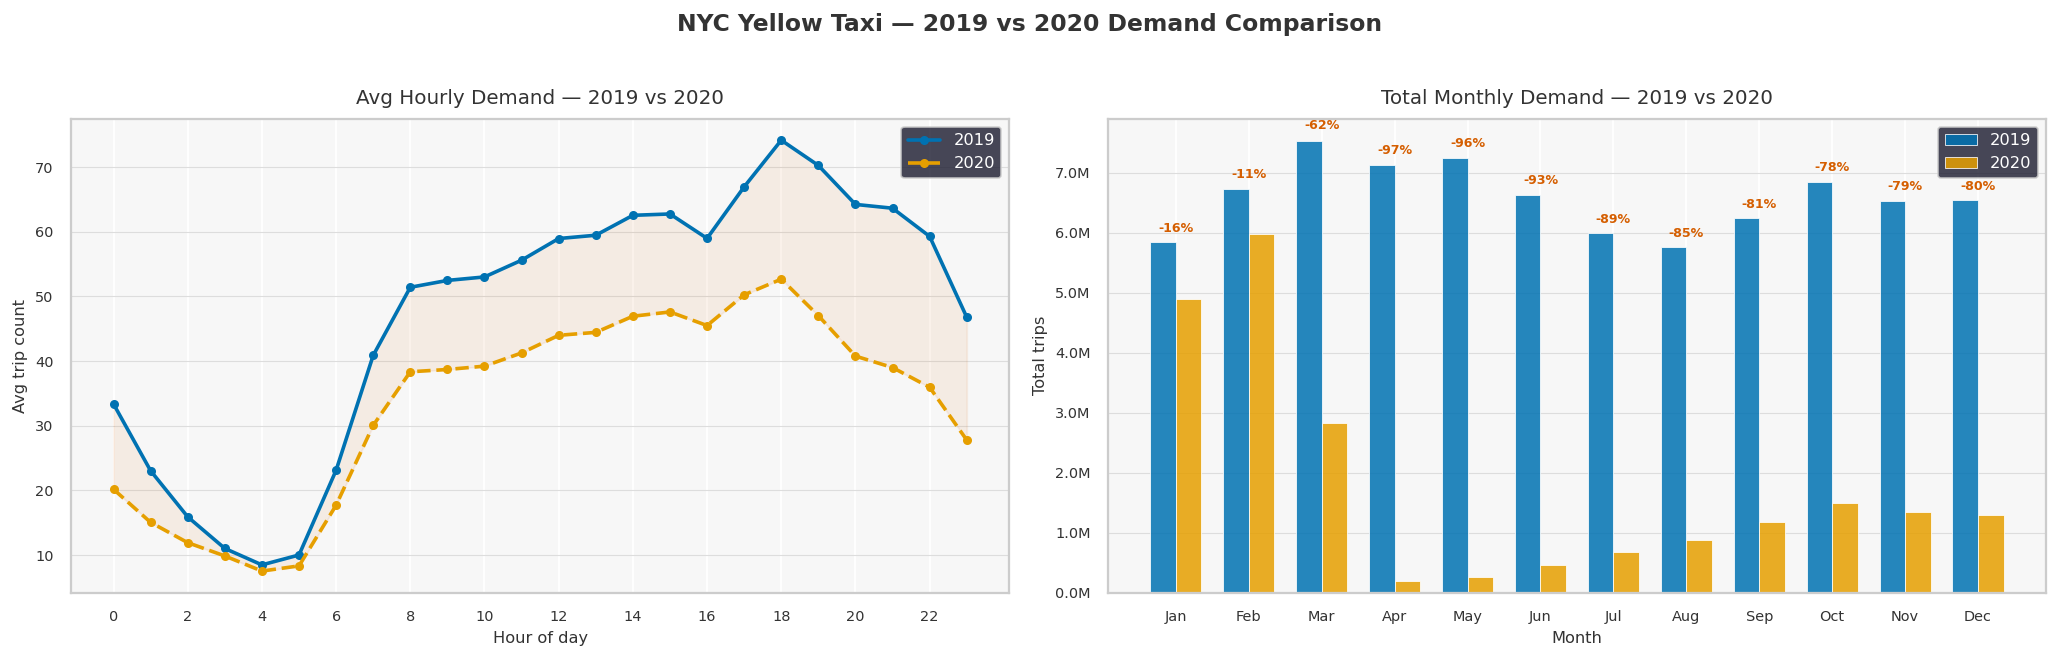

In [ ]:
# ── Aggregations ──────────────────────────────────────────────────────────────
hourly_2019 = df_2019.groupby('hour_of_day')['trip_count'].mean()
hourly_2020 = df_2020.groupby('hour_of_day')['trip_count'].mean()

monthly_2019 = df_2019.groupby(df_2019['pickup_hour_ts'].dt.month)['trip_count'].sum()
monthly_2020 = df_2020.groupby(df_2020['pickup_hour_ts'].dt.month)['trip_count'].sum()

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

# ── Palette ───────────────────────────────────────────────────────────────────
C19 = '#0072B2'   # deep blue — 2019
C20 = '#E69F00'   # orange    — 2020

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE — side by side
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

for ax in axes:
    ax.set_facecolor('#f7f7f7')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    ax.tick_params(colors='#333333', labelsize=8)
    ax.yaxis.label.set_color('#333333')
    ax.xaxis.label.set_color('#333333')
    ax.grid(axis='y', color='#dddddd', linewidth=0.6)

# ── Panel A: Hourly ───────────────────────────────────────────────────────────
ax = axes[0]

ax.plot(hourly_2019.index, hourly_2019.values,
        color=C19, linewidth=2, marker='o', markersize=4, label='2019')
ax.plot(hourly_2020.index, hourly_2020.values,
        color=C20, linewidth=2, marker='o', markersize=4,
        linestyle='--', label='2020')

ax.fill_between(hourly_2019.index,
                hourly_2019.values,
                hourly_2020.values,
                alpha=0.08, color='#D55E00')

ax.set_title('Avg Hourly Demand — 2019 vs 2020',
             fontsize=11, pad=8, color='#333333')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Avg trip count')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=9, framealpha=0.8)

# ── Panel B: Monthly ──────────────────────────────────────────────────────────
ax = axes[1]

x     = np.arange(12)
width = 0.35

bars_2019 = ax.bar(x - width/2, monthly_2019.values,
                    width, color=C19, alpha=0.85,
                    label='2019', edgecolor='white', linewidth=0.5)
bars_2020 = ax.bar(x + width/2, monthly_2020.values,
                    width, color=C20, alpha=0.85,
                    label='2020', edgecolor='white', linewidth=0.5)

# Percentage change labels
for i, (v19, v20) in enumerate(zip(monthly_2019.values, monthly_2020.values)):
    pct    = (v20 - v19) / v19 * 100
    colour = '#D55E00' if pct < 0 else '#009E73'
    ax.text(i, max(v19, v20) * 1.02,
            f'{pct:+.0f}%',
            ha='center', va='bottom',
            fontsize=7, color=colour, fontweight='bold')

ax.set_title('Total Monthly Demand — 2019 vs 2020',
             fontsize=11, pad=8, color='#333333')
ax.set_xlabel('Month')
ax.set_ylabel('Total trips')
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
ax.legend(fontsize=9, framealpha=0.8)

plt.suptitle('NYC Yellow Taxi — 2019 vs 2020 Demand Comparison',
             fontsize=13, fontweight='bold', y=1.01, color='#333333')
plt.tight_layout()
plt.savefig(OUT_DIR / 'demand_2019_vs_2020.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# # Run this chunk to read saved objects generated in subsequent steps such as baseline modelling
# # and drift detection preparation

# # 1. HISTORICAL FEATURES
# # Load saved features parquet
# df_2019 = pd.read_parquet(FEAT_DIR/ "df_2019_features.parquet")
# # display(df_2019.head())

# # 2. BASELINE MODELLING
# # Load saved model
# with open(MODEL_DIR / "model_with_more_features.pkl", "rb") as f:
#   baseline_model = pickle.load(f)
# print(f" Model loaded — best iteration: {baseline_model.best_iteration_}")

# # Model prediction tables

# # Read from parquets
# df_2020_model = pd.read_parquet(BASE / "predictions" / "2020_predictions_full.parquet")
# # display(df_2020_model.head())

# # 3. DRIFT ANALYSIS
# # Read saved drift detection data
# DRIFT_DATA = BASE / 'drift_data'
# # drift_data_parquet_directory = DRIFT_DATA / "full_drift_data_no_boundary_rows.parquet"
# drift_data_parquet_directory = DRIFT_DATA / "drift_data_with_more_feat_no_boundary_rows.parquet"
# df_drift = pd.read_parquet(drift_data_parquet_directory)

# # Read drift data saved in csv files

# # Monthly Drift table
# monthly_drift = pd.read_csv(DRIFT_DIR / "monthly_drift_table.csv")
# # display(monthly_drift.head(20))

# # Overall Drift table
# overall_drift_table = pd.read_csv(DRIFT_DIR / "overall_drift_table.csv")
# # display(overall_drift_table.head(20))


In [ ]:
# 1. HISTORICAL FEATURES
# Load saved features parquet
# df_2019 = pd.read_parquet(FEAT_DIR/ "df_2019_features.parquet")
# display(df_2019.head())

In [ ]:
# df_2019.info()

In [ ]:
# df_2020_model.info()

In [ ]:
# # Print out baseline model metadata

# # Get Parameters
# params = baseline_model.get_params()
# print("Parameters:")
# for param, value in params.items():
#     print(f"{param}: {value}")

# # Get feature names
# feature_names = baseline_model.feature_name_
# print("\nFeature Names:")
# print(feature_names)

# # Get feature importance
# feature_importance = baseline_model.feature_importances_
# print("\nFeature Importance:")
# print(feature_importance)

In [ ]:
# df_2020_model = pd.read_parquet(BASE / "predictions" / "2020_predictions_full.parquet")

# # print(type(df_2020_model))  # Should show <class 'pandas.core.frame.DataFrame'>
# # if df_2020_model is not None:
# #     print(df_2020_model.columns)

## Section 2: Define Schema and Watermark

In [ ]:
# ── Schema bootstrap ──────────────────────────────────────────────────────────
# raw_taxi_trips and staging_taxi_trips are TEMP tables — they exist only
# for the duration of processing one month, then disappear automatically.
# gold_hourly_demand and weather_hourly are permanent in /tmp DuckDB,
# but their durable copy is the parquet files on Drive.

def bootstrap_schema(con):
    """Create all tables. Safe to call every session — idempotent."""

    # Watermark — tracks what has been ingested (permanent, small)
    con.execute("""
        CREATE TABLE IF NOT EXISTS pipeline_watermark (
            file_name   VARCHAR PRIMARY KEY,
            file_month  VARCHAR,
            checksum    VARCHAR,
            row_count   BIGINT,
            ingested_at TIMESTAMP,
            layer       VARCHAR
        )
    """)

    # Raw — TEMP: holds one month of raw parquet data during processing
    # Dropped automatically when the connection closes
    con.execute("""
        CREATE TEMP TABLE IF NOT EXISTS raw_taxi_trips (
            VendorID              INTEGER,
            tpep_pickup_datetime  TIMESTAMP,
            tpep_dropoff_datetime TIMESTAMP,
            passenger_count       DOUBLE,
            trip_distance         DOUBLE,
            RatecodeID            DOUBLE,
            store_and_fwd_flag    VARCHAR,
            PULocationID          INTEGER,
            DOLocationID          INTEGER,
            payment_type          BIGINT,
            fare_amount           DOUBLE,
            extra                 DOUBLE,
            mta_tax               DOUBLE,
            tip_amount            DOUBLE,
            tolls_amount          DOUBLE,
            improvement_surcharge DOUBLE,
            total_amount          DOUBLE,
            congestion_surcharge  DOUBLE,
            airport_fee           DOUBLE,
            file_name             VARCHAR,
            file_month            VARCHAR,
            ingested_at           TIMESTAMP
        )
    """)

    # Staging : holds one month of cleaned data during processing
    con.execute("""
        CREATE TEMP TABLE IF NOT EXISTS staging_taxi_trips (
            VendorID              INTEGER,
            tpep_pickup_datetime  TIMESTAMP,
            tpep_dropoff_datetime TIMESTAMP,
            passenger_count       INTEGER,
            trip_distance         DOUBLE,
            PULocationID          INTEGER,
            DOLocationID          INTEGER,
            payment_type          INTEGER,
            fare_amount           DOUBLE,
            tip_amount            DOUBLE,
            total_amount          DOUBLE,
            congestion_surcharge  DOUBLE,
            trip_duration_mins    DOUBLE,
            pickup_hour           INTEGER,
            pickup_dow            INTEGER,
            pickup_month          INTEGER,
            is_weekend            BOOLEAN,
            time_of_day           VARCHAR,
            file_month            VARCHAR,
            ingested_at           TIMESTAMP,
            rowhash               VARCHAR
        )
    """)

    # Gold — permanent in DuckDB session, but real persistence is parquet on Drive
    # Removed weather details - temporary fix.
    con.execute("""
      CREATE OR REPLACE TABLE gold_hourly_demand (
          pickup_hour_ts       TIMESTAMP,
          file_month           VARCHAR,
          PULocationID         INTEGER,
          borough              VARCHAR,
          service_zone         VARCHAR,
          zone                 VARCHAR,
          trip_count           BIGINT,
          pct_card_payment     DOUBLE,
          pct_cash_payment     DOUBLE,
          avg_trip_distance    DOUBLE,
          avg_fare_amount      DOUBLE,
          avg_duration_mins    DOUBLE,
          avg_passenger_count  DOUBLE,
          hour_of_day          INTEGER,
          day_of_week          INTEGER,
          is_weekend           BOOLEAN,
          is_holiday           BOOLEAN
      )
""")

    # Schema for aggregated results by zone and hour for EDA and modelling
    # same as gold, removed weather details
    con.execute("""
    CREATE OR REPLACE TABLE zone_features (
        pickup_hour_ts        TIMESTAMP,
        file_month            VARCHAR,
        borough               VARCHAR,
        service_zone          VARCHAR,
        zone                  VARCHAR,
        trip_count            BIGINT,
        avg_trip_distance     DOUBLE,
        avg_fare_amount       DOUBLE,
        avg_duration_mins     DOUBLE,
        avg_passenger_count   DOUBLE,
        pct_card_payment      DOUBLE,
        pct_cash_payment      DOUBLE,
        hour_of_day           INTEGER,
        day_of_week           INTEGER,
        is_weekend            BOOLEAN,
        is_holiday            BOOLEAN
    )
  """)

    # Weather — permanent in DuckDB session (fetched once from API)
    # con.execute("""
    #     CREATE TABLE IF NOT EXISTS weather_hourly (
    #         weather_ts         TIMESTAMP PRIMARY KEY,
    #         temperature_2m     DOUBLE,
    #         precipitation      DOUBLE,
    #         snowfall           DOUBLE,
    #         windspeed_10m      DOUBLE,
    #         weathercode        INTEGER,
    #         is_snowing         BOOLEAN,
    #         is_raining         BOOLEAN,
    #         is_extreme_weather BOOLEAN
    #     )
    # """)

    print("  Schema bootstrapped (idempotent)")

In [ ]:
# ── Watermark — JSON on Drive, survives session restarts ──────────────────────
# Used to track ingestion progress - avoids re-ingestion of tables, and thus duplicates.
# The DuckDB watermark table above is kept as a within-session fast lookup.
# The JSON file on Drive is the source of truth across sessions.

WATERMARK_PATH = CKPT_DIR / "watermark.json"

def _load_watermark_json():
    """Load watermark from Drive JSON. Returns empty dict on first run."""
    if WATERMARK_PATH.exists():
        return json.loads(WATERMARK_PATH.read_text())
    return {}

def _save_watermark_json(wm: dict):
    """Persist watermark dict back to Drive JSON."""
    WATERMARK_PATH.write_text(json.dumps(wm, indent=2, default=str))

def check_gold_watermark_exists(file_month):
    """
    Check if the gold parquet for a given month is already marked as ingested
    in the persistent watermark (JSON on Drive).
    Returns (True, row_count) if exists and has rows, else (False, 0).
    """
    wm = _load_watermark_json()
    gold_key = f"gold::yellow_tripdata_{file_month}.parquet"
    if gold_key in wm and wm[gold_key]['row_count'] > 0:
        return True, wm[gold_key]['row_count']
    return False, 0

def is_already_processed(base_path, file_name, layer):
    """
    Check if a file exists physically AND is registered in the watermark JSON.
    """
    wm = _load_watermark_json()
    key = f"{layer}::{file_name}"

    # Use os.path.join for safety across different operating systems
    full_path = os.path.join(base_path, file_name)

    # Check 1: Does the file physically exist?
    file_exists = os.path.exists(full_path)

    # Check 2: Is it in the watermark?
    in_watermark = key in wm

    # Check 3: (Optional but recommended) Did it actually have rows?
    # This prevents skipping if a previous run crashed and left an empty file.
    has_rows = wm.get(key, {}).get('row_count', 0) > 0 if in_watermark else False

    return file_exists and in_watermark and has_rows

def file_checksum(path):
    """MD5 checksum of a file — detects if source data changed."""
    md5 = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(65536), b''):
            md5.update(chunk)
    return md5.hexdigest()

def is_already_processed(file_month):
    """
    Check if gold parquet for this month is registered in the watermark JSON with rows.
    """
    wm = _load_watermark_json()

    file_name = f"yellow_tripdata_{file_month}.parquet"
    gold_path = GOLD_DIR / f"{file_month}.parquet"
    zone_path = FEAT_DIR / f"zone_features_{file_month}.parquet"
    key       = f"gold::{file_name}"

    gold_file_exists  = gold_path.exists()
    zone_file_exists = zone_path.exists()

    file_exists = gold_file_exists and zone_file_exists
    in_watermark = key in wm
    has_rows     = wm.get(key, {}).get('row_count', 0) > 0

    return file_exists and in_watermark and has_rows

def mark_ingested(con, file_name, file_month, checksum, row_count, layer):
    """
    Write to both Drive JSON (persistent) and DuckDB table (fast lookup).
    """
    # Drive JSON — survives session restarts
    wm = _load_watermark_json()
    key = f"{layer}::{file_name}"
    wm[key] = {
        'file_name':   file_name,
        'file_month':  file_month,
        'checksum':    checksum,
        'row_count':   row_count,
        'ingested_at': str(datetime.now()),
        'layer':       layer,
    }
    _save_watermark_json(wm)

    # DuckDB table — fast within-session lookup
    con.execute("""
        INSERT INTO pipeline_watermark
            (file_name, file_month, checksum, row_count, ingested_at, layer)
        VALUES (?, ?, ?, ?, now(), ?)
        ON CONFLICT (file_name) DO UPDATE SET
            checksum    = excluded.checksum,
            row_count   = excluded.row_count,
            ingested_at = excluded.ingested_at,
            layer       = excluded.layer
    """, [file_name, file_month, checksum, row_count, layer])

def show_watermark():
    """Print all ingested files — useful for debugging and audit."""
    wm = _load_watermark_json()
    if not wm:
        print("  No watermark entries yet")
        return
    df = pd.DataFrame(wm.values()).sort_values(['layer', 'file_month'])
    display(df[['layer', 'file_month', 'file_name', 'row_count', 'ingested_at']])

print("Section 2 complete — schema and watermark functions ready")

Section 2 complete — schema and watermark functions ready


## Section 3: Define Ingestion Functions

In [ ]:
def ingest_raw(con, parquet_path, file_month):
    """
    Load one month parquet as-is into raw_taxi_trips TEMP table.
    Validates data integrity natively inside DuckDB before proceeding.
    """
    file_name = parquet_path.name
    checksum  = file_checksum(parquet_path)

    # 1. Idempotency Check / Cache Optimization
    current_temp_row_count = con.execute(
        "SELECT COUNT(*) FROM raw_taxi_trips WHERE file_month = ?", [file_month]
    ).fetchone()[0]

    if current_temp_row_count == 0:
        print(f"  Ingesting raw: {file_name}")

        # Idempotency safety: Clear out any partial remnants for this month before inserting
        con.execute("DELETE FROM raw_taxi_trips WHERE file_month = ?", [file_month])

        con.execute(f"""
            INSERT INTO raw_taxi_trips
            SELECT
                VendorID, tpep_pickup_datetime, tpep_dropoff_datetime,
                passenger_count, trip_distance, RatecodeID, store_and_fwd_flag,
                PULocationID, DOLocationID, payment_type, fare_amount, extra,
                mta_tax, tip_amount, tolls_amount, improvement_surcharge,
                total_amount,
                TRY_CAST(congestion_surcharge AS DOUBLE),
                TRY_CAST(airport_fee          AS DOUBLE),
                '{file_name}'  AS file_name,
                '{file_month}' AS file_month,
                now()          AS ingested_at
            FROM read_parquet('{parquet_path}')
        """)

        row_count = con.execute(
            "SELECT COUNT(*) FROM raw_taxi_trips WHERE file_month = ?", [file_month]
        ).fetchone()[0]

        mark_ingested(con, file_name, file_month, checksum, row_count, layer='raw')
        print(f"  Raw  | {file_name} | {row_count:,} rows loaded into TEMP")
    else:
        print(f"  Raw data for {file_month} already present in TEMP table, skipping reload.")

    # ==========================================
    # DATA VALIDATION TESTS (Executed in DuckDB)
    # ==========================================
    print(f"  Running data validation for {file_month}...")

    # Test 1: Schema Consistency
    # Checking if required core infrastructure columns exist in the loaded table
    expected_cols = {
        "vendorid", "tpep_pickup_datetime", "tpep_dropoff_datetime",
        "passenger_count", "trip_distance", "fare_amount", "total_amount", "file_month"
    }
    actual_cols = {row[1].lower() for row in con.execute(f"PRAGMA table_info('raw_taxi_trips')").fetchall()}
    missing_cols = expected_cols - actual_cols
    if missing_cols:
        raise ValueError(f"[VALIDATION FAILED] Missing critical columns in raw schema: {missing_cols}")

    # Test 2: Missing Values (Nulls in Critical Business Keys)
    null_counts = con.execute(f"""
        SELECT
            COUNT(*) FILTER (WHERE tpep_pickup_datetime IS NULL),
            COUNT(*) FILTER (WHERE tpep_dropoff_datetime IS NULL),
            COUNT(*) FILTER (WHERE file_month IS NULL)
        FROM raw_taxi_trips
        WHERE file_month = ?
    """, [file_month]).fetchone()

    if sum(null_counts) > 0:
        raise print(f"[WARNING] Critical nulls found! Pickup nulls: {null_counts[0]}, Dropoff nulls: {null_counts[1]}")

    # Test 3: Invalid / Negative Financial and Distance Values
    # Note: We allow 0 for distance/fare occasionally (system errors/cancelled trips), but strictly reject negatives
    invalid_metrics = con.execute(f"""
        SELECT
            COUNT(*) FILTER (WHERE trip_distance < 0),
            COUNT(*) FILTER (WHERE fare_amount < 0),
            COUNT(*) FILTER (WHERE total_amount < 0)
        FROM raw_taxi_trips
        WHERE file_month = ?
    """, [file_month]).fetchone()

    if sum(invalid_metrics) > 0:
        print(f"[WARNING] Negative values detected! Neg Distance: {invalid_metrics[0]}, Neg Fare: {invalid_metrics[1]}, Neg Total: {invalid_metrics[2]}")

    # Test 4: Duplicate Records Check
    # Validates if identical trip print signatures exist multiple times
    dup_count = con.execute(f"""
        SELECT COUNT(*) FROM (
            SELECT 1 FROM raw_taxi_trips
            WHERE file_month = ?
            GROUP BY VendorID, tpep_pickup_datetime, tpep_dropoff_datetime, PULocationID, DOLocationID, trip_distance, total_amount
            HAVING COUNT(*) > 1
        )
    """, [file_month]).fetchone()[0]

    if dup_count > 0:
        # Depending on your business rules, you can raise an exception or simply log a warning.
        print(f"  [WARNING] {dup_count} duplicate trip footprints detected in month {file_month}.")

    print(f"  ✓ Performed validation checks for {file_month}! Use these checks to revise staging and gold data preprocessing.")
    return True

In [ ]:
# # Quick Test
# con = get_connection()
# bootstrap_schema(con)

# PARQUET_DRIVE = PARQUET_DIR

# # Test parquet path
# test_path = PARQUET_DIR / f"yellow_tripdata_2019-01.parquet"

# # Run Function
# ingest_raw(con, test_path, '2019-01')

# # Close connection safely
# con.close()

In [ ]:
# __ Layer 2: Staging ingestion ________________________________________________
def ingest_staging(con, file_month):
    """
    Promote one month raw → staging with cleaning rules:
      R1: Valid timestamps (non-null, pickup < dropoff, correct year)
      R2: Passenger count 1–6
      R3: Fare >= $2.50, total_amount > 0
      R4: Trip distance 0.1–50 miles
      R5: Trip duration 1–150 minutes
    Also computes rowhash for duplicate detection.
    """
    expected_year = int(file_month.split('-')[0])

    # Pre-cleaning audit — shows how many rows fail each rule
    df_audit = con.execute(f"""
        SELECT
            file_month,
            COUNT(*) AS total_rows,
            SUM(CASE WHEN tpep_pickup_datetime IS NULL
                      OR tpep_dropoff_datetime IS NULL
                      OR tpep_pickup_datetime >= tpep_dropoff_datetime
                      OR YEAR(tpep_pickup_datetime)  != {expected_year}
                      OR YEAR(tpep_dropoff_datetime) != {expected_year}
                                                         THEN 1 ELSE 0 END) AS bad_timestamps,
            SUM(CASE WHEN passenger_count IS NULL
                      OR passenger_count < 1
                      OR passenger_count > 6             THEN 1 ELSE 0 END) AS bad_passengers,
            SUM(CASE WHEN fare_amount IS NULL
                      OR fare_amount < 2.50
                      OR total_amount IS NULL
                      OR total_amount <= 0               THEN 1 ELSE 0 END) AS bad_fares,
            SUM(CASE WHEN trip_distance <= 0.1
                      OR trip_distance > 50              THEN 1 ELSE 0 END) AS bad_distance
        FROM raw_taxi_trips
        WHERE file_month = '{file_month}'
        GROUP BY file_month
    """).fetchdf()
    print(f"\n  Pre-cleaning audit for {file_month}:")
    display(df_audit)

    con.execute("DELETE FROM staging_taxi_trips WHERE file_month = ?", [file_month])

    con.execute(f"""
          INSERT INTO staging_taxi_trips
          WITH generated_staging_table AS (
              SELECT DISTINCT
                  VendorID, tpep_pickup_datetime, tpep_dropoff_datetime,
                  CAST(passenger_count AS INTEGER),
                  trip_distance,
                  PULocationID, DOLocationID,
                  CAST(payment_type AS INTEGER),
                  fare_amount, tip_amount, total_amount, congestion_surcharge,
                  DATEDIFF('minute', tpep_pickup_datetime, tpep_dropoff_datetime) AS trip_duration_mins,
                  HOUR(tpep_pickup_datetime)                        AS pickup_hour,
                  DAYOFWEEK(tpep_pickup_datetime)                   AS pickup_dow,
                  MONTH(tpep_pickup_datetime)                       AS pickup_month,
                  DAYOFWEEK(tpep_pickup_datetime) IN (0, 6)        AS is_weekend,
                  CASE
                      WHEN HOUR(tpep_pickup_datetime) BETWEEN 6  AND 11 THEN 'Morning'
                      WHEN HOUR(tpep_pickup_datetime) BETWEEN 12 AND 16 THEN 'Afternoon'
                      WHEN HOUR(tpep_pickup_datetime) BETWEEN 17 AND 21 THEN 'Evening'
                      ELSE 'Night'
                  END                                               AS time_of_day,
                  file_month,
                  ingested_at,
                  md5(
                      COALESCE(CAST(VendorID             AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(tpep_pickup_datetime AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(tpep_dropoff_datetime AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(PULocationID         AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(DOLocationID         AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(trip_distance        AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(fare_amount          AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(total_amount         AS VARCHAR), '') || '|' ||
                      COALESCE(CAST(passenger_count      AS VARCHAR), '')
                  ) AS rowhash
              FROM raw_taxi_trips
              WHERE file_month = '{file_month}'
                AND tpep_pickup_datetime  IS NOT NULL
                AND tpep_dropoff_datetime IS NOT NULL
                AND tpep_pickup_datetime  < tpep_dropoff_datetime
                AND YEAR(tpep_pickup_datetime)  = {expected_year}
                AND YEAR(tpep_dropoff_datetime) = {expected_year}
                -- Filters out entries which are not in the right file month
                AND MONTH(tpep_pickup_datetime) = MONTH(STRPTIME('{file_month}', '%Y-%m'))
                AND passenger_count IS NOT NULL
                AND passenger_count BETWEEN 1 AND 6
                AND fare_amount  IS NOT NULL
                AND fare_amount  >= 2.50
                AND total_amount IS NOT NULL
                AND total_amount >  0
                AND trip_distance BETWEEN 0.1 AND 50
                AND DATEDIFF('minute', tpep_pickup_datetime, tpep_dropoff_datetime) BETWEEN 1 AND 150
        )

        SELECT * FROM generated_staging_table
        WHERE rowhash NOT IN (
            SELECT DISTINCT rowhash FROM staging_taxi_trips
            WHERE file_month = '{file_month}')

    """)

    # Post-cleaning sense check
    df_sense = con.execute(f"""
        SELECT
            file_month,
            COUNT(*) AS staging_rows,
            COUNT(*) - COUNT(DISTINCT rowhash) AS duplicate_hashes,
            SUM(CASE WHEN rowhash IS NULL THEN 1 ELSE 0 END) AS null_hashes,
            SUM(CASE WHEN fare_amount < 2.50 THEN 1 ELSE 0 END) AS bad_fare_remaining,
            SUM(CASE WHEN passenger_count NOT BETWEEN 1 AND 6 THEN 1 ELSE 0 END) AS bad_pax_remaining,
            SUM(CASE WHEN total_amount <= 0 THEN 1 ELSE 0 END) AS bad_total_remaining,
            SUM(CASE WHEN trip_duration_mins NOT BETWEEN 1 AND 150 THEN 1 ELSE 0 END) AS bad_duration_remaining
        FROM staging_taxi_trips
        WHERE file_month = '{file_month}'
        GROUP BY file_month
    """).fetchdf()

    print(f"\n  Post-cleaning sense check for {file_month}:")

    if df_sense.empty:
        print(f"  [WARNING] No staging rows found for {file_month}.")
        return False

    stats = df_sense.iloc[0]
    file_month = stats["file_month"]
    staging_rows = int(stats["staging_rows"])
    duplicate_hashes = int(stats["duplicate_hashes"])
    null_hashes = int(stats["null_hashes"])
    bad_fare_remaining = int(stats["bad_fare_remaining"])
    bad_pax_remaining = int(stats["bad_pax_remaining"])
    bad_total_remaining = int(stats["bad_total_remaining"])
    bad_duration_remaining = int(stats["bad_duration_remaining"])

    if staging_rows == 0:
        print(f"  [WARNING] 0 rows reached staging for {file_month}. Check raw data quality.")
        return False

    if duplicate_hashes > 0:
        raise ValueError(
            f"[VALIDATION FAILED] Staging duplicates found: {duplicate_hashes} duplicate rowhash values."
        )

    if null_hashes > 0:
        raise ValueError(
            f"[VALIDATION FAILED] {null_hashes} null rowhash values found."
        )

    if bad_fare_remaining > 0 or bad_pax_remaining > 0 or bad_total_remaining > 0 or bad_duration_remaining > 0:
        raise ValueError(
            f"[VALIDATION FAILED] Remaining bad values for {file_month}: "
            f"fare={bad_fare_remaining}, pax={bad_pax_remaining}, "
            f"total={bad_total_remaining}, duration={bad_duration_remaining}"
        )

    print(f"  Staging | {file_month} | {staging_rows:,} valid rows (0 duplicates)")
    return True


In [ ]:
def build_gold(con, file_month, zone_lookup_path=None):
    """
    Aggregate staging -> gold at hourly grain per pickup zone.
    Grain: (pickup_hour_ts, PULocationID)
    """
    # Load zone lookup once
    try:
        con.execute("SELECT 1 FROM taxi_zones LIMIT 1")
    except Exception:
        src = zone_lookup_path or str(ZONE_LOOKUP_PATH)
        df_zones = pd.read_csv(src)
        df_zones.columns = df_zones.columns.str.lower().str.strip()
        con.register("taxi_zones", df_zones)
        print(f"  Zone lookup registered: {len(df_zones)} zones")

    # Check zone lookup uniqueness on LocationID
    zone_dups = con.execute("""
        SELECT COUNT(*) FROM (
            SELECT locationid
            FROM taxi_zones
            GROUP BY locationid
            HAVING COUNT(*) > 1
        )
    """).fetchone()[0]
    if zone_dups > 0:
        raise ValueError("taxi_zones has duplicate locationid values.")

    # Holiday table
    nyc_holidays = holidays.US(state="NY", years=[2019, 2020, 2021])
    df_holidays = pd.DataFrame({
        "holiday_date": [str(d) for d in nyc_holidays.keys()]
    })
    con.register("temp_holidays", df_holidays)

    # Idempotent rebuild for this month
    con.execute("DELETE FROM gold_hourly_demand WHERE file_month = ?", [file_month])

    con.execute(f"""
        INSERT INTO gold_hourly_demand
        SELECT
            DATE_TRUNC('hour', s.tpep_pickup_datetime) AS pickup_hour_ts,
            s.file_month,
            s.PULocationID,
            z.borough,
            z.service_zone,
            z.zone,
            COUNT(*) AS trip_count,
            ROUND(AVG(CASE WHEN s.payment_type = 1 THEN 1.0 ELSE 0.0 END), 4) AS pct_card_payment,
            ROUND(AVG(CASE WHEN s.payment_type = 2 THEN 1.0 ELSE 0.0 END), 4) AS pct_cash_payment,
            ROUND(AVG(s.trip_distance), 4) AS avg_trip_distance,
            ROUND(AVG(s.fare_amount), 4) AS avg_fare_amount,
            ROUND(AVG(s.trip_duration_mins), 4) AS avg_duration_mins,
            ROUND(AVG(s.passenger_count), 4) AS avg_passenger_count,
            HOUR(s.tpep_pickup_datetime) AS hour_of_day,
            DAYOFWEEK(s.tpep_pickup_datetime) AS day_of_week,
            DAYOFWEEK(s.tpep_pickup_datetime) IN (0, 6) AS is_weekend,
            CASE
                WHEN CAST(DATE_TRUNC('hour', s.tpep_pickup_datetime) AS DATE)::VARCHAR
                     IN (SELECT holiday_date FROM temp_holidays)
                THEN TRUE ELSE FALSE
            END AS is_holiday,
            CASE
                WHEN CAST(DATE_TRUNC('hour', s.tpep_pickup_datetime) AS DATE)::VARCHAR
                     IN (SELECT holiday_date FROM temp_holidays)
                THEN TRUE ELSE FALSE
            END AS is_holiday,
            w.temperature_2m,
            w.precipitation,
            w.snowfall,
            w.windspeed_10m,
            w.weathercode,
            w.is_snowing,
            w.is_raining,
            w.is_extreme_weather
        FROM staging_taxi_trips s
        LEFT JOIN taxi_zones z
            ON s.PULocationID = z.locationid
        -- LEFT JOIN weather_hourly w
            -- ON DATE_TRUNC('hour', s.tpep_pickup_datetime) = w.weather_ts
        WHERE s.file_month = ?
          AND z.borough NOT IN ('EWR', 'Unknown')
        GROUP BY
            DATE_TRUNC('hour', s.tpep_pickup_datetime),
            s.file_month,
            s.PULocationID,
            z.borough,
            z.zone,
            z.service_zone,
            HOUR(s.tpep_pickup_datetime),
            DAYOFWEEK(s.tpep_pickup_datetime),
            DAYOFWEEK(s.tpep_pickup_datetime) IN (0, 6),
            CASE
                WHEN CAST(DATE_TRUNC('hour', s.tpep_pickup_datetime) AS DATE)::VARCHAR
                     IN (SELECT holiday_date FROM temp_holidays)
                THEN TRUE ELSE FALSE
            END
    """, [file_month])

    row_count = con.execute(
        "SELECT COUNT(*) FROM gold_hourly_demand WHERE file_month = ?",
        [file_month]
    ).fetchone()[0]

    # Grain check: one row per hour + zone
    grain_violation = con.execute(f"""
        SELECT COUNT(*) FROM (
            SELECT pickup_hour_ts, PULocationID
            FROM gold_hourly_demand
            WHERE file_month = '{file_month}'
            GROUP BY 1, 2
            HAVING COUNT(*) > 1
        )
    """).fetchone()[0]

    if grain_violation > 0:
        raise ValueError(f"Gold grain violation for {file_month}")

    gold_path = GOLD_DIR / f"{file_month}.parquet"
    con.execute(f"""
        COPY (SELECT * FROM gold_hourly_demand WHERE file_month = '{file_month}')
        TO '{gold_path}' (FORMAT PARQUET)
    """)

    file_name = f"yellow_tripdata_{file_month}.parquet"
    mark_ingested(con, file_name, file_month, checksum="derived", row_count=row_count, layer="gold")

    print(f"  Gold | {file_month} | {row_count:,} hourly zone records")
    print(f"  Saved: {gold_path}")

In [ ]:
def build_zone_features(con, file_month):
    """
    Aggregate gold (PULocationID grain) → zone grain for EDA and modelling.
    Grain: (pickup_hour_ts, zone)

    Uses weighted averages so busier locations within a zone
    don't get diluted by quieter ones.
    """
    # Confirm gold exists for this month before aggregating
    gold_rows = con.execute(
        "SELECT COUNT(*) FROM gold_hourly_demand WHERE file_month = ?",
        [file_month]
    ).fetchone()[0]

    if gold_rows == 0:
        print(f"  No gold data for {file_month} — run build_gold() first")
        return

    con.execute("DELETE FROM zone_features WHERE file_month = ?", [file_month])

    con.execute(f"""
        INSERT INTO zone_features
        SELECT
            pickup_hour_ts,
            file_month,
            borough,
            service_zone,
            zone,

            -- Trip volume: sum across all locations in this zone-hour
            SUM(trip_count)                                      AS trip_count,

            -- Weighted averages: weight = trip_count per location
            -- Prevents a quiet location from diluting a busy one
            ROUND(SUM(avg_trip_distance  * trip_count) / NULLIF(SUM(trip_count), 0), 4)
                                                                 AS avg_trip_distance,
            ROUND(SUM(avg_fare_amount    * trip_count) / NULLIF(SUM(trip_count), 0), 4)
                                                                 AS avg_fare_amount,
            ROUND(SUM(avg_duration_mins  * trip_count) / NULLIF(SUM(trip_count), 0), 4)
                                                                 AS avg_duration_mins,
            ROUND(SUM(avg_passenger_count * trip_count) / NULLIF(SUM(trip_count), 0), 4)
                                                                 AS avg_passenger_count,
            ROUND(SUM(pct_card_payment   * trip_count) / NULLIF(SUM(trip_count), 0), 4)
                                                                 AS pct_card_payment,
            ROUND(SUM(pct_cash_payment   * trip_count) / NULLIF(SUM(trip_count), 0), 4)
                                                                 AS pct_cash_payment,

            -- Temporal — identical within a zone-hour, take first
            ANY_VALUE(hour_of_day)   AS hour_of_day,
            ANY_VALUE(day_of_week)   AS day_of_week,
            ANY_VALUE(is_weekend)    AS is_weekend,
            ANY_VALUE(is_holiday)    AS is_holiday

        FROM gold_hourly_demand
        WHERE file_month = ?
        GROUP BY pickup_hour_ts, file_month, borough,service_zone, zone
    """, [file_month])

    # Grain check
    dupes = con.execute(f"""
        SELECT COUNT(*) FROM (
            SELECT pickup_hour_ts, zone
            FROM zone_features
            WHERE file_month = ?
            GROUP BY 1, 2 HAVING COUNT(*) > 1
        )
    """, [file_month]).fetchone()[0]
    assert dupes == 0, f"Zone feature grain violation for {file_month}"

    # Trip count conservation — must match gold exactly
    gold_trips  = con.execute(
        "SELECT SUM(trip_count) FROM gold_hourly_demand WHERE file_month = ?",
        [file_month]
    ).fetchone()[0]
    zone_trips  = con.execute(
        "SELECT SUM(trip_count) FROM zone_features WHERE file_month = ?",
        [file_month]
    ).fetchone()[0]
    assert gold_trips == zone_trips, (
        f"Trip count not conserved: gold={gold_trips:,}, zone={zone_trips:,}"
    )

    row_count = con.execute(
        "SELECT COUNT(*) FROM zone_features WHERE file_month = ?",
        [file_month]
    ).fetchone()[0]
    print(f"  Zone features | {file_month} | {row_count:,} zone-hour rows")

    # Save to parquet
    feat_path = FEAT_DIR / f"zone_features_{file_month}.parquet"
    con.execute(f"""
        COPY (SELECT * FROM zone_features WHERE file_month = '{file_month}')
        TO '{feat_path}' (FORMAT PARQUET)
    """)
    print(f"  Saved: {feat_path}")

## Section 4: Weather Ingestion

In [ ]:
def ingest_weather(con, start_date='2019-01-01', end_date='2020-12-31'):
    """s
    Fetch hourly weather from Open-Meteo archive API for NYC.
    Watermark-based — resumes from last loaded hour if interrupted.

    Units: temperature_2m=°F, precipitation=mm, snowfall=cm, windspeed=km/h
    Extreme thresholds: snowfall > 7.62 cm OR precipitation > 25.4 mm
    """
    # Check if weather data for the full requested range already exists in the table
    existing_data_check = con.execute(
        "SELECT MIN(weather_ts), MAX(weather_ts), COUNT(*) FROM weather_hourly"
    ).fetchone()

    min_ts_existing, max_ts_existing, count_existing = existing_data_check

    if count_existing > 0 and min_ts_existing <= pd.to_datetime(start_date) and max_ts_existing >= pd.to_datetime(end_date):
        print(f"  Weather data for {start_date} to {end_date} already exists in weather_hourly ({count_existing:,} hours), skipping API call.")
        return

    last_ts = con.execute("SELECT MAX(weather_ts) FROM weather_hourly").fetchone()[0]

    if last_ts is not None:
        fetch_from = str((last_ts + timedelta(hours=1)).date())
        if fetch_from > end_date:
            total = con.execute("SELECT COUNT(*) FROM weather_hourly").fetchone()[0]
            print(f"  Weather already loaded to {last_ts} ({total:,} hours).")
            return
        print(f"  Resuming weather from {fetch_from} \u2192 {end_date}")
    else:
        fetch_from = start_date
        print(f"  Fetching hourly weather {fetch_from} \u2192 {end_date}")

    resp = requests.get(
        'https://archive-api.open-meteo.com/v1/archive',
        params={
            'latitude': 40.7128, 'longitude': -74.0060,
            'start_date': fetch_from, 'end_date': end_date,
            'hourly': [
                'temperature_2m', 'precipitation', 'snowfall',
                'windspeed_10m', 'weathercode'
            ],
            'timezone': 'America/New_York',
            'temperature_unit': 'celsius',  # Temperature unit
            'windspeed_unit': 'kmh',           # Explicitly set km/h
            'precipitation_unit': 'mm'         # Explicitly set mm
        },
        timeout=60,
    )
    resp.raise_for_status()
    data = resp.json()

    df_w = pd.DataFrame({
        'weather_ts':    pd.to_datetime(data['hourly']['time']),
        'temperature_2m': data['hourly']['temperature_2m'],
        'precipitation':  data['hourly']['precipitation'],
        'snowfall':       data['hourly']['snowfall'],
        'windspeed_10m':  data['hourly']['windspeed_10m'],
        'weathercode':    data['hourly']['weathercode'],
    })

    df_w['is_snowing']         = df_w['snowfall']       > 7.62
    df_w['is_raining']         = df_w['precipitation']  > 0
    df_w['is_extreme_weather'] = (df_w['snowfall'] > 7.62) | (df_w['precipitation'] > 25.4)

    con.register('weather_staging', df_w)
    con.execute("""
        INSERT OR REPLACE INTO weather_hourly
        SELECT * FROM weather_staging
    """)
    con.unregister('weather_staging')

    total = con.execute("SELECT COUNT(*) FROM weather_hourly").fetchone()[0]
    print(f"  Weather loaded: {total:,} hours ({fetch_from} \u2192 {end_date})")

Use this function to wipeout any records and **make sure to comment out this section afterwards!!!**

In [ ]:
# wm = _load_watermark_json()
# # months_to_reprocess = ['2020-01','2020-02',
# #                        '2020-03','2020-04',
# #                        '2020-05','2020-06',
# #                        '2020-07','2020-08',
# #                        '2020-09','2020-10',
# #                        '2020-11','2020-12']  # etc.
# months_to_reprocess = ['2020-01']  # etc.
# for month in months_to_reprocess:
#     key = f"gold::yellow_tripdata_{month}.parquet"
#     wm.pop(key, None)
# _save_watermark_json(wm)
# # # Also delete the stale gold parquets from Drive

## Section 5: Main Pipeline Loop

In [ ]:
con = get_connection()
bootstrap_schema(con)
# ingest_weather(con, start_date='2019-01-01', end_date='2020-12-31')

PARQUET_DRIVE = PARQUET_DIR

# For each month
for month in MONTHS_TO_INGEST:

    if is_already_processed(month):
        print(f"  {month}: gold and zone data exists in watermark — skipping")
        continue

    print(f"\n{'='*55}")
    print(f"  Processing: {month}")
    print(f"{'='*55}")

    # Retrieve the file path of the parquet data
    parquet_path = PARQUET_DRIVE / f"yellow_tripdata_{month}.parquet"

    # If it does not exist skip this step
    if not parquet_path.exists():
        print(f"  File not found: {parquet_path.name} — skipping")
        continue

    # --- IDEMPOTENCY SAFEGUARD ---
    # In case a previous run failed halfway, purge the target staging/gold slices
    # to guarantee we aren't appending duplicate batches.
    con.execute("DELETE FROM raw_taxi_trips WHERE file_month = ?", [month])
    con.execute("DELETE FROM staging_taxi_trips WHERE file_month = ?", [month])

    # Run ingestion and validation tests natively
    did_ingest = ingest_raw(con, parquet_path, month)
    if not did_ingest:
        continue

    # Advance downstream transformations safely
    ingest_staging(con, month)
    build_gold(con, file_month=month, zone_lookup_path=str(ZONE_LOOKUP_PATH))

    # After preparing staging and gold data, we need to prepare our zone
    # aggregated data for EDA and modelling
    build_zone_features(con, file_month=month)

    # Clean up working tables
    con.execute("DELETE FROM raw_taxi_trips    WHERE file_month = ?", [month])
    con.execute("DELETE FROM staging_taxi_trips WHERE file_month = ?", [month])
    con.execute("CHECKPOINT")
    gc.collect()
    print(f"  Memory cleared for {month}")

print("\n Pipeline complete")
print(f"   DuckDB size: {os.path.getsize(DB_PATH)/1024/1024:.1f} MB  (local /tmp)")
show_watermark()


  Schema bootstrapped (idempotent)
  2019-01: gold and zone data exists in watermark — skipping
  2019-02: gold and zone data exists in watermark — skipping
  2019-03: gold and zone data exists in watermark — skipping
  2019-04: gold and zone data exists in watermark — skipping
  2019-05: gold and zone data exists in watermark — skipping
  2019-06: gold and zone data exists in watermark — skipping
  2019-07: gold and zone data exists in watermark — skipping
  2019-08: gold and zone data exists in watermark — skipping
  2019-09: gold and zone data exists in watermark — skipping
  2019-10: gold and zone data exists in watermark — skipping
  2019-11: gold and zone data exists in watermark — skipping
  2019-12: gold and zone data exists in watermark — skipping
  2020-01: gold and zone data exists in watermark — skipping
  2020-02: gold and zone data exists in watermark — skipping
  2020-03: gold and zone data exists in watermark — skipping
  2020-04: gold and zone data exists in watermark 

,layer,file_month,file_name,row_count,ingested_at
26,gold,2019-01,yellow_tripdata_2019-01.parquet,98628,2026-05-22 09:41:25.797868
27,gold,2019-02,yellow_tripdata_2019-02.parquet,91141,2026-05-22 09:43:16.335225
28,gold,2019-03,yellow_tripdata_2019-03.parquet,101029,2026-05-22 09:44:58.912536
29,gold,2019-04,yellow_tripdata_2019-04.parquet,91444,2026-05-22 09:46:25.946593
30,gold,2019-05,yellow_tripdata_2019-05.parquet,92076,2026-05-22 09:47:42.817297
31,gold,2019-06,yellow_tripdata_2019-06.parquet,89569,2026-05-22 09:49:19.583298
32,gold,2019-07,yellow_tripdata_2019-07.parquet,88156,2026-05-22 09:50:40.242614
33,gold,2019-08,yellow_tripdata_2019-08.parquet,84710,2026-05-22 09:51:44.493158
34,gold,2019-09,yellow_tripdata_2019-09.parquet,82661,2026-05-22 09:53:00.056700
35,gold,2019-10,yellow_tripdata_2019-10.parquet,82636,2026-05-22 09:54:36.784477


In [ ]:
# Load one of the generated gold parquet files to inspect its content
# For example, let's look at the 'yellow_tripdata_2020-01.parquet' file.

gold_example_path = GOLD_DIR / "2019-01.parquet"

if gold_example_path.exists():
    df_example = pd.read_parquet(gold_example_path)
    print(f"\n--- Preview of {gold_example_path.name} ---")
    print("df_example.head():")
    display(df_example.head())

    print("\ndf_example.info():")
    df_example.info()

    print("\nColumns in this parquet file:")
    print(df_example.columns.tolist())
else:
    print(f"Warning: {gold_example_path.name} not found. Please ensure Section 5 (Main Pipeline Loop) has been run successfully to generate gold parquet files.")


--- Preview of 2019-01.parquet ---
df_example.head():


,pickup_hour_ts,file_month,PULocationID,borough,service_zone,zone,trip_count,pct_card_payment,pct_cash_payment,avg_trip_distance,...,is_weekend,is_holiday,temperature_2m,precipitation,snowfall,windspeed_10m,weathercode,is_snowing,is_raining,is_extreme_weather
0,2019-01-08 18:00:00,2019-01,158,Manhattan,Yellow Zone,Meatpacking/West Village West,98,0.8163,0.1837,2.3460,...,False,False,5.4,0.0,0.0,6.9,2,False,False,False
1,2019-01-10 12:00:00,2019-01,50,Manhattan,Yellow Zone,Clinton West,117,0.7607,0.2393,2.2668,...,False,False,0.2,0.0,0.0,33.2,3,False,False,False
2,2019-01-10 13:00:00,2019-01,140,Manhattan,Yellow Zone,Lenox Hill East,349,0.6819,0.3095,2.2052,...,False,False,0.2,0.0,0.0,34.1,3,False,False,False
3,2019-01-10 13:00:00,2019-01,42,Manhattan,Boro Zone,Central Harlem North,17,0.5882,0.4118,1.7659,...,False,False,0.2,0.0,0.0,34.1,3,False,False,False
4,2019-01-10 13:00:00,2019-01,262,Manhattan,Yellow Zone,Yorkville East,187,0.6471,0.3529,1.9180,...,False,False,0.2,0.0,0.0,34.1,3,False,False,False



df_example.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98628 entries, 0 to 98627
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   pickup_hour_ts       98628 non-null  datetime64[us]
 1   file_month           98628 non-null  object        
 2   PULocationID         98628 non-null  int32         
 3   borough              98628 non-null  object        
 4   service_zone         98628 non-null  object        
 5   zone                 98628 non-null  object        
 6   trip_count           98628 non-null  int64         
 7   pct_card_payment     98628 non-null  float64       
 8   pct_cash_payment     98628 non-null  float64       
 9   avg_trip_distance    98628 non-null  float64       
 10  avg_fare_amount      98628 non-null  float64       
 11  avg_duration_mins    98628 non-null  float64       
 12  avg_passenger_count  98628 non-null  float64       
 13  hour_of_day

In [ ]:
# ── Load all zone feature parquets into one dataframe ────────────────────────
zone_parquets = sorted(FEAT_DIR.glob("zone_features_*.parquet"))

if not zone_parquets:
    print("No zone feature parquets found — run build_zone_features() for each month first")
else:
    df_zone = pd.concat(
        [pd.read_parquet(p) for p in zone_parquets],
        ignore_index=True
    )
    print(f"Loaded {len(zone_parquets)} months → {len(df_zone):,} rows")
    print(f"Date range : {df_zone['pickup_hour_ts'].min()} → {df_zone['pickup_hour_ts'].max()}")
    print(f"Zones      : {df_zone['zone'].nunique()}")
    print(f"Boroughs   : {df_zone['borough'].nunique()}")
    display(df_zone.head())

Loaded 12 months → 1,062,737 rows
Date range : 2019-01-01 00:00:00 → 2019-12-31 23:00:00
Zones      : 258
Boroughs   : 5


,pickup_hour_ts,file_month,borough,service_zone,zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,is_weekend,is_holiday,temperature_2m,precipitation,snowfall,windspeed_10m,weathercode,is_snowing,is_raining,is_extreme_weather
0,2019-01-12 12:00:00,2019-01,Manhattan,Yellow Zone,Lincoln Square West,254,1.8247,9.2972,10.3031,1.5512,...,True,False,-1.5,0.0,0.00,6.5,0,False,False,False
1,2019-01-17 22:00:00,2019-01,Manhattan,Yellow Zone,UN/Turtle Bay South,172,2.2956,9.9622,10.3953,1.5000,...,False,False,-1.8,0.0,0.00,6.5,3,False,False,False
2,2019-01-19 21:00:00,2019-01,Manhattan,Yellow Zone,Sutton Place/Turtle Bay North,226,1.9049,9.0619,10.1327,1.7478,...,True,False,1.3,0.5,0.28,16.3,73,False,True,False
3,2019-01-27 15:00:00,2019-01,Queens,Boro Zone,South Jamaica,3,10.0133,37.8333,28.0000,1.6667,...,True,False,9.3,0.0,0.00,25.6,3,False,False,False
4,2019-01-27 15:00:00,2019-01,Manhattan,Yellow Zone,Upper East Side South,661,1.8809,9.2042,10.0560,1.5477,...,True,False,9.3,0.0,0.00,25.6,3,False,False,False


In [ ]:
# Specify columns
cols_to_keep = ['pickup_hour_ts', 'file_month','zone',
                'avg_trip_distance', 'avg_passenger_count',
                'avg_duration_mins', 'avg_fare_amount',
                'pct_card_payment', 'pct_cash_payment']

# Display duplicates grouped by 'pickup_hour_ts' and 'zone', ordered by those variables
duplicates = (
    df_zone[df_zone.duplicated(subset=['pickup_hour_ts', 'zone'], keep=False)]
    .sort_values(by=['pickup_hour_ts', 'zone'])
    [cols_to_keep]
)

display(duplicates)

,pickup_hour_ts,file_month,zone,avg_trip_distance,avg_passenger_count,avg_duration_mins,avg_fare_amount,pct_card_payment,pct_cash_payment


## Section 6: Exploratory Data Analysis

---



We need to conduct exploratory analysis to see which features are most essential for our baseline modelling.

In [ ]:
def combine_zone_data(months):
  """
  Load zone aggregated parquet files from Drive for the given months.
  Returns a combined pandas DataFrame sorted by zone and timestamp.

  Emits a warning if any parquet is missing columns from ZONE COLUMN
  — revise schema or datasets in pipeline to resolve issues
  """
  frames = []
  for m in months:
      path = FEAT_DIR / f"zone_features_{m}.parquet"
      if path.exists():
          df_m = pd.read_parquet(path)
          frames.append(df_m)
      else:
          print(f"  Warning: {m}.parquet not found \u2014 run pipeline first")
  if not frames:
      raise FileNotFoundError("No zone-based gold parquet files found. Run pipeline first.")
  df = pd.concat(frames, ignore_index=True)
  df['pickup_hour_ts'] = pd.to_datetime(df['pickup_hour_ts'])
  df = df.sort_values(['zone', 'pickup_hour_ts']).reset_index(drop=True)
  print(f"  Loaded {len(df):,} rows across {len(frames)} months")
  return df



In [ ]:
def combine_gold_data(months):
    """
    Load zone aggregated parquet files from Drive for the given months.
    Returns a combined pandas DataFrame sorted by zone and timestamp.

    Emits a warning if any parquet is missing columns from ZONE COLUMN
    — revise schema or datasets in pipeline to resolve issues """
    frames = []
    for m in months:
        path = GOLD_DIR / f"{m}.parquet"
        if path.exists():
            df_m = pd.read_parquet(path)
            frames.append(df_m)
        else:
            print(f"  Warning: {m}.parquet not found \u2014 run pipeline first")
    if not frames:
        raise FileNotFoundError("No gold parquet files found. Run pipeline first.")
    df = pd.concat(frames, ignore_index=True)
    df['pickup_hour_ts'] = pd.to_datetime(df['pickup_hour_ts'])
    df = df.sort_values(['zone', 'pickup_hour_ts']).reset_index(drop=True)
    print(f"  Loaded {len(df):,} rows across {len(frames)} months")
    return df

In [ ]:
# Define reference and monitoring periods
reference_period_months = ['2019-01', '2019-02', '2019-03','2019-04', '2019-05', '2019-06','2019-07', '2019-08', '2019-09','2019-10', '2019-11', '2019-12']
monitoring_period_months = ['2020-01', '2020-02', '2020-03','2020-04', '2020-05', '2020-06','2020-07', '2020-08', '2020-09','2020-10', '2020-11', '2020-12']

# Create gold and zone data
df_gold_2019 = combine_gold_data(reference_period_months)
df_zone_2019 = combine_zone_data(reference_period_months)

df_gold_2020 = combine_gold_data(monitoring_period_months)
df_zone_2020 = combine_zone_data(monitoring_period_months)

# # Save results
df_gold_2019.to_parquet(GOLD_DIR / 'all_gold_2019.parquet')
df_zone_2019.to_parquet(FEAT_DIR / 'all_zone_aggregated_2019.parquet')
df_gold_2020.to_parquet(GOLD_DIR / 'all_gold_2020.parquet')
df_zone_2020.to_parquet(FEAT_DIR / 'all_zone_aggregated_2020.parquet')

  Loaded 1,062,821 rows across 12 months
  Loaded 1,062,737 rows across 12 months
  Loaded 646,516 rows across 12 months
  Loaded 646,510 rows across 12 months


In [ ]:
df_zone_2019.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062737 entries, 0 to 1062736
Data columns (total 24 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   pickup_hour_ts       1062737 non-null  datetime64[us]
 1   file_month           1062737 non-null  object        
 2   borough              1062737 non-null  object        
 3   service_zone         1062737 non-null  object        
 4   zone                 1062737 non-null  object        
 5   trip_count           1062737 non-null  int64         
 6   avg_trip_distance    1062737 non-null  float64       
 7   avg_fare_amount      1062737 non-null  float64       
 8   avg_duration_mins    1062737 non-null  float64       
 9   avg_passenger_count  1062737 non-null  float64       
 10  pct_card_payment     1062737 non-null  float64       
 11  pct_cash_payment     1062737 non-null  float64       
 12  hour_of_day          1062737 non-null  int32         
 1

In [ ]:
df_zone_2019.head()

,pickup_hour_ts,file_month,borough,service_zone,zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,is_weekend,is_holiday,temperature_2m,precipitation,snowfall,windspeed_10m,weathercode,is_snowing,is_raining,is_extreme_weather
0,2019-01-01 10:00:00,2019-01,Bronx,Boro Zone,Allerton/Pelham Gardens,2,11.18,30.92,21.5,1.5,...,False,True,14.2,0.0,0.0,32.0,3,False,False,False
1,2019-01-02 08:00:00,2019-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,7.20,26.99,19.0,1.0,...,False,False,0.7,0.0,0.0,7.7,3,False,False,False
2,2019-01-02 13:00:00,2019-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,10.20,30.50,22.0,1.0,...,False,False,3.2,0.0,0.0,3.3,3,False,False,False
3,2019-01-03 09:00:00,2019-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,12.45,36.51,43.0,1.0,...,False,False,4.8,0.0,0.0,12.6,3,False,False,False
4,2019-01-03 12:00:00,2019-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,7.39,30.03,20.0,1.0,...,False,False,6.9,0.0,0.0,22.7,3,False,False,False


In [ ]:
df_zone_2020.head()

,pickup_hour_ts,file_month,borough,service_zone,zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,pct_card_payment,pct_cash_payment,hour_of_day,day_of_week,is_weekend,is_holiday
0,2020-01-01 08:00:00,2020-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,3.30,14.5,18.0,2.0,0.0,1.0,8,3,False,True
1,2020-01-01 21:00:00,2020-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,0.72,5.0,4.0,1.0,0.0,1.0,21,3,False,True
2,2020-01-02 06:00:00,2020-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,14.50,42.0,32.0,1.0,1.0,0.0,6,4,False,False
3,2020-01-03 06:00:00,2020-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,14.51,41.5,34.0,1.0,1.0,0.0,6,5,False,False
4,2020-01-04 04:00:00,2020-01,Bronx,Boro Zone,Allerton/Pelham Gardens,1,14.67,41.5,27.0,1.0,1.0,0.0,4,6,True,False


In [ ]:
# See what share of trips you're keeping
borough_share = (df_zone_2019
    .groupby("borough")["trip_count"]
    .sum()
    .sort_values(ascending=False))

total = borough_share.sum()
print((borough_share / total * 100).round(2))

borough
Manhattan        92.02
Queens            6.76
Brooklyn          1.08
Bronx             0.14
Staten Island     0.00
Name: trip_count, dtype: float64


In [ ]:
# Define plotting style and variables

# ── Colorblind-friendly palette (Wong 2011) ──────────────────────────────────
CB = {
    "blue":   "#0072B2",
    "orange": "#E69F00",
    "green":  "#009E73",
    "red":    "#D55E00",
    "purple": "#CC79A7",
    "sky":    "#56B4E9",
    "yellow": "#F0E442",
    "black":  "#000000",
}
CB_LIST = list(CB.values())

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid":        True,
    "grid.color":       "#E0E0E0",
    "grid.linewidth":   0.8,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
})

#### Section 6.0: Presentation ready visuals

In [ ]:
df = df_zone_2019.copy()

# Ensure datetime
df["pickup_hour_ts"] = pd.to_datetime(df["pickup_hour_ts"])
df["month"] = df["pickup_hour_ts"].dt.month_name()
df["day_of_week"] = df["pickup_hour_ts"].dt.day_name()

##### EDA Plot 1: Borough Summary Table and Bar Chart


── Borough Summary ──
      borough  total_trips       pct
    Manhattan     74153934 92.021820
       Queens      5444419  6.756288
     Brooklyn       871925  1.082021
        Bronx       110077  0.136601
Staten Island         2635  0.003270


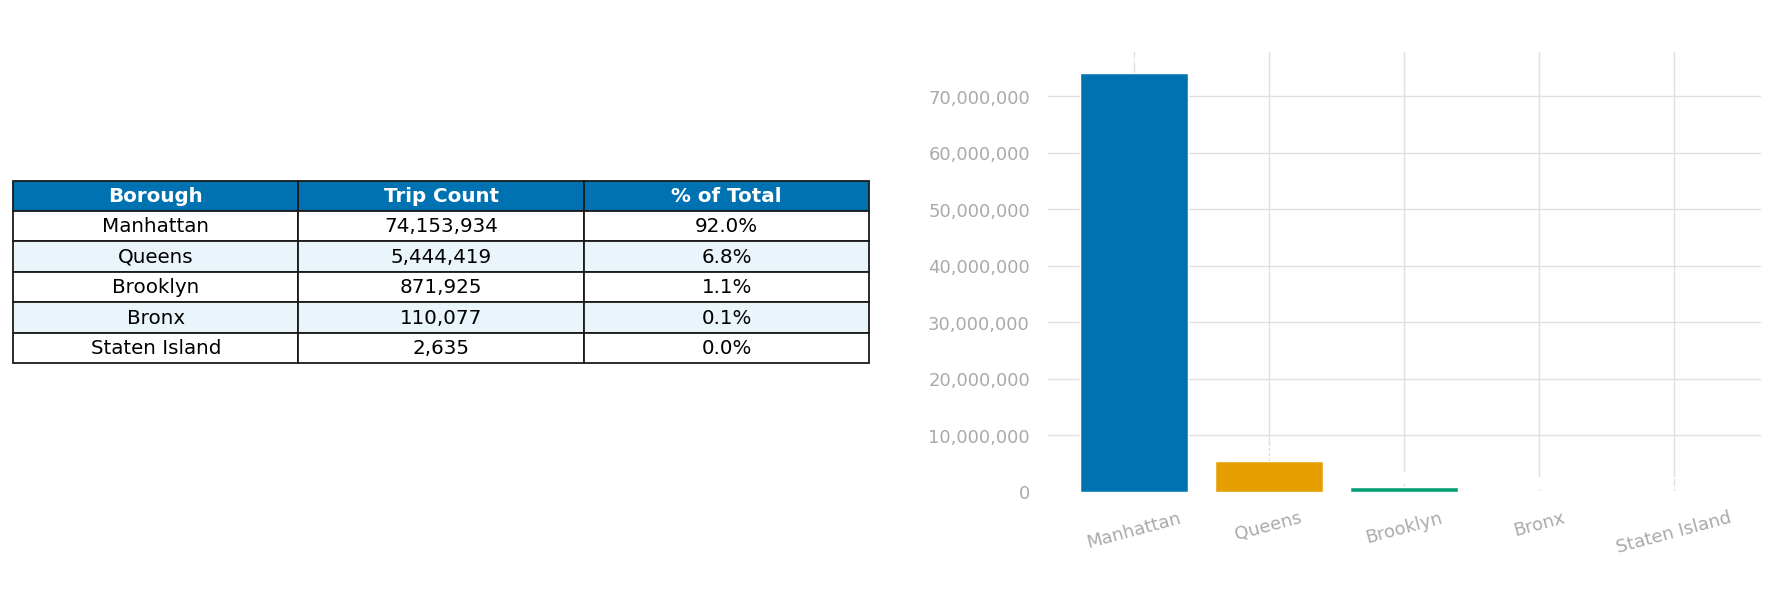

Saved: plot1_borough.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. BOROUGH SUMMARY TABLE + BAR CHART
# ─────────────────────────────────────────────────────────────────────────────
borough_summary = (
    df.groupby("borough")["trip_count"]
    .sum()
    .reset_index()
    .rename(columns={"trip_count": "total_trips"})
    .sort_values("total_trips", ascending=False)
)
borough_summary["pct"] = (
    borough_summary["total_trips"] / borough_summary["total_trips"].sum() * 100
)

print("\n── Borough Summary ──")
print(borough_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Table (left)
ax_tbl = axes[0]
ax_tbl.axis("off")
tbl_data = [
    [row["borough"], f"{row['total_trips']:,.0f}", f"{row['pct']:.1f}%"]
    for _, row in borough_summary.iterrows()
]
table = ax_tbl.table(
    cellText=tbl_data,
    colLabels=["Borough", "Trip Count", "% of Total"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.6)
# Header styling
for col in range(3):
    table[(0, col)].set_facecolor(CB["blue"])
    table[(0, col)].set_text_props(color="white", fontweight="bold")
# Alternating row shading + set text color to black
for row_i in range(1, len(tbl_data) + 1):
    fc = "#EAF4FB" if row_i % 2 == 0 else "white"
    for col in range(3):
        cell = table[(row_i, col)]
        cell.set_facecolor(fc)
        cell.set_text_props(color="black")  # ← this makes the text black
ax_tbl.set_title("Trip Counts by Borough", pad=12)

# Bar chart (right)
ax_bar = axes[1]
colors = [CB_LIST[i % len(CB_LIST)] for i in range(len(borough_summary))]
bars = ax_bar.bar(
    borough_summary["borough"],
    borough_summary["total_trips"],
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    zorder=3,
)
# Percentage labels on bars
for bar, pct in zip(bars, borough_summary["pct"]):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=9, fontweight="bold",
    )
ax_bar.set_title("Trip Count by Borough")
ax_bar.set_xlabel("Borough")
ax_bar.set_ylabel("Total Trip Count")
ax_bar.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax_bar.tick_params(axis="x", rotation=15)

plt.tight_layout(pad=2)
plt.savefig("plot1_borough.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot1_borough.png")


##### EDA Plot 2: Monthly demand by hour and season

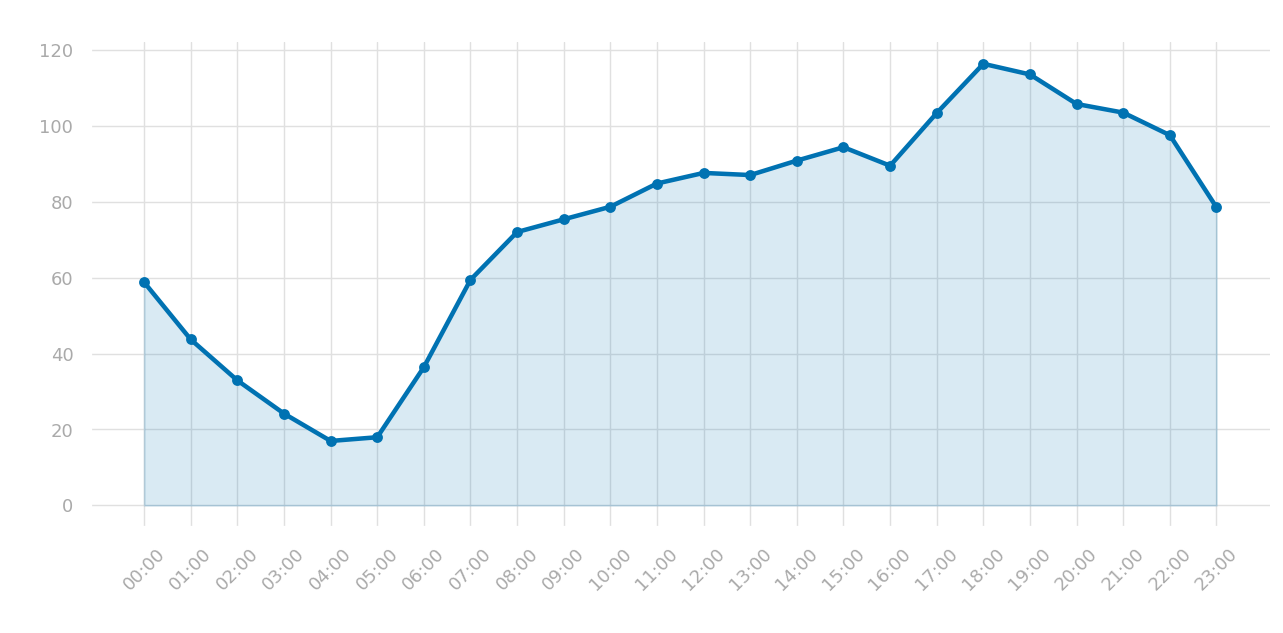

Saved: plot2_hourly_demand.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. AVERAGE HOURLY DEMAND (line chart)
# ─────────────────────────────────────────────────────────────────────────────
hourly = (
    df.groupby("hour_of_day")["trip_count"]
    .mean()
    .reset_index()
    .rename(columns={"trip_count": "avg_trips"})
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    hourly["hour_of_day"],
    hourly["avg_trips"],
    color=CB["blue"],
    linewidth=2.5,
    marker="o",
    markersize=5,
    zorder=3,
)
ax.fill_between(
    hourly["hour_of_day"],
    hourly["avg_trips"],
    alpha=0.15,
    color=CB["blue"],
)
ax.set_title("Average Hourly Demand")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Avg Trip Count per Hour-Zone")
ax.set_xticks(range(0, 24))
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):02d}:00")
)
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("plot2_hourly_demand.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot2_hourly_demand.png")

##### EDA Plot 3: Season and monthly trends

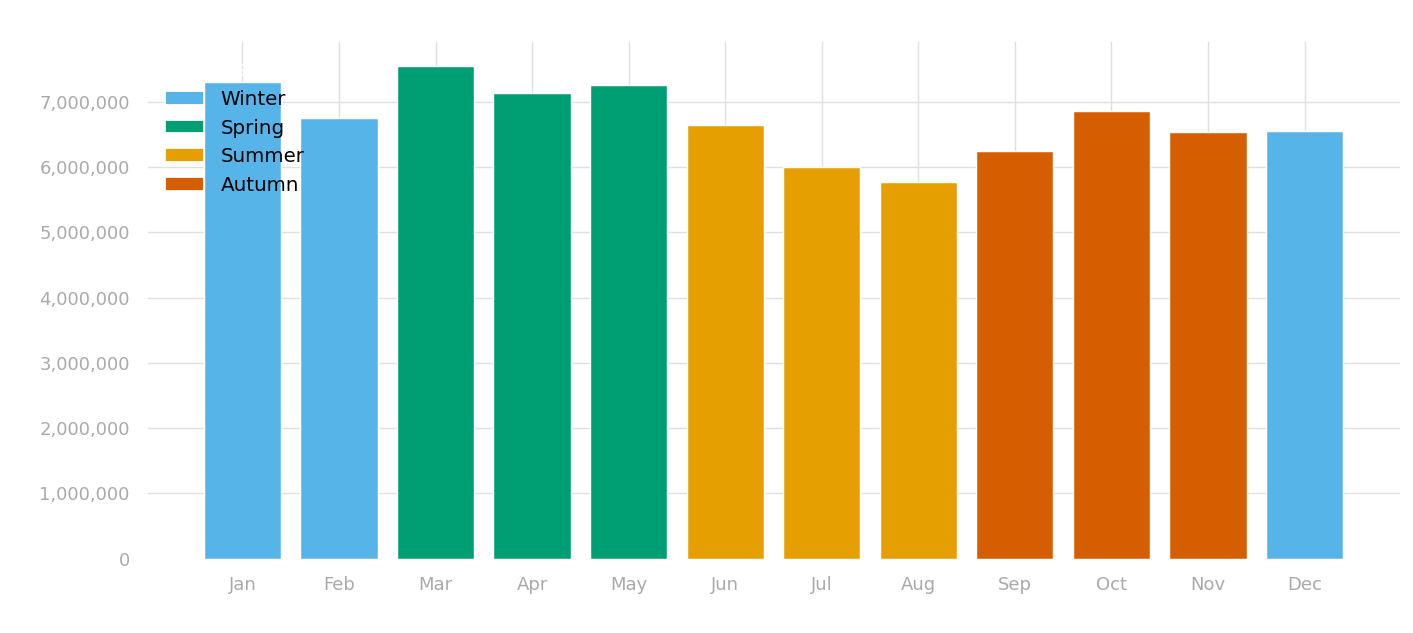

Saved: plot3_monthly_season.png


In [ ]:
season_map = {
    12: "Winter", 1: "Winter",  2: "Winter",
    3:  "Spring", 4: "Spring",  5: "Spring",
    6:  "Summer", 7: "Summer",  8: "Summer",
    9:  "Autumn", 10: "Autumn", 11: "Autumn",
}
season_colors = {
    "Winter": CB["sky"],
    "Spring": CB["green"],
    "Summer": CB["orange"],
    "Autumn": CB["red"],
}
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

# Ensure 'pickup_hour_ts' is datetime and create a numerical month column
df["numerical_month"] = df["pickup_hour_ts"].dt.month

monthly = (
    df.groupby("numerical_month")["trip_count"]
    .sum()
    .reset_index()
    .rename(columns={"trip_count": "total_trips", "numerical_month": "month_num"})
)
monthly["season"] = monthly["month_num"].map(season_map)
monthly["month_name"] = monthly["month_num"].apply(lambda m: month_names[m - 1])

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = [season_colors[s] for s in monthly["season"]]
bars = ax.bar(
    monthly["month_name"],
    monthly["total_trips"],
    color=bar_colors,
    edgecolor="white",
    linewidth=0.8,
    zorder=3,
)
# Legend
from matplotlib.patches import Patch
legend_patches = [
    Patch(facecolor=season_colors[s], label=s)
    for s in ["Winter", "Spring", "Summer", "Autumn"]
]
ax.legend(handles=legend_patches, title="Season", frameon=False, loc="upper left", labelcolor='black')
ax.set_title("Monthly Trip Demand by Season")
ax.set_xlabel("Month")
ax.set_ylabel("Total Trip Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.savefig("plot3_monthly_season.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot3_monthly_season.png")

##### EDA Plot 4: Spearman Correlation Heatmap

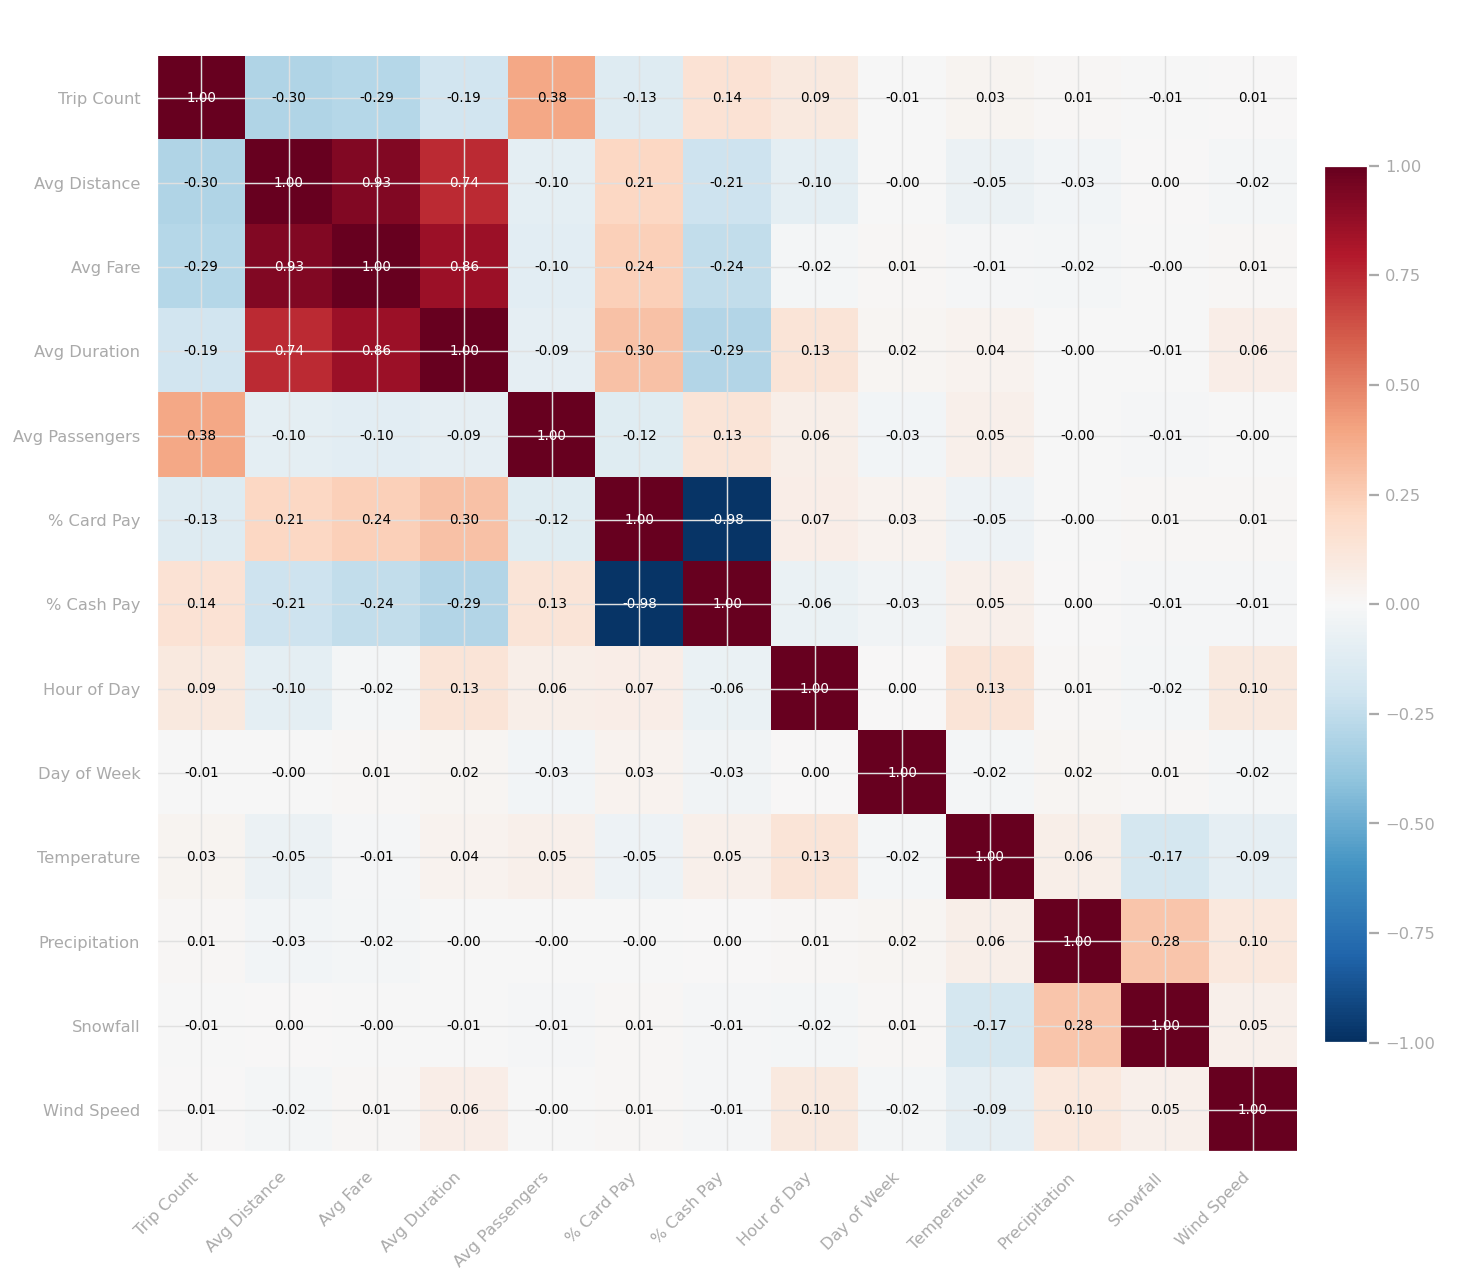

Saved: plot4_correlation_heatmap.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. SPEARMAN CORRELATION HEATMAP
# ─────────────────────────────────────────────────────────────────────────────
numeric_cols = [
    "trip_count", "avg_trip_distance", "avg_fare_amount",
    "avg_duration_mins", "avg_passenger_count",
    "pct_card_payment", "pct_cash_payment",
    "hour_of_day", "day_of_week",
    "temperature_2m", "precipitation", "snowfall", "windspeed_10m",
]
col_labels = [
    "Trip Count", "Avg Distance", "Avg Fare",
    "Avg Duration", "Avg Passengers",
    "% Card Pay", "% Cash Pay",
    "Hour of Day", "Day of Week",
    "Temperature", "Precipitation", "Snowfall", "Wind Speed",
]

subset = df[numeric_cols].dropna()
n = len(numeric_cols)
corr_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i == j:
            corr_matrix[i, j] = 1.0
        elif i < j:
            r, _ = stats.spearmanr(subset.iloc[:, i], subset.iloc[:, j])
            corr_matrix[i, j] = r
            corr_matrix[j, i] = r

# Diverging colorblind-safe colormap (RdBu_r works well)
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(col_labels, fontsize=9)

# Annotate cells
for i in range(n):
    for j in range(n):
        val = corr_matrix[i, j]
        text_color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7.5, color=text_color)

cbar = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Spearman r", fontsize=10)
cbar.ax.tick_params(labelsize=9)

ax.set_title("Spearman Correlation Heatmap", pad=14)
plt.tight_layout()
plt.savefig("plot4_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot4_correlation_heatmap.png")

Distribution plots for numerical features

In [ ]:
"""
Outlier Plots - Numerical Features
Each page: horizontal boxplot + KDE histogram + summary stats table
Output: outlier_plots.pdf
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
from scipy.stats import gaussian_kde

# ── Colorblind-friendly palette (Wong 2011) ───────────────────────────────────
BLUE   = "#0072B2"
ORANGE = "#E69F00"
RED    = "#D55E00"

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#E0E0E0",
    "grid.linewidth":    0.8,
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.labelsize":    11,
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
})

# ── Features to plot ──────────────────────────────────────────────────────────
FEATURES = {
    "trip_count":          "Trip Count",
    "avg_trip_distance":   "Avg Trip Distance (miles)",
    "avg_fare_amount":     "Avg Fare Amount ($)",
    "avg_duration_mins":   "Avg Duration (mins)",
    "avg_passenger_count": "Avg Passenger Count",
    "pct_card_payment":    "% Card Payment",
    "pct_cash_payment":    "% Cash Payment",
    "temperature_2m":      "Temperature (°C)",
    "precipitation":       "Precipitation (mm)",
    "snowfall":            "Snowfall (cm)",
    "windspeed_10m":       "Wind Speed (km/h)",
}


def compute_stats(series):
    """Return a dict of summary statistics."""
    q1  = series.quantile(0.25)
    med = series.quantile(0.50)
    q3  = series.quantile(0.75)
    iqr = q3 - q1
    return {
        "Count":    f"{len(series):,}",
        "Mean":     f"{series.mean():.2f}",
        "Std Dev":  f"{series.std():.2f}",
        "Min":      f"{series.min():.2f}",
        "Q1 (25%)": f"{q1:.2f}",
        "Median":   f"{med:.2f}",
        "Q3 (75%)": f"{q3:.2f}",
        "IQR":      f"{iqr:.2f}",
        "Max":      f"{series.max():.2f}",
        "Outliers (IQR)": f"{((series < q1 - 1.5*iqr) | (series > q3 + 1.5*iqr)).sum():,}",
    }


def plot_feature(col, label, ax_box, ax_hist, ax_stats):
    """Draw boxplot, KDE histogram, and stats table for one feature."""
    series = df[col].dropna()
    stats  = compute_stats(series)
    q1, med, q3 = series.quantile([0.25, 0.50, 0.75])
    iqr          = q3 - q1
    lo_fence     = q1 - 1.5 * iqr
    hi_fence     = q3 + 1.5 * iqr

    # ── Boxplot ───────────────────────────────────────────────────────────────
    bp = ax_box.boxplot(
        series,
        vert=False,
        patch_artist=True,
        widths=0.5,
        flierprops=dict(marker="o", color=RED, alpha=0.3, markersize=3,
                        markeredgewidth=0),
        medianprops=dict(color=ORANGE, linewidth=2.5),
        boxprops=dict(facecolor=BLUE, alpha=0.4, linewidth=1.2),
        whiskerprops=dict(linewidth=1.2, color="#333333"),
        capprops=dict(linewidth=1.5, color="#333333"),
    )
    ax_box.set_yticks([])
    ax_box.set_xlabel("")
    ax_box.set_title(label)
    ax_box.axvline(lo_fence, color=RED, linestyle="--", linewidth=1,
                   alpha=0.6, label="IQR fences")
    ax_box.axvline(hi_fence, color=RED, linestyle="--", linewidth=1, alpha=0.6)
    ax_box.legend(fontsize=8, frameon=False, loc="upper right")

    # ── KDE + histogram ───────────────────────────────────────────────────────
    # Clip extreme outliers for readability (plot to 1st/99th pct)
    p01, p99 = series.quantile(0.01), series.quantile(0.99)
    plot_range = np.linspace(p01, p99, 300)

    ax_hist.hist(
        series.clip(p01, p99),
        bins=60,
        color=BLUE,
        alpha=0.35,
        density=True,
        zorder=2,
    )
    try:
        kde = gaussian_kde(series.sample(min(50_000, len(series)), random_state=42))
        ax_hist.plot(plot_range, kde(plot_range), color=BLUE,
                     linewidth=2.2, zorder=3)
    except Exception:
        pass  # skip KDE if it fails (e.g. zero variance)

    ax_hist.axvline(med, color=ORANGE, linewidth=2, linestyle="-",
                    label=f"Median: {med:.2f}", zorder=4)
    ax_hist.axvline(q1,  color=BLUE,   linewidth=1.5, linestyle=":",
                    label=f"Q1: {q1:.2f}", zorder=4)
    ax_hist.axvline(q3,  color=BLUE,   linewidth=1.5, linestyle=":",
                    label=f"Q3: {q3:.2f}", zorder=4)
    ax_hist.set_xlabel(label)
    ax_hist.set_ylabel("Density")
    ax_hist.legend(fontsize=8, frameon=False)
    note = f"Note: x-axis clipped to 1st–99th percentile for readability"
    ax_hist.text(0.99, 0.97, note, transform=ax_hist.transAxes,
                 ha="right", va="top", fontsize=7.5, color="grey",
                 style="italic")

    # ── Summary stats table ───────────────────────────────────────────────────
    ax_stats.axis("off")
    col_labels  = list(stats.keys())
    cell_values = [list(stats.values())]
    tbl = ax_stats.table(
        cellText=cell_values,
        colLabels=col_labels,
        loc="center",
        cellLoc="center",
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.8)
    # Header style
    for j in range(len(col_labels)):
        tbl[(0, j)].set_facecolor(BLUE)
        tbl[(0, j)].set_text_props(color="white", fontweight="bold")
        tbl[(1, j)].set_facecolor("#EAF4FB")


# ── Produce PDF ───────────────────────────────────────────────────────────────
output_path = "outlier_plots.pdf"

with PdfPages(output_path) as pdf:
    for col, label in FEATURES.items():
        if col not in df.columns:
            print(f"Skipping {col} — not found in dataframe")
            continue

        fig = plt.figure(figsize=(13, 9))
        gs  = gridspec.GridSpec(
            3, 1,
            height_ratios=[1, 2.5, 0.8],
            hspace=0.45,
        )
        ax_box   = fig.add_subplot(gs[0])
        ax_hist  = fig.add_subplot(gs[1], sharex=ax_box)
        ax_stats = fig.add_subplot(gs[2])

        plt.setp(ax_box.get_xticklabels(), visible=False)

        plot_feature(col, label, ax_box, ax_hist, ax_stats)

        fig.suptitle(f"Outlier Analysis — {label}",
                     fontsize=15, fontweight="bold", y=1.01)

        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)
        print(f"✓  {label}")

print(f"\nSaved: {output_path}  ({len(FEATURES)} pages)")


✓  Trip Count
✓  Avg Trip Distance (miles)
✓  Avg Fare Amount ($)
✓  Avg Duration (mins)
✓  Avg Passenger Count
✓  % Card Payment
✓  % Cash Payment
✓  Temperature (°C)
✓  Precipitation (mm)
✓  Snowfall (cm)
✓  Wind Speed (km/h)

Saved: outlier_plots.pdf  (11 pages)


#### Section 6.1 Location data

In [ ]:
# ── Install if needed (run once in Colab) ────────────────────────────────────
# !pip install geopandas mapclassify --break-system-packages -q

In [ ]:
# Load shp file
gdf = gpd.read_file(ZONE_LOOKUP_SHP_PATH)

In [ ]:
gdf

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."
...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ..."
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ..."
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19..."
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824...."


Current CRS: EPSG:2263
Reprojected to: EPSG:4326
        minx       miny       maxx       maxy
0 -74.189997  40.670993 -74.153070  40.707974
1 -73.878248  40.581694 -73.766708  40.639953
['objectid', 'shape_leng', 'shape_area', 'zone', 'locationid', 'borough', 'geometry']


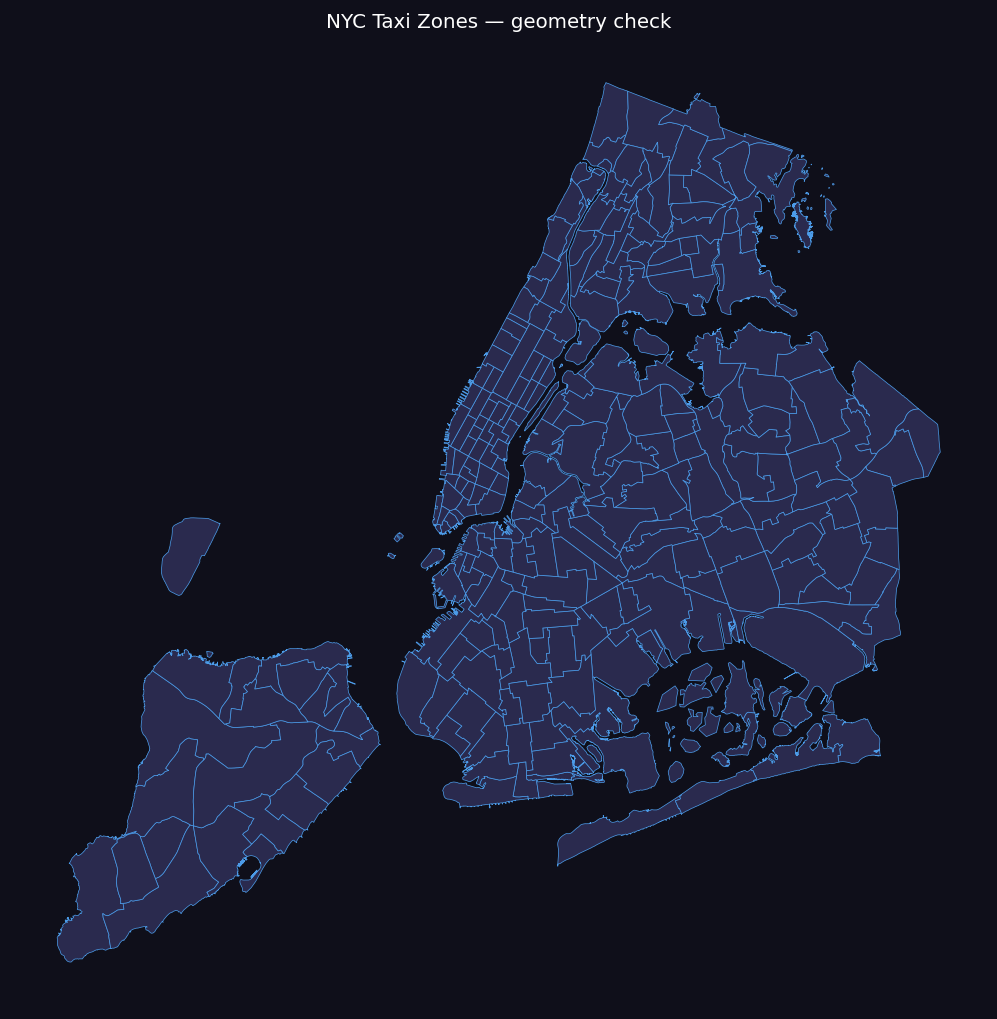

In [ ]:
# ── Fix CRS ───────────────────────────────────────────────────────────────────
print(f"Current CRS: {gdf.crs}")   # confirm it's EPSG:2263

gdf = gdf.to_crs(epsg=4326)        # reproject to WGS84 (degrees)
print(f"Reprojected to: {gdf.crs}")

# Confirm coordinates now look like lat/lon (small numbers)
print(gdf.geometry.bounds.head(2)) # minx should be around -74, miny around 40

# ── Standardise column names ──────────────────────────────────────────────────
gdf.columns = gdf.columns.str.lower().str.strip()
print(gdf.columns.tolist())
# should now be: objectid, shape_leng, shape_area, zone, locationid, borough, geometry

# ── Quick sanity plot — just the outlines before adding data ─────────────────
fig, ax = plt.subplots(figsize=(8, 8), facecolor='#0f0f1a')
ax.set_facecolor('#1a1a2e')
gdf.plot(ax=ax, color='#2a2a4e', edgecolor='#4C9BE8', linewidth=0.4)
ax.set_axis_off()
ax.set_title('NYC Taxi Zones — geometry check', color='white', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# ── Aggregate to one row per PULocationID before merging ─────────────────────
demand_by_location = (
    df_gold_2019
    .groupby('PULocationID', as_index=False)
    .agg(
        total_trips  = ('trip_count', 'sum'),
        avg_hourly   = ('trip_count', 'mean'),
        zone         = ('zone',         'first'),
        borough      = ('borough',       'first'),
        service_zone = ('service_zone',  'first')
    )
)

print(f"Unique PULocationIDs in demand data : {len(demand_by_location)}")
# Should be ~200–230, not millions

# ── Now merge cleanly — shapefile (263 rows) × demand (one row per location) ─
gdf_renamed = gdf.rename(columns={'locationid': 'PULocationID'})

gdf_merged = gdf_renamed.merge(demand_by_location, on='PULocationID', how='left')
gdf_merged['total_trips'] = gdf_merged['total_trips'].fillna(0)
gdf_merged['avg_hourly']  = gdf_merged['avg_hourly'].fillna(0)

print(f"gdf_merged rows : {len(gdf_merged)}")   # should be 263
matched   = gdf_merged['total_trips'].gt(0).sum()
unmatched = gdf_merged['total_trips'].eq(0).sum()
print(f"Matched         : {matched}")
print(f"Unmatched       : {unmatched}")

if unmatched > 0:
    print(gdf_merged[gdf_merged['total_trips'].eq(0)][['PULocationID','zone_x','borough_x']].to_string())

Unique PULocationIDs in demand data : 260
gdf_merged rows : 263
Matched         : 260
Unmatched       : 3
     PULocationID                                         zone_x      borough_x
0               1                                 Newark Airport            EWR
102           103  Governor's Island/Ellis Island/Liberty Island      Manhattan
109           110                               Great Kills Park  Staten Island


In [ ]:
# ── Borough-level demand summary for labels ───────────────────────────────────
borough_demand = (
    demand_by_location
    .groupby('borough', as_index=False)['total_trips']
    .sum()
)
total_all = borough_demand['total_trips'].sum()
borough_demand['pct'] = (borough_demand['total_trips'] / total_all * 100).round(1)

print(borough_demand.sort_values('total_trips', ascending=False))


         borough  total_trips   pct
2      Manhattan     74153934  92.0
3         Queens      5444419   6.8
1       Brooklyn       871925   1.1
0          Bronx       110077   0.1
4  Staten Island         2635   0.0


##### EDA Plot 5: Demand choropleth and service zone coverage with borough labels

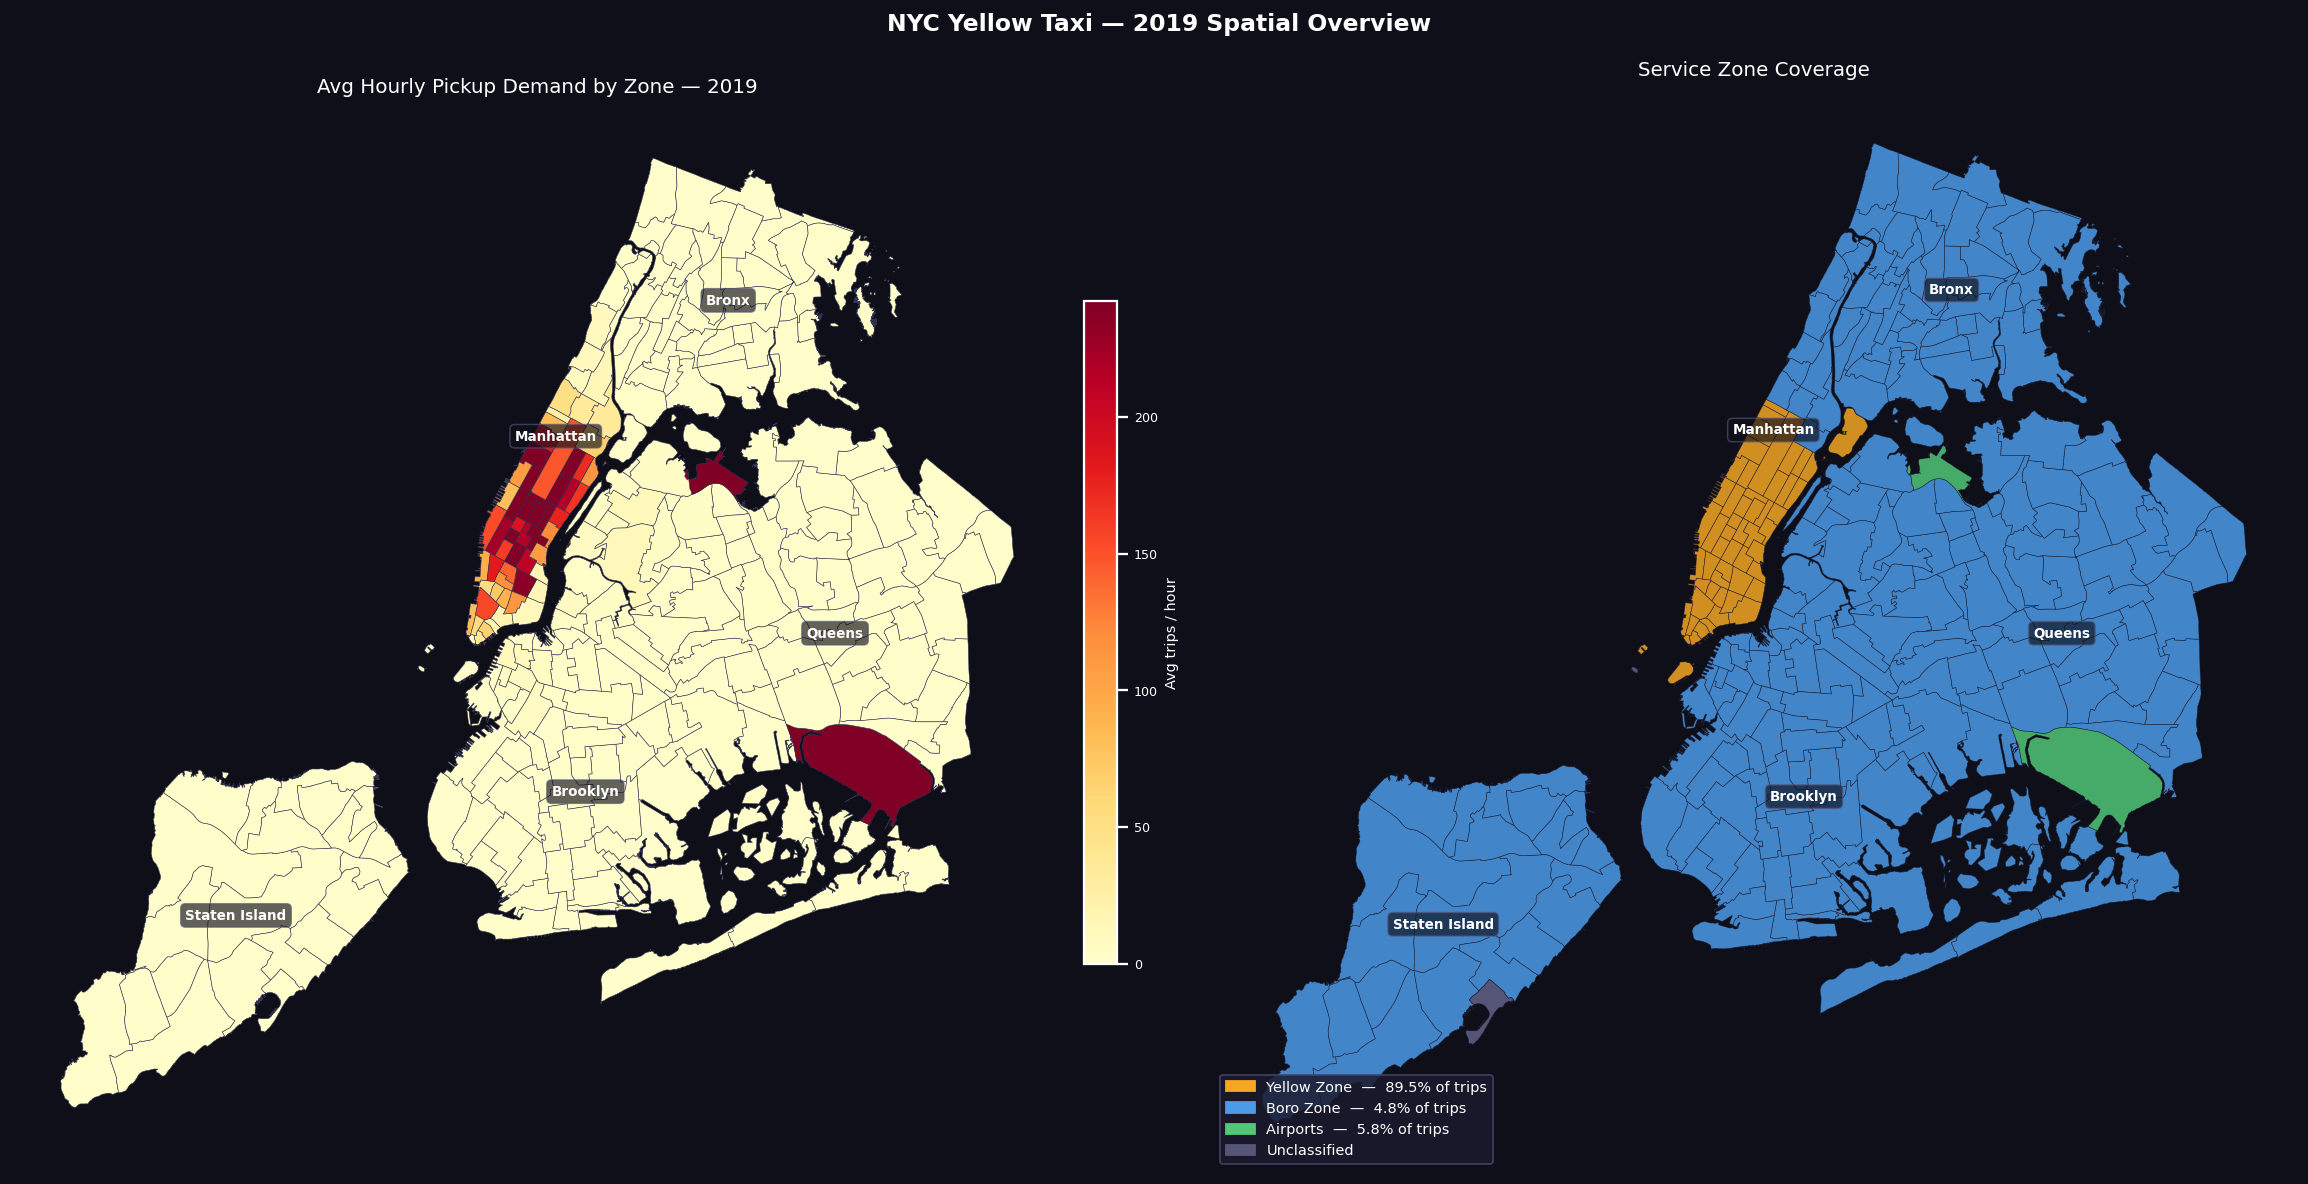

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Demand choropleth  +  Service zone coverage (with borough labels)
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.patch.set_facecolor('#0f0f1a')

for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.set_axis_off()

# ── Shared: borough centroids + demand labels ─────────────────────────────────
gdf_plot = gdf_merged[~gdf_merged['borough_x'].isin(['EWR', 'Unknown'])].copy()

borough_geom = (
    gdf_plot[gdf_plot['borough_x'].notna()]
    .dissolve(by='borough_x')
    .reset_index()
    .merge(borough_demand, left_on='borough_x', right_on='borough', how='left')
)
borough_geom['centroid'] = borough_geom.geometry.centroid

# Manual label nudges so text doesn't overlap zone boundaries
nudge = {
    'Manhattan':     (0.00,   0.015),
    'Brooklyn':      (0.00,  -0.01),
    'Queens':        (0.015,  0.00),
    'Bronx':         (0.00,   0.00),
    'Staten Island': (0.00,   0.00),
}

def add_borough_labels(ax, show_demand=True):
    for _, row in borough_geom.iterrows():
        if row['borough_x'] in ['EWR', 'Unknown']:
            continue
        cx = row['centroid'].x + nudge.get(row['borough_x'], (0, 0))[0]
        cy = row['centroid'].y + nudge.get(row['borough_x'], (0, 0))[1]

        if show_demand and pd.notna(row.get('total_trips')):
            trips_fmt = f"{int(row['total_trips']):,}"
            pct_fmt   = f"{row['pct']:.1f}%"
            label     = f"{row['borough_x']}\n{trips_fmt} trips\n{pct_fmt}"
        else:
            label = row['borough_x']

        ax.text(
            cx, cy, label,
            fontsize    = 7.5,
            fontweight  = 'bold',
            color       = 'white',
            ha          = 'center',
            va          = 'center',
            linespacing = 1.5,
            bbox        = dict(
                boxstyle    = 'round,pad=0.35',
                facecolor   = '#0f0f1a',
                alpha       = 0.65,
                edgecolor   = '#555577',
                linewidth   = 0.8
            )
        )

# ── Panel A: demand choropleth ────────────────────────────────────────────────
ax = axes[0]

vmax = gdf_plot['avg_hourly'].quantile(0.95)

gdf_plot.plot(
    column      = 'avg_hourly',
    ax          = ax,
    cmap        = 'YlOrRd',
    vmin        = 0,
    vmax        = vmax,
    linewidth   = 0.3,
    edgecolor   = '#333355',
    legend      = False,
    missing_kwds= {'color': '#2a2a3e'}
)

# Colourbar
sm = plt.cm.ScalarMappable(cmap='YlOrRd',
                            norm=plt.Normalize(vmin=0, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, shrink=0.65)
cbar.set_label('Avg trips / hour', color='white', fontsize=8)
cbar.ax.yaxis.set_tick_params(color='white', labelsize=7)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

add_borough_labels(ax, show_demand=True)

ax.set_title('Avg Hourly Pickup Demand by Zone — 2019',
             color='white', fontsize=11, pad=10)

# ── Panel B: service zone coverage ───────────────────────────────────────────
ax = axes[1]

service_colours = {
    'Yellow Zone' : '#F5A623',
    'Boro Zone'   : '#4C9BE8',
    'Airports'    : '#50C878',
}

for sz, colour in service_colours.items():
    subset = gdf_plot[gdf_plot['service_zone'] == sz]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, linewidth=0.3,
                    edgecolor='#1a1a2e', alpha=0.85)

# Zones with no service_zone mapping
gdf_plot[gdf_plot['service_zone'].isna()].plot(
    ax=ax, color='#555577', linewidth=0.3, edgecolor='#1a1a2e'
)

# Service zone trip share in legend
service_share = (
    demand_by_location
    .groupby('service_zone')['total_trips']
    .sum()
    .reset_index()
)
service_share['pct'] = (service_share['total_trips'] / total_all * 100).round(1)
sz_pct = dict(zip(service_share['service_zone'], service_share['pct']))

legend_patches = [
    mpatches.Patch(
        color   = c,
        label   = f"{sz}  —  {sz_pct.get(sz, 0):.1f}% of trips"
    )
    for sz, c in service_colours.items()
]
legend_patches.append(
    mpatches.Patch(color='#555577', label='Unclassified')
)
ax.legend(
    handles     = legend_patches,
    loc         = 'lower left',
    facecolor   = '#1a1a2e',
    edgecolor   = '#444466',
    labelcolor  = 'white',
    fontsize     = 8,
    framealpha  = 0.85
)

# Borough labels — name only on service zone map (no trip counts, avoids clutter)
add_borough_labels(ax, show_demand=False)

ax.set_title('Service Zone Coverage', color='white', fontsize=11, pad=10)

plt.suptitle(
    'NYC Yellow Taxi — 2019 Spatial Overview',
    color='white', fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(OUT_DIR / 'spatial_overview.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [ ]:
# ── Top / bottom zones ────────────────────────────────────────────────────────
ranked  = demand_by_location[demand_by_location['avg_hourly'] >= 5].sort_values(
    'avg_hourly', ascending=False
)
top3    = ranked.head(3)['zone'].tolist()
bottom3 = ranked.tail(3)['zone'].tolist()
print("Top 3   :", top3)
print("Bottom 3:", bottom3)

Top 3   : ['Upper East Side South', 'Midtown Center', 'Upper East Side North']
Bottom 3: ['Battery Park', 'Cobble Hill', 'DUMBO/Vinegar Hill']


##### EDA Plot 6: Top 3 / Bottom 3 Zones + hourly demand line chart

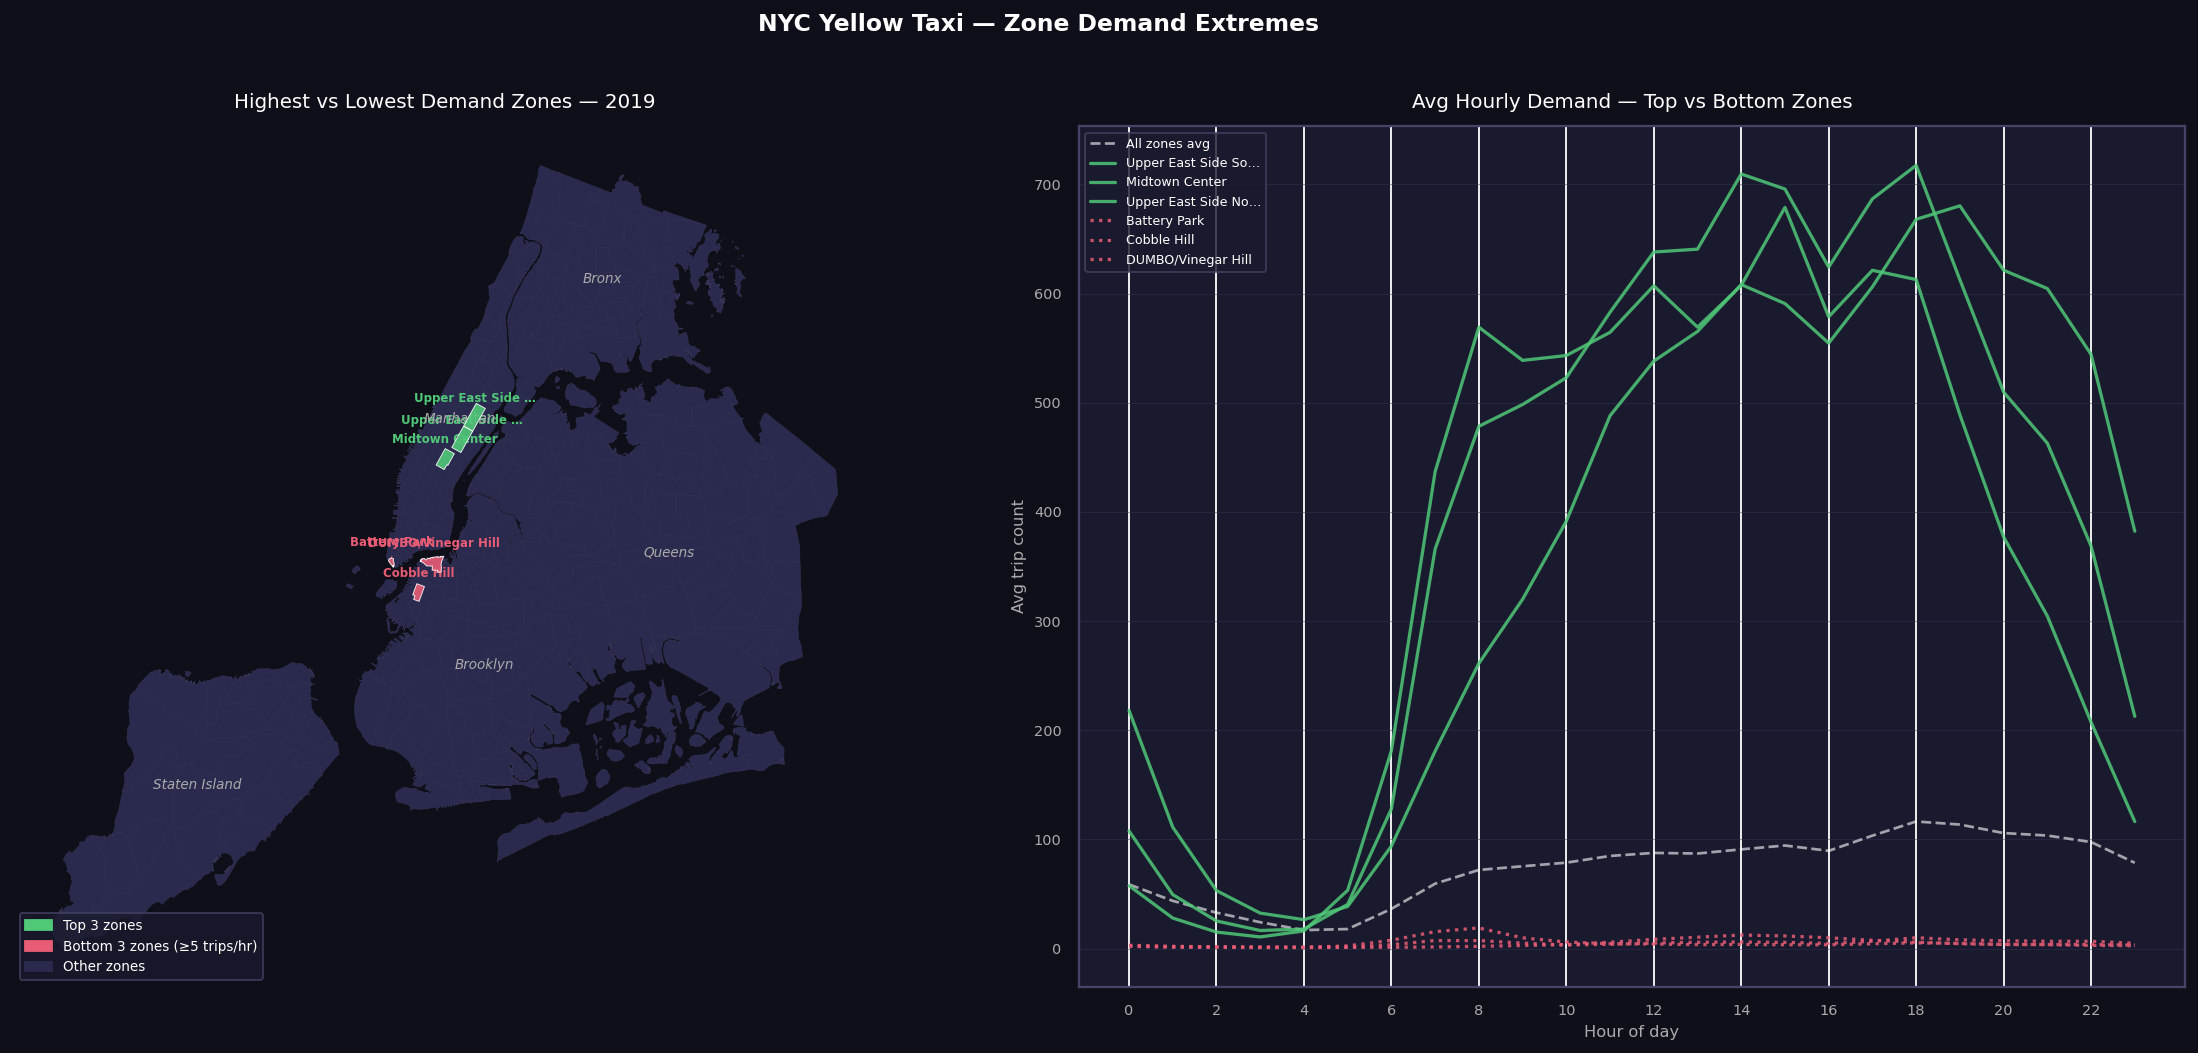

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Top 3 / Bottom 3 zones  +  hourly demand line chart
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#0f0f1a')

for ax in axes:
    ax.set_facecolor('#1a1a2e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444466')

# ── Panel A: map highlighting top / bottom zones ─────────────────────────────
ax = axes[0]
ax.set_axis_off()

# Base layer — all zones in muted grey
gdf_plot.plot(ax=ax, color='#2a2a4e', linewidth=0.3, edgecolor='#333355')

# Top 3 — filled green
gdf_plot[gdf_plot['zone_y'].isin(top3)].plot(
    ax=ax, color='#50C878', linewidth=0.5,
    edgecolor='white', alpha=0.9, zorder=4
)

# Bottom 3 — filled red
gdf_plot[gdf_plot['zone_y'].isin(bottom3)].plot(
    ax=ax, color='#E85D75', linewidth=0.5,
    edgecolor='white', alpha=0.9, zorder=4
)

# Zone name annotations
for zone in top3 + bottom3:
    row = gdf_plot[gdf_plot['zone_y'] == zone]
    if row.empty:
        continue
    cx = row.geometry.centroid.x.values[0]
    cy = row.geometry.centroid.y.values[0]
    colour = '#50C878' if zone in top3 else '#E85D75'
    # Shorten long zone names for readability
    label = zone if len(zone) <= 18 else zone[:16] + '…'
    ax.annotate(
        label, xy=(cx, cy),
        fontsize=6.5, color=colour, fontweight='bold',
        ha='center', va='bottom',
        xytext=(0, 7), textcoords='offset points',
        arrowprops=dict(arrowstyle='-', color=colour, lw=0.8)
    )

# Borough labels
for _, row in borough_geom.iterrows():
    ax.text(row.geometry.centroid.x, row.geometry.centroid.y,
            row['borough_x'], fontsize=7.5, color='#aaaaaa',
            ha='center', style='italic')

# Legend
legend_elements = [
    mpatches.Patch(color='#50C878', label=f'Top 3 zones'),
    mpatches.Patch(color='#E85D75', label=f'Bottom 3 zones (≥5 trips/hr)'),
    mpatches.Patch(color='#2a2a4e', label='Other zones'),
]
ax.legend(handles=legend_elements, loc='lower left',
          facecolor='#1a1a2e', edgecolor='#444466',
          labelcolor='white', fontsize=7.5)

ax.set_title('Highest vs Lowest Demand Zones — 2019',
             color='white', fontsize=11, pad=10)

# ── Panel B: hourly demand line — top 3 vs bottom 3 vs overall ───────────────
ax = axes[1]

hourly_overall = (
    df_zone_2019.groupby('hour_of_day')['trip_count']
    .mean().reset_index(name='avg_trips')
)

ax.plot(hourly_overall['hour_of_day'], hourly_overall['avg_trips'],
        color='white', linewidth=1.5, linestyle='--',
        label='All zones avg', alpha=0.6)

# One line per top zone
for zone in top3:
    h = (df_zone_2019[df_zone_2019['zone'] == zone]
         .groupby('hour_of_day')['trip_count'].mean().reset_index())
    ax.plot(h['hour_of_day'], h['trip_count'],
            color='#50C878', linewidth=1.8,
            label=zone if len(zone) <= 20 else zone[:18] + '…',
            alpha=0.85)

# One line per bottom zone
for zone in bottom3:
    h = (df_zone_2019[df_zone_2019['zone'] == zone]
         .groupby('hour_of_day')['trip_count'].mean().reset_index())
    ax.plot(h['hour_of_day'], h['trip_count'],
            color='#E85D75', linewidth=1.8, linestyle=':',
            label=zone if len(zone) <= 20 else zone[:18] + '…',
            alpha=0.85)

ax.set_title('Avg Hourly Demand — Top vs Bottom Zones',
             color='white', fontsize=11, pad=10)
ax.set_xlabel('Hour of day', color='#aaaaaa', fontsize=9)
ax.set_ylabel('Avg trip count', color='#aaaaaa', fontsize=9)
ax.tick_params(colors='#aaaaaa', labelsize=8)
ax.set_xticks(range(0, 24, 2))
ax.legend(facecolor='#1a1a2e', edgecolor='#444466',
          labelcolor='white', fontsize=7, loc='upper left')
ax.grid(axis='y', color='#333355', linewidth=0.5, alpha=0.5)

plt.suptitle('NYC Yellow Taxi — Zone Demand Extremes',
             color='white', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'zone_extremes.png', dpi=150,
            bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SETUP — derived columns needed across all four charts
# ══════════════════════════════════════════════════════════════════════════════
df = df_zone_2019.copy()
df['pickup_hour_ts'] = pd.to_datetime(df['pickup_hour_ts'])
df['hour_of_day']    = df['pickup_hour_ts'].dt.hour
df['month_of_year']  = df['pickup_hour_ts'].dt.month
df['season']         = df['month_of_year'].map(season_map)

# Log1p applied before correlation — handles zero-inflation in both columns
df['log1p_snowfall']      = np.log1p(df['snowfall'])
df['log1p_precipitation'] = np.log1p(df['precipitation'])

# Season mapping
season_map = {
    12: 'Winter', 1: 'Winter',  2: 'Winter',
     3: 'Spring', 4: 'Spring',  5: 'Spring',
     6: 'Summer', 7: 'Summer',  8: 'Summer',
     9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
}
season_colours = {
    'Winter': '#4C9BE8',
    'Spring': '#50C878',
    'Summer': '#F5A623',
    'Autumn': '#E85D75',
}
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

df['season'] = df['month_of_year'].map(season_map)

### Section 6.3: Choice of filtering for baseline modelling

In [ ]:
# Overall model

# Filter for only boroughs Manhattan, Queens and Brooklyn
df_2019_top3_boroughs = df_zone_2019[df_zone_2019['borough'].isin(['Manhattan', 'Queens', 'Brooklyn'])]

#### Top 3 Borough Analysis

In [ ]:
zone_totals = df_2019_top3_boroughs.groupby("zone")["trip_count"].sum().sort_values().copy()

# ── Summary stats ─────────────────────────────────────────────────────────────
stats = zone_totals.describe(percentiles=[0.25, 0.5, 0.75])
print("=== Summary Stats ===")
print(stats.round(1))

# ── Top 5 / Bottom 5 ─────────────────────────────────────────────────────────
print("\n=== Top 5 Zones ===")
print(zone_totals.tail(5).to_frame("total_trips"))

print("\n=== Bottom 5 Zones ===")
print(zone_totals.head(5).to_frame("total_trips"))

=== Summary Stats ===
count        196.0
mean      410562.6
std       801184.4
min           29.0
25%         1975.0
50%        10061.5
75%       306803.0
max      3545217.0
Name: trip_count, dtype: float64

=== Top 5 Zones ===
                              total_trips
zone                                     
Penn Station/Madison Sq West      2928411
Midtown East                      2960774
Upper East Side North             3206436
Midtown Center                    3350454
Upper East Side South             3545217

=== Bottom 5 Zones ===
                                               total_trips
zone                                                      
Broad Channel                                           29
Breezy Point/Fort Tilden/Riis Beach                     63
Jamaica Bay                                             84
Governor's Island/Ellis Island/Liberty Island          112
Green-Wood Cemetery                                    140


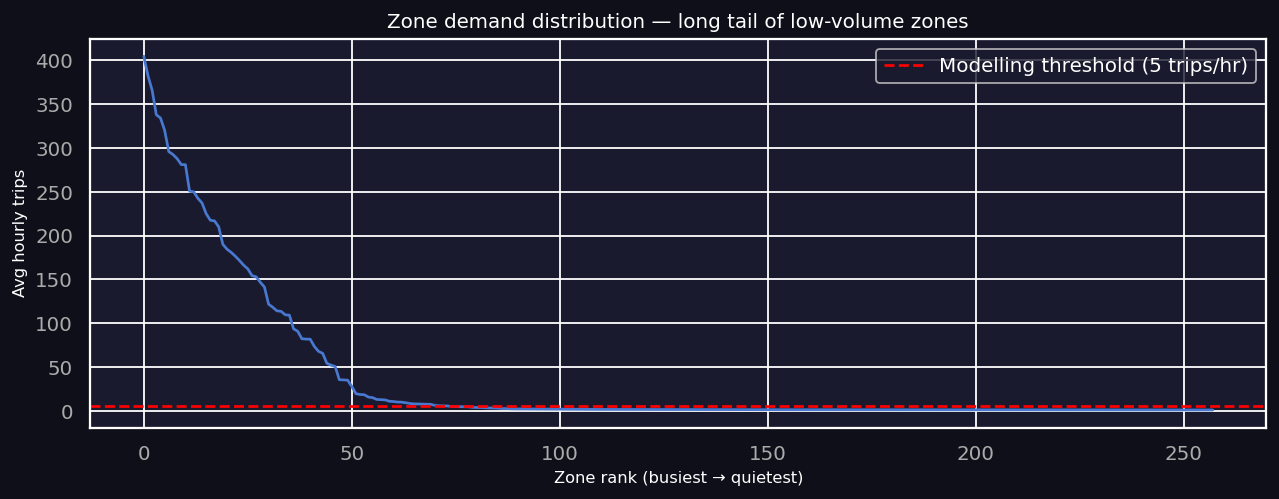

Zones above threshold : 74 / 258
These zones account for: 98.9% of all trips


In [ ]:
# Identify which zones are worth modelling
zone_avg = (
    df_zone_2019.groupby('zone')['trip_count']
    .mean()
    .reset_index()
    .rename(columns={'trip_count': 'avg_hourly_trips'})
    .sort_values('avg_hourly_trips', ascending=False)
)

# # This plot justifies zone filtering decision i
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(zone_avg)), zone_avg['avg_hourly_trips'].values)
ax.axhline(y=5, color='red', linestyle='--', label='Modelling threshold (5 trips/hr)')
ax.set_xlabel('Zone rank (busiest → quietest)')
ax.set_ylabel('Avg hourly trips')
ax.set_title('Zone demand distribution — long tail of low-volume zones')
ax.legend()
plt.tight_layout()
plt.show()

high_volume_zones = zone_avg[zone_avg['avg_hourly_trips'] >= 5]['zone'].tolist()
print(f"Zones above threshold : {len(high_volume_zones)} / {len(zone_avg)}")
print(f"These zones account for: "
      f"{df_zone[df_zone['zone'].isin(high_volume_zones)]['trip_count'].sum() / df_zone['trip_count'].sum() * 100:.1f}% of all trips")

In [ ]:
high_volume_zones = zone_avg[zone_avg['avg_hourly_trips'] >= 5]['zone'].tolist()
print(f"Zones above threshold : {len(high_volume_zones)} / {len(zone_avg)}")
print(f"These zones account for: "
      f"{df_zone_2019[df_zone_2019['zone'].isin(high_volume_zones)]['trip_count'].sum() / df_zone_2019['trip_count'].sum() * 100:.1f}% of all trips")

Zones above threshold : 74 / 258
These zones account for: 98.9% of all trips


In [ ]:
# Show service zone breakdown — one bar chart for the presentation
service_zone_summary = (
    df_zone_2019.groupby('service_zone')['trip_count']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={'sum': 'total_trips', 'mean': 'avg_hourly', 'count': 'zone_hours'})
    .sort_values('total_trips', ascending=False)
)
display(service_zone_summary)

,total_trips,avg_hourly,zone_hours
service_zone,,,
Yellow Zone,72083877,161.451094,446475
Airports,4651087,272.232192,17085
Boro Zone,3848026,6.422186,599177


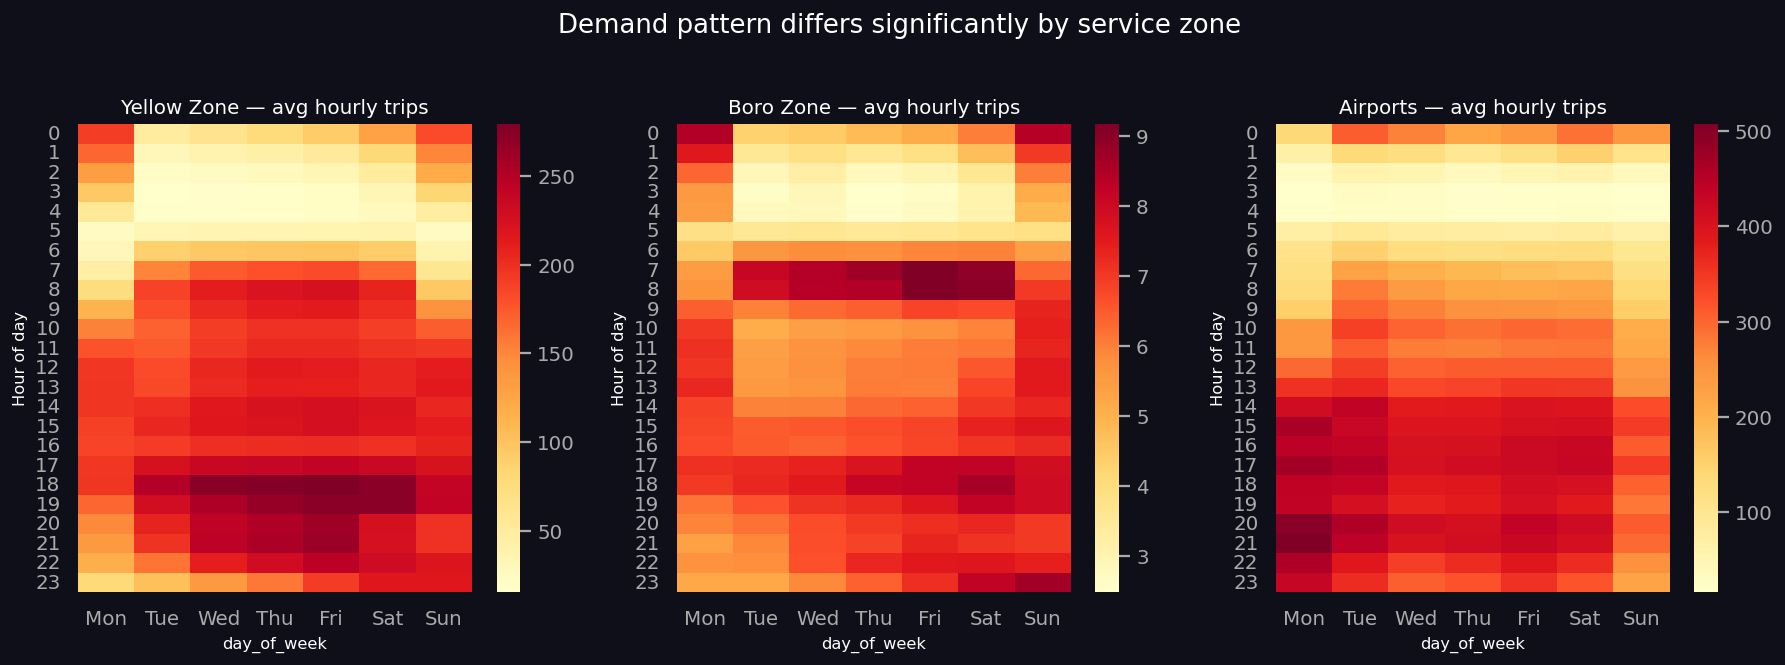

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, sz in zip(axes, ['Yellow Zone', 'Boro Zone','Airports']):
    pivot = (
        df_zone_2019[df_zone_2019['service_zone'] == sz]
        .groupby(['hour_of_day', 'day_of_week'])['trip_count']
        .mean()
        .unstack()
    )
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', fmt='.0f',
                xticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
    ax.set_title(f'{sz} — avg hourly trips')
    ax.set_ylabel('Hour of day')

plt.suptitle('Demand pattern differs significantly by service zone', y=1.02)
plt.tight_layout()
plt.show()


## Section 7: Inspect and Prepare Data for Baseline Modelling

### Build features for modelling

In [ ]:
# TO REVISE
def fill_weather_and_holiday_gaps(df, location_col, datetime_col):
    """
    Fills gaps introduced by the spine reindexing for weather, borough, and holidays.
    Only fills missing values to preserve original ingestion data.
    """

    # 1) Holidays: Recompute from timestamp for 100% coverage
    # This is safer and faster than ffilling booleans
    nyc_holidays = holidays.US(state='NY', years=[2019, 2020, 2021, 2022])
    df['is_holiday'] = df[datetime_col].dt.date.isin(nyc_holidays).astype(bool)

    # 2) Borough: Static mapping (Zone never changes Borough)
    # We find the mapping from non-NaN rows and apply it to the whole column
    if 'borough' in df.columns:
        zone_map = df.dropna(subset=['borough']).drop_duplicates(location_col)
        mapping = dict(zip(zone_map[location_col], zone_map['borough']))
        df['borough'] = df['borough'].fillna(df[location_col].map(mapping))

    # 2b) Service Zone: Static mapping (Zone never changes Service Zone)
    # We find the mapping from non-NaN rows and apply it to the whole column
    if 'service_zone' in df.columns:
        zone_map = df.dropna(subset=['service_zone']).drop_duplicates(location_col)
        mapping = dict(zip(zone_map[location_col], zone_map['service_zone']))
        df['service_zone'] = df['service_zone'].fillna(df[location_col].map(mapping))

    # 3) Weather Numerics: Global Fill (Weather is consistent across NYC)
    # We sort by time and fill globally so Zone B can use Zone A's weather for that hour
    # numeric_weather_cols = [c for c in ['temperature_2m', 'precipitation', 'snowfall', 'windspeed_10m', 'weathercode']
    #                       if c in df.columns]

    # if numeric_weather_cols:
    #     # Sort temporarily by time to ensure a continuous temporal fill
    #     df = df.sort_values(datetime_col)
    #     for col in numeric_weather_cols:
    #         # Fill missing values using the last known value across the city
    #         df[col] = df[col].ffill().bfill(limit=24) # bfill limited to catch start of dataset
    #         # Last resort for absolute start of 2019
    #         df[col] = df[col].fillna(0.0)

    # 4) Rebuild weather flags from the filled numerics
    # if 'snowfall' in df.columns:
    #     df['is_snowing'] = df['snowfall'] > 7.62
    # if 'precipitation' in df.columns:
    #     df['is_raining'] = df['precipitation'] > 0
    # if 'snowfall' in df.columns and 'precipitation' in df.columns:
    #     df['is_extreme_weather'] = (df['snowfall'] > 7.62) | (df['precipitation'] > 25.4)

    return df

In [ ]:
def build_lag_features(df,
                       location_col='zone',
                       datetime_col='pickup_hour_ts',
                       demand_col='trip_count'):
    """
    Add lag and rolling-style time features to the gold DataFrame.

    Important:
    - Must be called on the FULL dataset so lag features can cross month boundaries.
    - Missing hours per zone are filled with 0 trips via a complete hourly spine.
    - Avoids backward-filling weather-like variables to reduce future leakage.
    """

    # Make a copy so the original dataframe is not modified in-place
    df = df.copy()

    # Save extra columns which are not grouping variables
    extra_cols = [c for c in df.columns if c not in [location_col, datetime_col, demand_col]]

    # Check for duplicate zone-hour rows before reindexing
    dup_mask = df.duplicated(subset=[location_col, datetime_col], keep=False)
    df_duplicates = df[dup_mask]

    if not df_duplicates.empty:
        print(
            f"  Warning: Found {len(df_duplicates)} duplicate rows for "
            f"{location_col} and {datetime_col}. Showing first 10:"
        )
        display(df_duplicates.head(10))
        print("  Aggregating duplicates by group...")

        # Aggregate duplicate rows into a single zone-hour record
        # Counts should sum; proportions and continuous values are averaged.
        agg_funcs = {
            'trip_count': 'sum',
            'pct_card_payment': 'mean',
            'pct_cash_payment': 'mean',
            'avg_trip_distance': 'mean',
            'avg_fare_amount': 'mean',
            'avg_duration_mins': 'mean',
            'avg_passenger_count': 'mean',
            # 'temperature_2m': 'mean',
            # 'precipitation': 'mean',
            # 'snowfall': 'mean',
            # 'windspeed_10m': 'mean',
            'is_weekend': 'max',
            'is_holiday': 'max',
            # 'is_snowing': 'max',
            # 'is_raining': 'max',
            # 'is_extreme_weather': 'max',
            'borough': 'first',
            'service_zone':'first',
            # 'weathercode': 'first',
            'file_month': 'first',
            'hour_of_day': 'first',
            'day_of_week': 'first'
        }

        # Keep only the columns that actually exist in the dataframe
        agg_funcs = {k: v for k, v in agg_funcs.items() if k in df.columns}

        df = df.groupby([location_col, datetime_col], as_index=False).agg(agg_funcs)
        print(f"  Aggregated to {len(df):,} unique rows.")

    # Build a complete hourly spine across all zones and hours
    all_hours = pd.date_range(df[datetime_col].min(), df[datetime_col].max(), freq='h')
    all_zones = df[location_col].unique()

    spine = pd.MultiIndex.from_product(
        [all_zones, all_hours],
        names=[location_col, datetime_col]
    )

    # Reindex onto the full zone-hour grid
    df = (
        df.set_index([location_col, datetime_col])
          .reindex(spine)
          .reset_index()
    )

    # Fill Gaps for weather and holiday fields
    # We call this BEFORE creating lags so the lags have clean data to pull from
    df = fill_weather_and_holiday_gaps(df, location_col, datetime_col)

    # Restore year if it was in the original df
    if "year" in df.columns:
        # If it was filled with NaNs by reindex, forward-fill by zone–ts
        df["year"] = df.groupby(location_col)["year"].transform("first")  # or .ffill()
    else:
        df["year"] = df[datetime_col].dt.year  # or derive from timestamp

    # Hours with no trips are true zero-demand hours
    df[demand_col] = df[demand_col].fillna(0)

    # Recreate deterministic time features from timestamp
    df['hour_of_day'] = df[datetime_col].dt.hour
    df['day_of_week'] = df[datetime_col].dt.dayofweek
    df['month_of_year'] = df[datetime_col].dt.month
    df['is_weekend'] = df[datetime_col].dt.dayofweek.isin([5, 6])

    # Sort before group-based fills and lags
    df = df.sort_values([location_col, datetime_col]).reset_index(drop=True)

    # Set zero explicitly for undefined values
    transform_cols = ['pct_card_payment', 'pct_cash_payment',
                  'avg_passenger_count', 'avg_duration_mins',
                  'avg_fare_amount', 'avg_trip_distance']

    for col in transform_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)  # Fill NaNs first
            df[col + '_lag_1h'] = df.groupby(location_col)[col].shift(1)  # Create 1h lag


    # Re-derive file_month from the timestamp so it stays consistent
    df['file_month'] = df[datetime_col].dt.to_period('M').astype(str)

    # Create lag features within each zone so values do not bleed across zones
    grp = df.groupby(location_col)[demand_col]
    df['lag_1h'] = grp.shift(1)
    df['lag_24h'] = grp.shift(24)
    df['lag_168h'] = grp.shift(168)

    print(f"  Lag features built — {len(df):,} rows (includes spine fill)")
    return df



## Section 8: Baseline Modelling

#### Train Model based on 2019 data

In [ ]:
TARGET = 'trip_count'

FEATURES = [
    'zone','borough', # LOCATION
    'hour_of_day','day_of_week','month_of_year', # TEMPORAL
    'pct_cash_payment_lag_1h','avg_duration_mins_lag_1h',
    'avg_passenger_count_lag_1h',
    'lag_1h_log','lag_24h_log','lag_168h_log', # TRIP-RELATED
    'is_holiday','is_weekend','is_airport' #BOOLEAN
]

categorical_cols = [
    'zone','hour_of_day','day_of_week','month_of_year',
    'is_holiday','is_weekend','is_airport','borough'
]

# Parameters
params = {
    'objective':'poisson',
    'metric':'mae',
    'n_estimators':1800,
    'learning_rate':0.03,
    'num_leaves':31,
    'min_child_samples':50,
    'subsample':0.8,
    'subsample_freq':1,
    'colsample_bytree':0.8,
    'reg_alpha':0.1,
    'reg_lambda':1.0,
    'random_state':42,
    'verbose':-1
}

In [ ]:
def prepare_features(df):

  """
  Prepare features prior to baseline modelling and prediction to ensure
  consistency across datasets.
  """

  df = df.copy().sort_values("pickup_hour_ts").reset_index(drop=True)

  if "month_of_year" not in df.columns:
      df["month_of_year"] = df["pickup_hour_ts"].dt.month

  # Apply astype("category") to all specified categorical_cols first.
  # This makes sure the .cat accessor is available for further processing.
  for c in categorical_cols:
      if c in df.columns:
          df[c] = df[c].astype("category")

  # Removing explicit conversion of 'borough' and 'service_zone' to .cat.codes
  # if they are not in the 'categorical_cols' list. They are not part of FEATURES for this model.

  # Debugging: Print dtypes after conversion
  print(f"DEBUG: Dtypes for specified categorical_cols after conversion:")
  for c in categorical_cols:
      if c in df.columns: print(f"  {c}: {df[c].dtype}")


  for col in ["lag_1h", "lag_24h", "lag_168h"]:
      df[f"{col}_log"] = np.log1p(df[col])

    # enforce exact feature order and presence
  missing = [c for c in FEATURES if c not in df.columns]
  if missing:
      raise ValueError(f"Missing features: {missing}")

  return df

In [ ]:
def align_for_prediction(df, training_features, categorical_cols):
  """
  Ensure the features using for testing are aligned with the training features.
  """

  X = df.copy()
  X = X.reindex(columns=training_features)

  for c in categorical_cols:
      if c in X.columns:
          X[c] = X[c].astype("category")

  return X

#### Prepare training data

In [ ]:
#### PREPARE TRAINING DATA ######

## 1. Load Gold data

# Yellow Zones
# df_2019_yellow_zones = df_zone_2019[df_zone_2019['service_zone'] == 'Yellow Zone']
# Airport Zones
# df_2019_airport_zones = df_zone_2019[df_zone_2019['service_zone'] == 'Airports']
# Overall model

# Filter for only boroughs Manhattan, Queens and Brooklyn
baseline_model_data = df_zone_2019[df_zone_2019['borough'].isin(['Manhattan', 'Queens', 'Brooklyn'])]

# Create is_airport flag
airport_zones = [
    "JFK Airport",
    "LaGuardia Airport"
]

baseline_model_data["is_airport"] = baseline_model_data["zone"].isin(airport_zones).astype(int)


##  2. Build lag features
# df_yz_with_lag = build_lag_features(df_2019_yellow_zones).copy()
# df_az_with_lag = build_lag_features(df_2019_airport_zones).copy()
baseline_model_data_with_lag = build_lag_features(baseline_model_data).copy()

# 3. Drop first 168h per zone — these have unavoidably NaN lags
# df_yz_with_lag = df_yz_with_lag.dropna(subset=["lag_168h"]).copy()
# df_az_with_lag = df_az_with_lag.dropna(subset=["lag_168h"]).copy()
baseline_model_data_with_lag = baseline_model_data_with_lag.dropna(subset=["lag_168h"]).copy()

# 4. Prepare model data and split by year
# df_yz_model = prepare_features(df_yz_with_lag)
# df_az_model = prepare_features(df_az_with_lag)
baseline_model_data_with_prepared_feats = prepare_features(baseline_model_data_with_lag)

  Lag features built — 1,716,960 rows (includes spine fill)
DEBUG: Dtypes for specified categorical_cols after conversion:
  zone: category
  hour_of_day: category
  day_of_week: category
  month_of_year: category
  is_holiday: category
  is_weekend: category
  is_airport: category
  borough: category


In [ ]:
# df_yz_model.head()
baseline_model_data_with_prepared_feats.head()

,zone,pickup_hour_ts,file_month,borough,service_zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,avg_passenger_count_lag_1h,avg_duration_mins_lag_1h,avg_fare_amount_lag_1h,avg_trip_distance_lag_1h,lag_1h,lag_24h,lag_168h,lag_1h_log,lag_24h_log,lag_168h_log
0,Alphabet City,2019-01-08,2019-01,Manhattan,Yellow Zone,7.0,3.2757,12.7857,12.5714,1.1429,...,1.4118,12.2353,12.4412,3.1647,17.0,10.0,49.0,2.890372,2.397895,3.912023
1,Kensington,2019-01-08,2019-01,Brooklyn,Boro Zone,0.0,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0,0.0,2.0,0.000000,0.000000,1.098612
2,Clinton Hill,2019-01-08,2019-01,Brooklyn,Boro Zone,1.0,3.3000,12.5000,12.0000,1.0000,...,2.6000,13.0000,12.0000,2.9580,5.0,1.0,14.0,1.791759,0.693147,2.708050
3,Jamaica,2019-01-08,2019-01,Queens,Boro Zone,0.0,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0,0.0,4.0,0.000000,0.000000,1.609438
4,Woodhaven,2019-01-08,2019-01,Queens,Boro Zone,0.0,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [ ]:
# Save results
baseline_model_data_with_prepared_feats.to_parquet(PREDICT_DIR / "2019_data_with_top_3_boroughs_only.parquet", index=False)

In [ ]:
# ### 1. Basic Checks ###

# df_lagged = df_2019.copy()

# # 1) No duplicate zone-hour rows
# assert df_lagged.duplicated(subset=["zone", "pickup_hour_ts"]).sum() == 0

# # 2) Timestamps are sorted within each zone
# check_order = (
#     df_lagged.sort_values(["zone", "pickup_hour_ts"])
#              .groupby("zone")["pickup_hour_ts"]
#              .apply(lambda s: s.is_monotonic_increasing)
# )
# assert check_order.all()

# # 3) No missing lag columns
# lag_cols = ["lag_1h", "lag_24h", "lag_168h"]
# assert all(c in df_lagged.columns for c in lag_cols)

# # 4) Lag values are non-null where enough history exists
# assert df_lagged["lag_1h"].notna().sum() > 0
# assert df_lagged["lag_24h"].notna().sum() > 0
# assert df_lagged["lag_168h"].notna().sum() > 0

# ### 2. Lag alignment check ###
# zone = df_lagged["zone"].iloc[0]
# z = df_lagged[df_lagged["zone"] == zone].sort_values("pickup_hour_ts").reset_index(drop=True)

# # 1-hour lag should equal previous trip_count
# if len(z) >= 2: # Added check for sufficient data
#     actual_lag_1h = z.loc[1:, "lag_1h"].values
#     expected_trip_count_1h = z.loc[:-1, "trip_count"].values
#     assert len(actual_lag_1h) > 0, f"Expected non-empty array for lag_1h check, got empty for zone {zone}"

#     # Check if a lag exists
#     i = 10
#     assert z.loc[i, "lag_1h"] == z.loc[i-1, "trip_count"]

#     # And for daily lag
#     i = 30
#     assert z.loc[i, "lag_24h"] == z.loc[i-24, "trip_count"]
# else:
#     print(f"Skipping 1-hour lag alignment check for zone {zone} due to insufficient data ({len(z)} rows).")

# # 24-hour lag should equal trip_count 24 rows earlier
# if len(z) >= 25:
#     actual_lag_24h = z.loc[24:, "lag_24h"].values
#     expected_trip_count_24h = z.loc[:-24, "trip_count"].values
#     if len(actual_lag_24h) > 0 and len(expected_trip_count_24h) > 0: # Added conditional check
#         assert (actual_lag_24h == expected_trip_count_24h).all(), f"24-hour lag alignment failed for zone {zone}"
#     else:
#         print(f"Skipping 24-hour lag alignment check for zone {zone} due to empty sliced arrays after extraction.")

# # 168-hour lag should equal trip_count 168 rows earlier
# if len(z) >= 169:
#     actual_lag_168h = z.loc[168:, "lag_168h"].values
#     expected_trip_count_168h = z.loc[:-168, "trip_count"].values
#     if len(actual_lag_168h) > 0 and len(expected_trip_count_168h) > 0: # Added conditional check
#         assert (actual_lag_168h == expected_trip_count_168h).all(), f"168-hour lag alignment failed for zone {zone}"
#     else:
#         print(f"Skipping 168-hour lag alignment check for zone {zone} due to empty sliced arrays after extraction.")

# ### 3. Spine and zero-demand checks ###
# expected_hours = pd.date_range(
#     df_lagged["pickup_hour_ts"].min(),
#     df_lagged["pickup_hour_ts"].max(),
#     freq="h"
# )

# for zone, g in df_lagged.groupby("zone"):
#     assert len(g) == len(expected_hours)
#     assert g["pickup_hour_ts"].is_unique
#     assert g["trip_count"].ge(0).all()

# ### 4. Leakage checks ###
# # Future lag leakage should not exist
# assert (df_lagged["lag_1h"] <= df_lagged["trip_count"].max()).all()

# # No lag column should equal current trip_count for all rows
# assert not df_lagged["lag_1h"].equals(df_lagged["trip_count"])

# # and the same for weather
# weather_cols = ["temperature_2m", "precipitation", "snowfall", "windspeed_10m"]
# for c in weather_cols:
#     if c in df_lagged.columns:
#         assert df_lagged[c].notna().all()

Skipping 24-hour lag alignment check for zone Alphabet City due to empty sliced arrays after extraction.
Skipping 168-hour lag alignment check for zone Alphabet City due to empty sliced arrays after extraction.


#### Run ablation study

In [ ]:
# TARGET = 'trip_count'

# BASE_FEATURES = [
#     'zone','hour_of_day','day_of_week','month_of_year',
#     'temperature_2m','windspeed_10m','pct_cash_payment_lag_1h',
#     'avg_duration_mins_lag_1h','avg_passenger_count_lag_1h',
#     'lag_1h_log','lag_24h_log','lag_168h_log',
#     'is_holiday','is_weekend'
# ]

# BASE_CATEGORICAL = [
#     'zone','hour_of_day','day_of_week','month_of_year',
#     'is_holiday','is_weekend','borough','service_zone'
# ]

# params = {
#     'objective': 'poisson',
#     'metric': 'mae',
#     'n_estimators': 1800,
#     'learning_rate': 0.03,
#     'num_leaves': 31,
#     'min_child_samples': 50,
#     'subsample': 0.8,
#     'subsample_freq': 1,
#     'colsample_bytree': 0.8,
#     'reg_alpha': 0.1,
#     'reg_lambda': 1.0,
#     'random_state': 42,
#     'verbose': -1
# }

# folds = [
#     ('2019-01-01', '2019-07-31 23:59:59', '2019-08-01', '2019-08-31 23:59:59'),
#     ('2019-02-01', '2019-08-31 23:59:59', '2019-09-01', '2019-09-30 23:59:59'),
#     ('2019-03-01', '2019-09-30 23:59:59', '2019-10-01', '2019-10-31 23:59:59'),
#     ('2019-04-01', '2019-10-31 23:59:59', '2019-11-01', '2019-11-30 23:59:59'),
#     ('2019-05-01', '2019-11-30 23:59:59', '2019-12-01', '2019-12-31 23:59:59'),
# ]

# ablation_specs = {
#     'full': BASE_FEATURES,
#     'time_only': ['hour_of_day', 'day_of_week', 'month_of_year', 'is_holiday', 'is_weekend'],
#     'time_plus_lags': ['hour_of_day', 'day_of_week', 'month_of_year', 'is_holiday', 'is_weekend',
#                        'lag_1h_log', 'lag_24h_log', 'lag_168h_log'],
#     'no_zone': [c for c in BASE_FEATURES if c != 'zone'],
#     'no_service_zone': [c for c in BASE_FEATURES if c != 'service_zone'],
#     'no_borough': [c for c in BASE_FEATURES if c != 'borough'],
#     'no_weather': [c for c in BASE_FEATURES if c not in ['temperature_2m', 'windspeed_10m']],
#     'no_extra_lagged_features': [c for c in BASE_FEATURES if c not in [
#         'pct_cash_payment_lag_1h', 'avg_duration_mins_lag_1h', 'avg_passenger_count_lag_1h'
#     ]],
# }

# run_fold = 5
# tr_start, tr_end, va_start, va_end = folds[run_fold - 1]

# train = df_2019[(df_2019['pickup_hour_ts'] >= tr_start) & (df_2019['pickup_hour_ts'] <= tr_end)].copy()
# val = df_2019[(df_2019['pickup_hour_ts'] >= va_start) & (df_2019['pickup_hour_ts'] <= va_end)].copy()

# fold_results = []
# all_fold_preds = []
# feature_importance_frames = []

# start_time = datetime.now()

# for exp_name, feats in ablation_specs.items():
#     feats = [f for f in feats if f in df_2019.columns]
#     cat_cols = [c for c in BASE_CATEGORICAL if c in feats]

#     X_train = train[feats].copy()
#     y_train = train[TARGET].copy()
#     X_val = val[feats].copy()
#     y_val = val[TARGET].copy()

#     for col in cat_cols:
#         X_train[col] = X_train[col].astype('category')
#         X_val[col] = X_val[col].astype('category')

#     model = lgb.LGBMRegressor(**params)
#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_val, y_val)],
#         eval_metric='mae',
#         categorical_feature=cat_cols,
#         callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=100)]
#     )

#     preds = model.predict(X_val, num_iteration=model.best_iteration_)
#     actuals = y_val.values
#     residuals = actuals - preds
#     abs_errors = np.abs(residuals)

#     mae = mean_absolute_error(actuals, preds)
#     rmse = np.sqrt(mean_squared_error(actuals, preds))
#     total_actual = actuals.sum()
#     mean_demand = actuals.mean()
#     wmape = (np.abs(preds - actuals).sum() / total_actual) * 100 if total_actual > 0 else 0
#     nmae = (mae / mean_demand) * 100 if mean_demand > 0 else 0

#     fold_results.append({
#         'experiment': exp_name,
#         'fold': run_fold,
#         'train_start': tr_start,
#         'train_end': tr_end,
#         'val_start': va_start,
#         'val_end': va_end,
#         'n_features': len(feats),
#         'best_iteration': model.best_iteration_,
#         'mae': mae,
#         'rmse': rmse,
#         'wmape': wmape,
#         'nmae': nmae,
#         'mean_demand': mean_demand
#     })

#     feature_importance_frames.append(pd.DataFrame({
#         'feature': feats,
#         'importance': model.booster_.feature_importance(importance_type='split'),
#         'experiment': exp_name,
#         'fold': run_fold
#     }))

#     fold_preds = val[['zone', 'pickup_hour_ts', TARGET]].copy()
#     fold_preds['experiment'] = exp_name
#     fold_preds['fold'] = run_fold
#     fold_preds['y_pred'] = preds
#     fold_preds['residual'] = residuals
#     fold_preds['abs_error'] = abs_errors
#     fold_preds['wmape_row'] = abs_errors / fold_preds[TARGET].replace(0, np.nan)
#     all_fold_preds.append(fold_preds)

# end_time = datetime.now()
# elapsed_time = end_time - start_time
# print(f"Training time: {elapsed_time}")

Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 34.2131
[200]	valid_0's l1: 19.7797
[300]	valid_0's l1: 17.3179
[400]	valid_0's l1: 16.5889
[500]	valid_0's l1: 16.2452
[600]	valid_0's l1: 15.9587
[700]	valid_0's l1: 15.7445
[800]	valid_0's l1: 15.5657
[900]	valid_0's l1: 15.432
[1000]	valid_0's l1: 15.3116
[1100]	valid_0's l1: 15.2268
[1200]	valid_0's l1: 15.1419
[1300]	valid_0's l1: 15.0575
[1400]	valid_0's l1: 14.9924
[1500]	valid_0's l1: 14.9239
[1600]	valid_0's l1: 14.8742
[1700]	valid_0's l1: 14.8363
[1800]	valid_0's l1: 14.7971
Did not meet early stopping. Best iteration is:
[1800]	valid_0's l1: 14.7971
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 103.773
[200]	valid_0's l1: 100.934
[300]	valid_0's l1: 100.197
[400]	valid_0's l1: 99.9141
[500]	valid_0's l1: 99.7433
[600]	valid_0's l1: 99.6246
[700]	valid_0's l1: 99.524
[800]	valid_0's l1: 99.4078
[900]	valid_0's l1: 99.322
[1000]	valid_0's l1: 99.2393
[1100]	v

In [ ]:
# # Save results
# import pandas as pd
# import numpy as np
# from pathlib import Path
# import plotly.express as px

# results_df = pd.DataFrame(fold_results)
# results_df = results_df.sort_values("wmape").reset_index(drop=True)

# results_df.to_csv(PREDICT_DIR / "ablation_fold5_summary.csv", index=False)

# summary_cols = [
#     "experiment", "n_features", "mae", "rmse",
#     "wmape", "nmae", "best_iteration", "mean_demand"
# ]
# results_df[summary_cols].to_csv(
#     PREDICT_DIR / "ablation_fold5_metrics_summary.csv",
#     index=False
# )

#### Train model on prepared data

In [ ]:
TARGET = 'trip_count'

FEATURES = [
    'zone','borough','hour_of_day','day_of_week','month_of_year',
    'pct_cash_payment_lag_1h','avg_duration_mins_lag_1h','avg_passenger_count_lag_1h',
    'lag_1h_log','lag_24h_log','lag_168h_log',
    'is_holiday','is_weekend','is_airport'
]

categorical_cols = [
    'zone','hour_of_day','day_of_week','month_of_year',
    'is_holiday','is_weekend','is_airport','borough'
]

# Parameters for yellow zone
params = {
    'objective':'poisson',
    'metric':'mae',
    'n_estimators':1800,
    'learning_rate':0.03,
    'num_leaves':31,
    'min_child_samples':50,
    'subsample':0.8,
    'subsample_freq':1,
    'colsample_bytree':0.8,
    'reg_alpha':0.1,
    'reg_lambda':1.0,
    'random_state':42,
    'verbose':-1
}
# Define variables
df = baseline_model_data_with_prepared_feats.copy()
features = FEATURES.copy()
target = TARGET
categorical_cols = categorical_cols.copy()

# Rolling monthly time-series cross-validation scheme
# with an expanding training window and a one-month forward validation window.
folds = [
    # Train start, Train end, Test start and Test end dates
    ('2019-01-01', '2019-07-31 23:59:59', '2019-08-01', '2019-08-31 23:59:59'),
    ('2019-02-01', '2019-08-31 23:59:59', '2019-09-01', '2019-09-30 23:59:59'),
    ('2019-03-01', '2019-09-30 23:59:59', '2019-10-01', '2019-10-31 23:59:59'),
    ('2019-04-01', '2019-10-31 23:59:59', '2019-11-01', '2019-11-30 23:59:59'),
    ('2019-05-01', '2019-11-30 23:59:59', '2019-12-01', '2019-12-31 23:59:59'),
]

fold_results          = []
all_fold_preds        = []
feature_importance_frames = []

start_time = datetime.now()

for i, (tr_start, tr_end, va_start, va_end) in enumerate(folds, 1):
  # ── Split ──────────────────────────────────────────────────────────
  train = df[(df['pickup_hour_ts'] >= tr_start) &
              (df['pickup_hour_ts'] <= tr_end)].copy()
  val   = df[(df['pickup_hour_ts'] >= va_start) &
              (df['pickup_hour_ts'] <= va_end)].copy()

  X_train = train[features].copy()
  y_train = train[target].copy()
  X_val   = val[features].copy()
  y_val   = val[target].copy()

  for col in categorical_cols:
      if col in X_train.columns:
          X_train[col] = X_train[col].astype('category')
          X_val[col]   = X_val[col].astype('category')

  # ── Train ──────────────────────────────────────────────────────────
  model = lgb.LGBMRegressor(**params)
  model.fit(
      X_train, y_train,
      eval_set   = [(X_val, y_val)],
      eval_metric= 'mae',
      categorical_feature = [c for c in categorical_cols if c in X_train.columns],
      callbacks  = [
          lgb.early_stopping(stopping_rounds=100),
          lgb.log_evaluation(period=100)
      ]
  )

  # ── Metrics ────────────────────────────────────────────────────────
  preds      = model.predict(X_val, num_iteration=model.best_iteration_)
  actuals    = y_val.values
  residuals  = actuals - preds
  abs_errors = np.abs(residuals)

  mae         = mean_absolute_error(actuals, preds)
  rmse        = np.sqrt(mean_squared_error(actuals, preds))
  total_actual= actuals.sum()
  mean_demand = actuals.mean()
  wmape       = (abs_errors.sum() / total_actual * 100) if total_actual > 0 else 0
  nmae        = (mae / mean_demand * 100)               if mean_demand  > 0 else 0

  print(f"  Fold {i} | train {tr_start[:7]}→{tr_end[:7]} "
        f"| val {va_start[:7]} "
        f"| MAE {mae:.2f} | WMAPE {wmape:.1f}% "
        f"| iters {model.best_iteration_}")

  fold_results.append({
      'fold': i, 'train_start': tr_start, 'train_end': tr_end,
      'val_start': va_start, 'val_end': va_end,
      'best_iteration': model.best_iteration_,
      'mae': mae, 'rmse': rmse,
      'wmape': wmape, 'nmae': nmae,
      'mean_demand': mean_demand,
  })

  feature_importance_frames.append(pd.DataFrame({
      'feature'   : features,
      'importance': model.booster_.feature_importance(importance_type='split'),
      'fold'      : i
  }))

  fold_preds = val[['zone', 'pickup_hour_ts', target]].copy()
  fold_preds['y_pred']   = preds
  fold_preds['residual'] = residuals
  fold_preds['abs_error']= abs_errors
  fold_preds['wmape_row']= abs_errors / fold_preds[target].replace(0, np.nan)
  fold_preds['fold']     = i
  all_fold_preds.append(fold_preds)

elapsed = datetime.now() - start_time
print(f"\nTraining time: {int(elapsed.total_seconds()//60)}m "
    f"{int(elapsed.total_seconds()%60)}s")

# Save
with open(MODEL_DIR / "baseline_model_top_3_boroughs.pkl", "wb") as f:
    pickle.dump(model, f)
print(f"Saved to {MODEL_DIR / 'baseline_model_top_3_boroughs.pkl'}")

Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 14.78
[200]	valid_0's l1: 6.21351
[300]	valid_0's l1: 4.9324
[400]	valid_0's l1: 4.67008
[500]	valid_0's l1: 4.58495
[600]	valid_0's l1: 4.54243
[700]	valid_0's l1: 4.51598
[800]	valid_0's l1: 4.49887
[900]	valid_0's l1: 4.4861
[1000]	valid_0's l1: 4.47478
[1100]	valid_0's l1: 4.46485
[1200]	valid_0's l1: 4.4581
[1300]	valid_0's l1: 4.45182
[1400]	valid_0's l1: 4.44676
[1500]	valid_0's l1: 4.44206
[1600]	valid_0's l1: 4.43868
[1700]	valid_0's l1: 4.4342
[1800]	valid_0's l1: 4.43
Did not meet early stopping. Best iteration is:
[1800]	valid_0's l1: 4.43
  Fold 1 | train 2019-01→2019-07 | val 2019-08 | MAE 4.43 | WMAPE 11.2% | iters 1800
Training until validation scores don't improve for 100 rounds
[100]	valid_0's l1: 16.9026
[200]	valid_0's l1: 7.55944
[300]	valid_0's l1: 6.01344
[400]	valid_0's l1: 5.6689
[500]	valid_0's l1: 5.53224
[600]	valid_0's l1: 5.44094
[700]	valid_0's l1: 5.36907
[800]	valid_0's l1

#### Overall model results

In [ ]:
def run_model_analysis(model_name, old_results, all_fold_preds, feature_importance_frames):

  # Combine results
  combined_model_preds = pd.concat(all_fold_preds, ignore_index=True)


  # Aggregate to daily level for readability — hourly is too noisy to present
  daily = (
      combined_model_preds.groupby(combined_model_preds['pickup_hour_ts'].dt.date)
      .agg(actual=('trip_count', 'sum'), predicted=('y_pred', 'sum'))
      .reset_index()
  )

  # Plot Actuals vs predicted results
  fig, ax = plt.subplots(figsize=(14, 4))
  ax.plot(daily['pickup_hour_ts'], daily['actual'],    label='Actual',    alpha=0.8)
  ax.plot(daily['pickup_hour_ts'], daily['predicted'], label='Predicted', alpha=0.8, linestyle='--')
  ax.set_title(f"{model_name}: Actuals vs Predicted — Aug to Dec 2019 (all folds combined)")
  ax.legend()
  plt.tight_layout()

  # Feature Importance Results
  fi_df = (
    pd.concat(feature_importance_frames)
    .groupby('feature')['importance']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
  )

  # Plot feature importance results
  fig, ax = plt.subplots(figsize=(8, 6))
  ax.barh(fi_df['feature'], fi_df['importance'])
  ax.set_title('Mean feature importance across CV folds')
  plt.tight_layout()

  # Save Results
  combined_model_preds.to_parquet(PREDICT_DIR / f"{model_name}_combined_folds_baseline_model_results.parquet")
  results_df = pd.DataFrame(old_results)
  results_df.to_csv(PREDICT_DIR / f"{model_name}_walk_forward_2019_results.csv", index=False)
  fi_df.to_csv(PREDICT_DIR / f"{model_name}_walk_forward_feature_importance_all_folds.csv", index=False)
  print(f"Saved prediction and feature importance results for {model_name}")

Saved prediction and feature importance results for baseline_model_with_top_3_boroughs


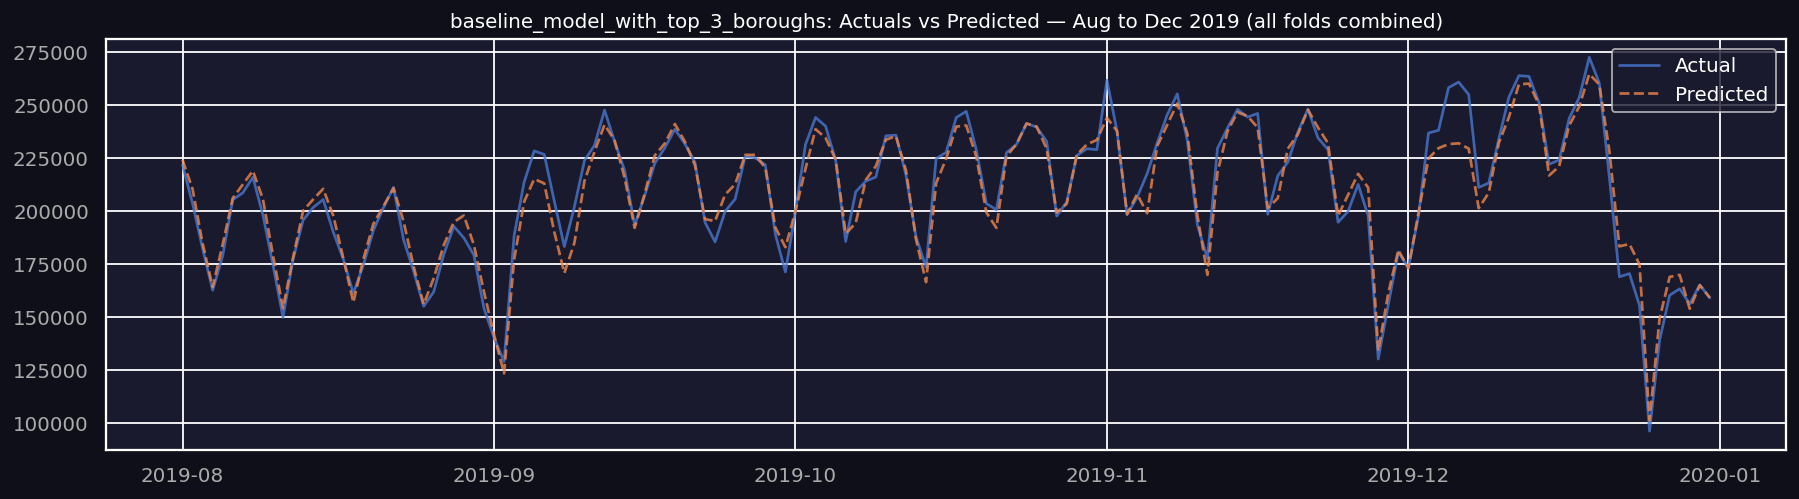

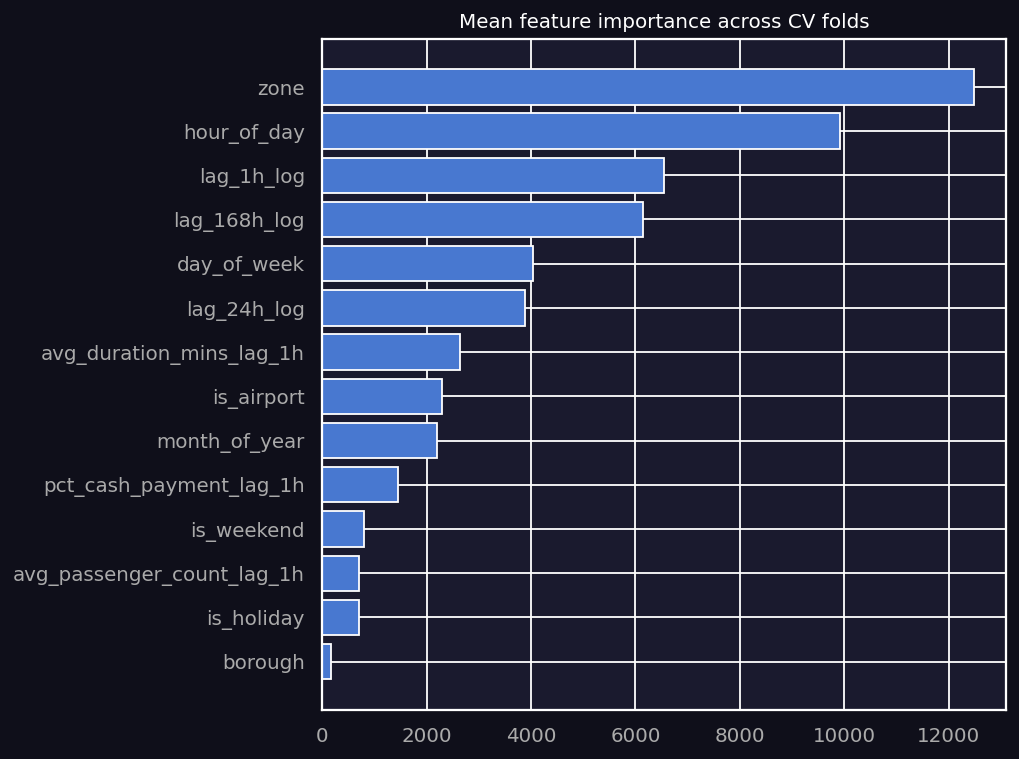

In [ ]:
# Run Analysis

run_model_analysis("baseline_model_with_top_3_boroughs", fold_results, all_fold_preds, feature_importance_frames)

In [ ]:
## Residual Analysis - The model performed worst on the last quarter



#### Test model on 2020 data and save it

In [ ]:
# Load saved model
with open(MODEL_DIR / "baseline_model_top_3_boroughs.pkl", "rb") as f:
    baseline_model = pickle.load(f)
print(f"  Model loaded — best iteration: {baseline_model.best_iteration_}")

  Model loaded — best iteration: 1800


In [ ]:
# Prepare 2020 data

# filter 2020 zone data to top three boroughs
df_zone_2020 = df_zone_2020[df_zone_2020['borough'].isin(['Manhattan', 'Queens', 'Brooklyn'])]

# Create is_airport flag
airport_zones = [
    "JFK Airport",
    "LaGuardia Airport"
]

df_zone_2020["is_airport"] = df_zone_2020["zone"].isin(airport_zones).astype(int)

# Build lag features
df_zone_2020_with_lag = build_lag_features(df_zone_2020).copy()

# #Drop first 168h per zone — these have unavoidably NaN lags
df_zone_2020_with_lag = df_zone_2020_with_lag.dropna(subset=["lag_168h"]).copy()

# Prepare model data and split by year
df_2020_data_with_prepared_feats = prepare_features(df_zone_2020_with_lag).copy()


  Lag features built — 1,721,664 rows (includes spine fill)
DEBUG: Dtypes for specified categorical_cols after conversion:
  zone: category
  hour_of_day: category
  day_of_week: category
  month_of_year: category
  is_holiday: category
  is_weekend: category
  is_airport: category
  borough: category


In [ ]:
# Predict 2020 results based on trained 2019 model

# Subset features only by features we are interested in
df_2020_dat_with_trained_feats_only = df_2020_data_with_prepared_feats.dropna(subset=FEATURES).copy()

# Align results for prediction
X_2020 = align_for_prediction(df_2020_dat_with_trained_feats_only[FEATURES], FEATURES, categorical_cols)

for col in categorical_cols:
    if col in X_2020.columns:
        X_2020[col] = X_2020[col].astype("category")

missing_train_cols = baseline_model.booster_.feature_name()
X_2020 = X_2020.reindex(columns=missing_train_cols)

# Predict on 2020 data and calculate residuals
df_2020_dat_with_trained_feats_only["y_pred"] = np.clip(baseline_model.predict(X_2020), 0, None)
df_2020_dat_with_trained_feats_only["residual"] = df_2020_dat_with_trained_feats_only[TARGET] - df_2020_dat_with_trained_feats_only["y_pred"]
df_2020_dat_with_trained_feats_only["abs_error"] = df_2020_dat_with_trained_feats_only["residual"].abs()

In [ ]:
# Function for evaluating our forecasts
def evaluate_forecast(y_true, y_pred, name="2020 Holdout"):
    actuals = np.asarray(y_true)
    preds = np.asarray(y_pred)

    if len(actuals) == 0:
        return {"error": "No data"}

    mae = mean_absolute_error(actuals, preds)
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    total_actual = actuals.sum()
    mean_demand = actuals.mean()

    wmape = (np.sum(np.abs(preds - actuals)) / total_actual) * 100 if total_actual > 0 else 0
    nmae = (mae / mean_demand) * 100 if mean_demand > 0 else np.nan

    bias_pct = ((preds - actuals).sum() / total_actual) * 100 if total_actual > 0 else np.nan

    return {
        "Period": name,
        "MAE": f"{mae:.2f}",
        "RMSE": f"{rmse:.2f}",
        "Total Actual": f"{total_actual:.0f}",
        "Mean Demand": f"{mean_demand:.1f}",
        "WMAPE": f"{wmape:.1f}%",
        "NMAE": f"{nmae:.1f}%",
        "Bias %": f"{bias_pct:.1f}%",
    }

In [ ]:
metrics_2020 = evaluate_forecast(
    df_2020_dat_with_trained_feats_only["trip_count"],
    df_2020_dat_with_trained_feats_only["y_pred"]
)

metrics_2020_df = pd.DataFrame([metrics_2020])
print(metrics_2020_df)

         Period   MAE   RMSE Total Actual Mean Demand  WMAPE   NMAE Bias %
0  2020 Holdout  5.99  13.33     21478682        35.8  16.7%  16.7%   4.7%


In [ ]:
df_2020_dat_with_trained_feats_only.head()

,zone,pickup_hour_ts,file_month,borough,service_zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,avg_trip_distance_lag_1h,lag_1h,lag_24h,lag_168h,lag_1h_log,lag_24h_log,lag_168h_log,y_pred,residual,abs_error
0,Alphabet City,2020-01-08,2020-01,Manhattan,Yellow Zone,7.0,3.0029,10.8571,7.7143,1.0000,...,7.0975,4.0,4.0,53.0,1.609438,1.609438,3.988984,13.208157,-6.208157,6.208157
2,SoHo,2020-01-08,2020-01,Manhattan,Yellow Zone,28.0,3.0793,11.9286,11.8214,1.5714,...,2.5800,45.0,18.0,115.0,3.828641,2.944439,4.753590,38.624472,-10.624472,10.624472
3,Clinton West,2020-01-08,2020-01,Manhattan,Yellow Zone,26.0,2.5169,9.9038,9.0385,1.4615,...,2.6278,46.0,16.0,180.0,3.850148,2.833213,5.198497,37.984827,-11.984827,11.984827
7,Clinton East,2020-01-08,2020-01,Manhattan,Yellow Zone,134.0,2.5845,11.0224,9.1493,1.6716,...,3.1139,265.0,125.0,440.0,5.583496,4.836282,6.089045,221.122452,-87.122452,87.122452
9,Chinatown,2020-01-08,2020-01,Manhattan,Yellow Zone,10.0,3.6640,13.2000,11.7000,1.2000,...,2.8922,18.0,10.0,40.0,2.944439,2.397895,3.713572,20.575011,-10.575011,10.575011


In [ ]:
df_2020_dat_with_trained_feats_only.info()

<class 'pandas.core.frame.DataFrame'>
Index: 600371 entries, 0 to 1688735
Data columns (total 34 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   zone                        600371 non-null  category      
 1   pickup_hour_ts              600371 non-null  datetime64[ns]
 2   file_month                  600371 non-null  object        
 3   borough                     600371 non-null  category      
 4   service_zone                600371 non-null  object        
 5   trip_count                  600371 non-null  float64       
 6   avg_trip_distance           600371 non-null  float64       
 7   avg_fare_amount             600371 non-null  float64       
 8   avg_duration_mins           600371 non-null  float64       
 9   avg_passenger_count         600371 non-null  float64       
 10  pct_card_payment            600371 non-null  float64       
 11  pct_cash_payment            600371 non-null

### Plot results

#### Plot of actuals vs predictions (overall and borough)

In [ ]:
# ── Colorblind-friendly palette ───────────────────────────────────
CB = {
    'actual'    : '#0072B2',   # deep blue
    'predicted' : '#E69F00',   # orange
    'wmape'     : '#D55E00',   # vermillion
    'residual'  : '#009E73',   # teal
    'covid'     : '#000000',   # black — COVID marker line
    'borough'   : ['#0072B2', '#E69F00', '#009E73'],  # blue, orange, teal
}

# ── Shared prep ───────────────────────────────────────────────────────────────
df = df_2020_dat_with_trained_feats_only.copy()
df['pickup_hour_ts'] = pd.to_datetime(df['pickup_hour_ts'])
df['date']  = df['pickup_hour_ts'].dt.date
df['month'] = df['pickup_hour_ts'].dt.to_period('M').astype(str)
COVID_DATE  = '2020-03-01'

boroughs = sorted(df['borough'].astype(str).unique().tolist())
print("Boroughs:", boroughs)  # confirm which three

# ── Daily aggregation ─────────────────────────────────────────────────────────
daily = (
    df.groupby('date')
    .agg(
        actual    = ('trip_count', 'sum'),
        predicted = ('y_pred',     'sum'),
        abs_error = ('abs_error',  'sum'),
    )
    .reset_index()
)
daily['date']  = pd.to_datetime(daily['date'])
daily['wmape'] = daily['abs_error'] / daily['actual'].replace(0, np.nan) * 100

# ── Monthly aggregation ───────────────────────────────────────────────────────
monthly = (
    df.groupby('month')
    .agg(
        actual    = ('trip_count', 'sum'),
        predicted = ('y_pred',     'sum'),
        abs_error = ('abs_error',  'sum'),
    )
    .reset_index()
)
monthly['wmape']      = monthly['abs_error'] / monthly['actual'].replace(0, np.nan) * 100
monthly['month_dt']   = pd.to_datetime(monthly['month'])

Boroughs: ['Brooklyn', 'Manhattan', 'Queens']


##### BM Plot 1: overall: actuals vs predicted

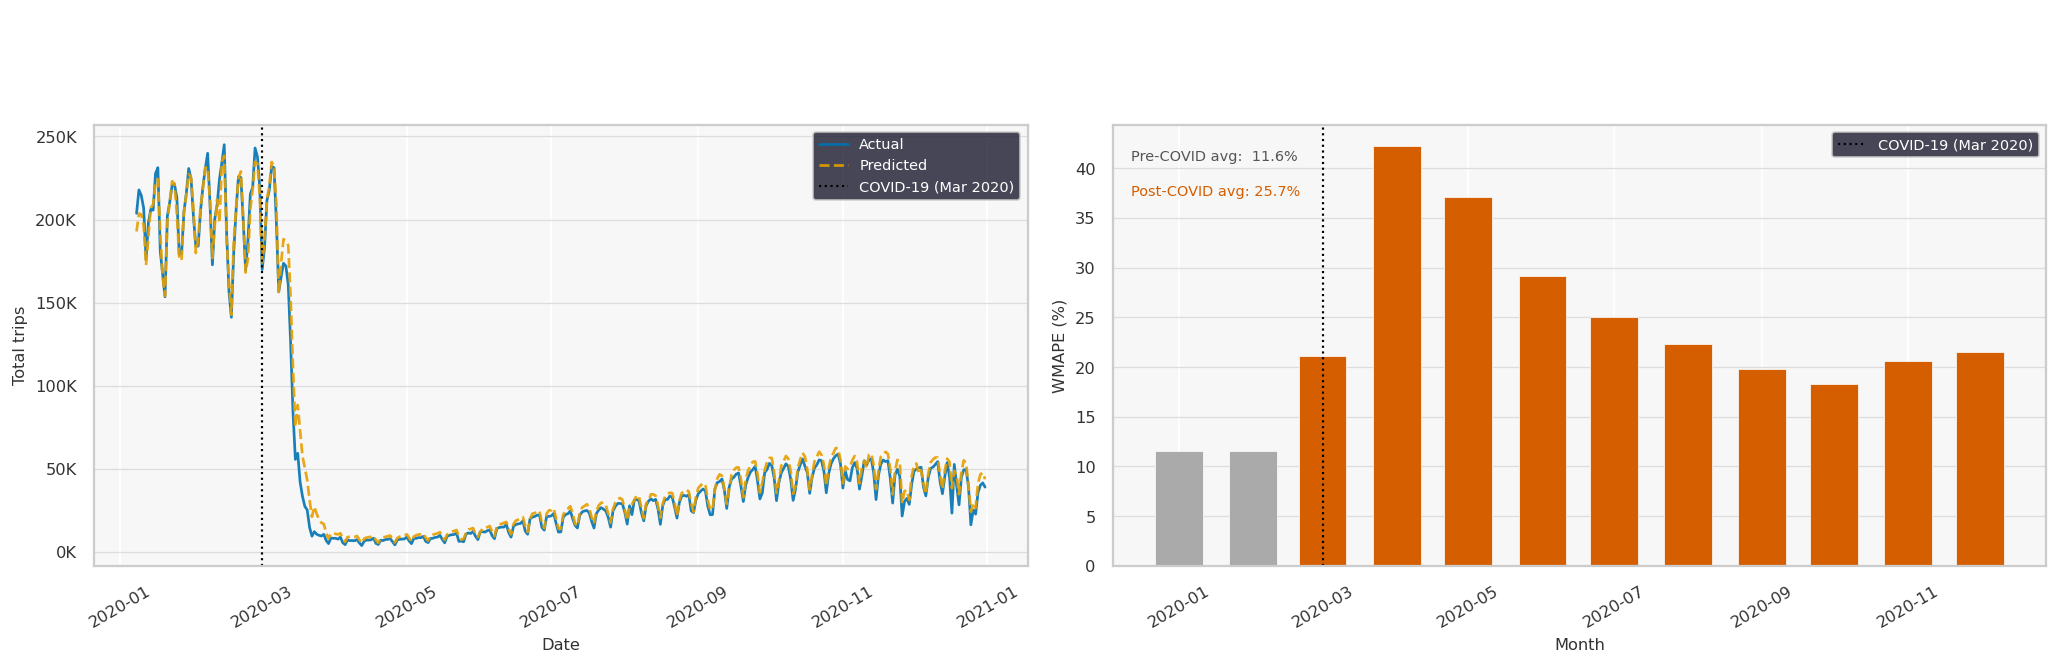

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Overall: actuals vs predicted  +  WMAPE
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

for ax in axes:
    ax.set_facecolor('#f7f7f7')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    ax.tick_params(colors='#333333', labelsize=9)
    ax.xaxis.label.set_color('#333333')
    ax.yaxis.label.set_color('#333333')

# ── Panel A: daily actuals vs predicted ──────────────────────────────────────
ax = axes[0]

ax.plot(daily['date'], daily['actual'],
        color=CB['actual'], linewidth=1.5, label='Actual', alpha=0.9)
ax.plot(daily['date'], daily['predicted'],
        color=CB['predicted'], linewidth=1.5, label='Predicted',
        linestyle='--', alpha=0.9)

ax.axvline(pd.to_datetime(COVID_DATE), color=CB['covid'],
           linewidth=1.2, linestyle=':', label='COVID-19 (Mar 2020)')

ax.set_title('Daily Trip Count — Actual vs Predicted', fontsize=11, pad=8)
ax.set_xlabel('Date')
ax.set_ylabel('Total trips')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(axis='y', color='#dddddd', linewidth=0.7)
ax.tick_params(axis='x', rotation=30)

# ── Panel B: monthly WMAPE ───────────────────────────────────────────────────
ax = axes[1]

bar_colours = [
    CB['wmape'] if str(m) >= '2020-03' else '#aaaaaa'
    for m in monthly['month']
]
ax.bar(monthly['month_dt'], monthly['wmape'],
       color=bar_colours, width=20, edgecolor='white', linewidth=0.4)

ax.axvline(pd.to_datetime(COVID_DATE), color=CB['covid'],
           linewidth=1.2, linestyle=':', label='COVID-19 (Mar 2020)')

ax.set_title('Monthly WMAPE — Prediction Error Over Time', fontsize=11, pad=8)
ax.set_xlabel('Month')
ax.set_ylabel('WMAPE (%)')
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(axis='y', color='#dddddd', linewidth=0.7)
ax.tick_params(axis='x', rotation=30)

# Pre/post annotation
pre  = monthly[monthly['month'] <  '2020-03']['wmape'].mean()
post = monthly[monthly['month'] >= '2020-03']['wmape'].mean()
ax.text(0.02, 0.92, f'Pre-COVID avg:  {pre:.1f}%',
        transform=ax.transAxes, fontsize=8, color='#555555')
ax.text(0.02, 0.84, f'Post-COVID avg: {post:.1f}%',
        transform=ax.transAxes, fontsize=8, color=CB['wmape'])

plt.suptitle('Model Performance Degradation — 2020 (Yellow Zones)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'covid_overall.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


##### BM Plot 2: Residual Analysis for the last few months (Oct - Dec)

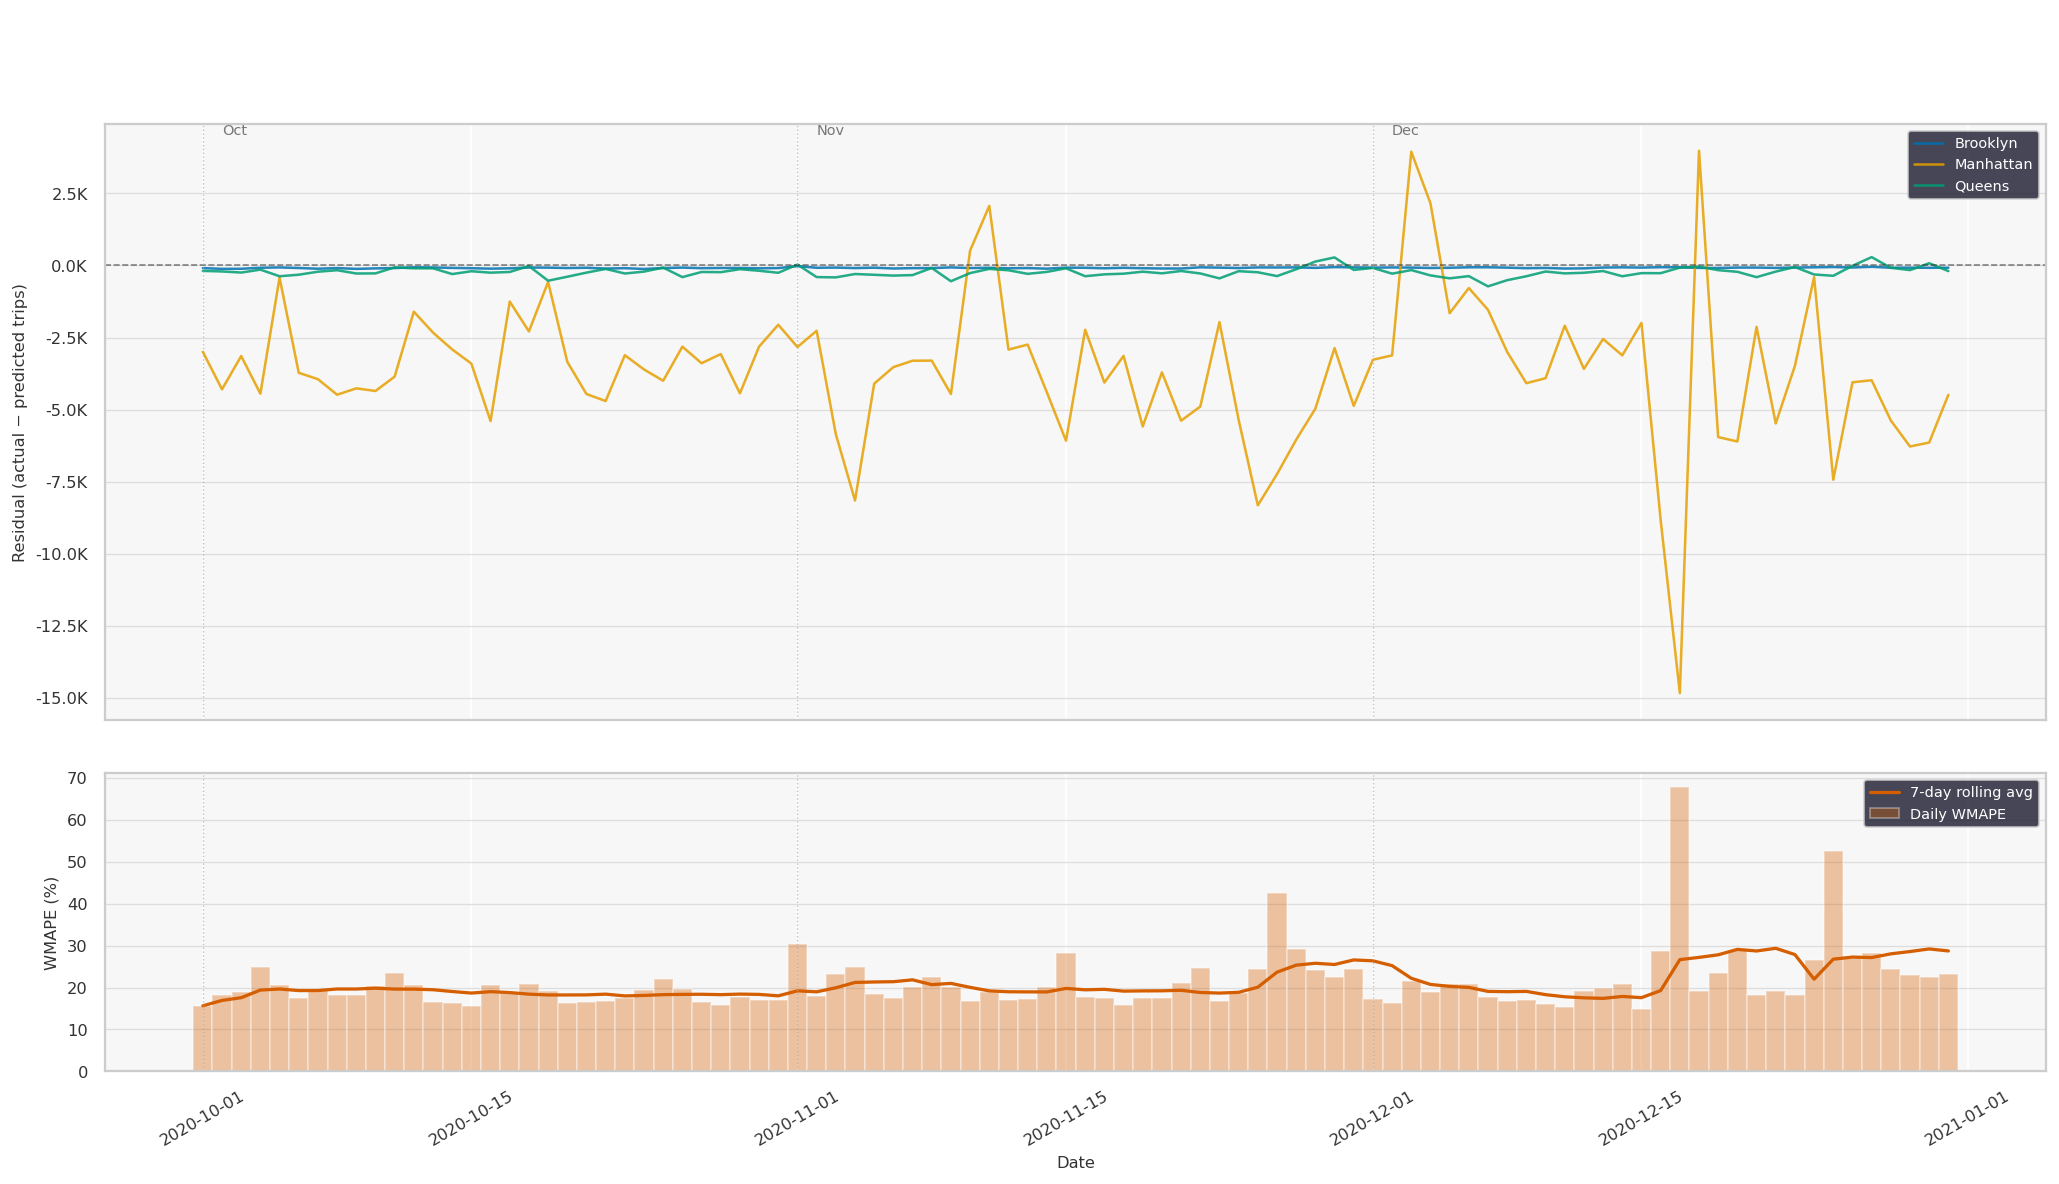

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2A — Residual plot: October–December
# ══════════════════════════════════════════════════════════════════════════════

# ── Filter to Q4 ─────────────────────────────────────────────────────────────
q4 = df[df['month'].isin(['2020-10', '2020-11', '2020-12'])].copy()
q4['residual'] = q4['trip_count'] - q4['y_pred']   # actual − predicted

# ── Daily residuals (total + per borough) ────────────────────────────────────
q4_daily = (
    q4.groupby('date')
    .agg(
        actual    = ('trip_count', 'sum'),
        predicted = ('y_pred',     'sum'),
        abs_error = ('abs_error',  'sum'),
    )
    .reset_index()
)
q4_daily['date']     = pd.to_datetime(q4_daily['date'])
q4_daily['residual'] = q4_daily['actual'] - q4_daily['predicted']
q4_daily['wmape']    = q4_daily['abs_error'] / q4_daily['actual'].replace(0, np.nan) * 100

q4_borough = (
    q4.groupby(['date', 'borough'])
    .agg(
        actual    = ('trip_count', 'sum'),
        predicted = ('y_pred',     'sum'),
    )
    .reset_index()
)
q4_borough['date']     = pd.to_datetime(q4_borough['date'])
q4_borough['residual'] = q4_borough['actual'] - q4_borough['predicted']

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})
fig.patch.set_facecolor('white')

for ax in axes:
    ax.set_facecolor('#f7f7f7')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    ax.tick_params(colors='#333333', labelsize=9)
    ax.xaxis.label.set_color('#333333')
    ax.yaxis.label.set_color('#333333')

# ── Panel A: residuals per borough ───────────────────────────────────────────
ax = axes[0]
for idx, borough in enumerate(boroughs):
    bdf = q4_borough[q4_borough['borough'] == borough]
    ax.plot(bdf['date'], bdf['residual'],
            color=CB['borough'][idx % len(CB['borough'])],
            linewidth=1.4, label=borough, alpha=0.85)

ax.axhline(0, color='#333333', linewidth=0.9, linestyle='--', alpha=0.6)

# Shade months for visual separation
for month_start, label in [('2020-10-01', 'Oct'), ('2020-11-01', 'Nov'), ('2020-12-01', 'Dec')]:
    ax.axvline(pd.to_datetime(month_start), color='#aaaaaa',
               linewidth=0.8, linestyle=':', alpha=0.7)
    ax.text(pd.to_datetime(month_start) + pd.Timedelta(days=1),
            ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 1,
            label, fontsize=8, color='#777777', va='top')

ax.set_title('Daily Residuals by Borough — Oct to Dec 2020', fontsize=11, pad=8)
ax.set_ylabel('Residual (actual − predicted trips)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.1f}K'))
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(axis='y', color='#dddddd', linewidth=0.7)

# ── Panel B: rolling 7-day WMAPE ─────────────────────────────────────────────
ax = axes[1]
q4_daily_sorted = q4_daily.sort_values('date')
q4_daily_sorted['wmape_7d'] = q4_daily_sorted['wmape'].rolling(7, min_periods=1).mean()

ax.bar(q4_daily_sorted['date'], q4_daily_sorted['wmape'],
       color=CB['wmape'], alpha=0.35, width=1, label='Daily WMAPE')
ax.plot(q4_daily_sorted['date'], q4_daily_sorted['wmape_7d'],
        color=CB['wmape'], linewidth=1.8, label='7-day rolling avg')

for month_start in ['2020-10-01', '2020-11-01', '2020-12-01']:
    ax.axvline(pd.to_datetime(month_start), color='#aaaaaa',
               linewidth=0.8, linestyle=':', alpha=0.7)

ax.set_title('Daily WMAPE with 7-day Rolling Average — Q4 2020', fontsize=11, pad=8)
ax.set_xlabel('Date')
ax.set_ylabel('WMAPE (%)')
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(axis='y', color='#dddddd', linewidth=0.7)
ax.tick_params(axis='x', rotation=30)

plt.suptitle('Residual Analysis — Q4 2020 (Oct–Dec)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'residual_q4.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

There is a big spike around 15th December for Manhattan

── Daily breakdown (Manhattan, mid-Dec) ──
      date  actual    predicted    abs_error      residual     wmape
2020-12-17 22062.0 36893.928252 15209.049453 -14831.928252 68.937764
2020-12-20 26621.0 32725.835486  7590.191765  -6104.835486 28.512046
2020-12-16 43830.0 52649.935772 12288.095042  -8819.935772 28.035809
2020-12-24 37680.0 38084.100754  9716.723126   -404.100754 25.787482
2020-12-19 38071.0 44023.313928  8679.980458  -5952.313928 22.799455
2020-12-14 43643.0 46761.964274  8763.481442  -3118.964274 20.079924
2020-12-13 33309.0 35857.807478  6321.435491  -2548.807478 18.978161
2020-12-22 47717.0 53193.541659  8868.150340  -5476.541659 18.584887
2020-12-12 40986.0 44571.447240  7555.780516  -3585.447240 18.435028
2020-12-18 50779.0 46800.226354  9351.055090   3978.773646 18.415201
2020-12-23 47876.0 51357.706348  8331.054303  -3481.706348 17.401317
2020-12-21 43395.0 45527.146817  7527.976540  -2132.146817 17.347567
2020-12-10 51151.0 55060.897310  7887.664994  -3909.897310 1

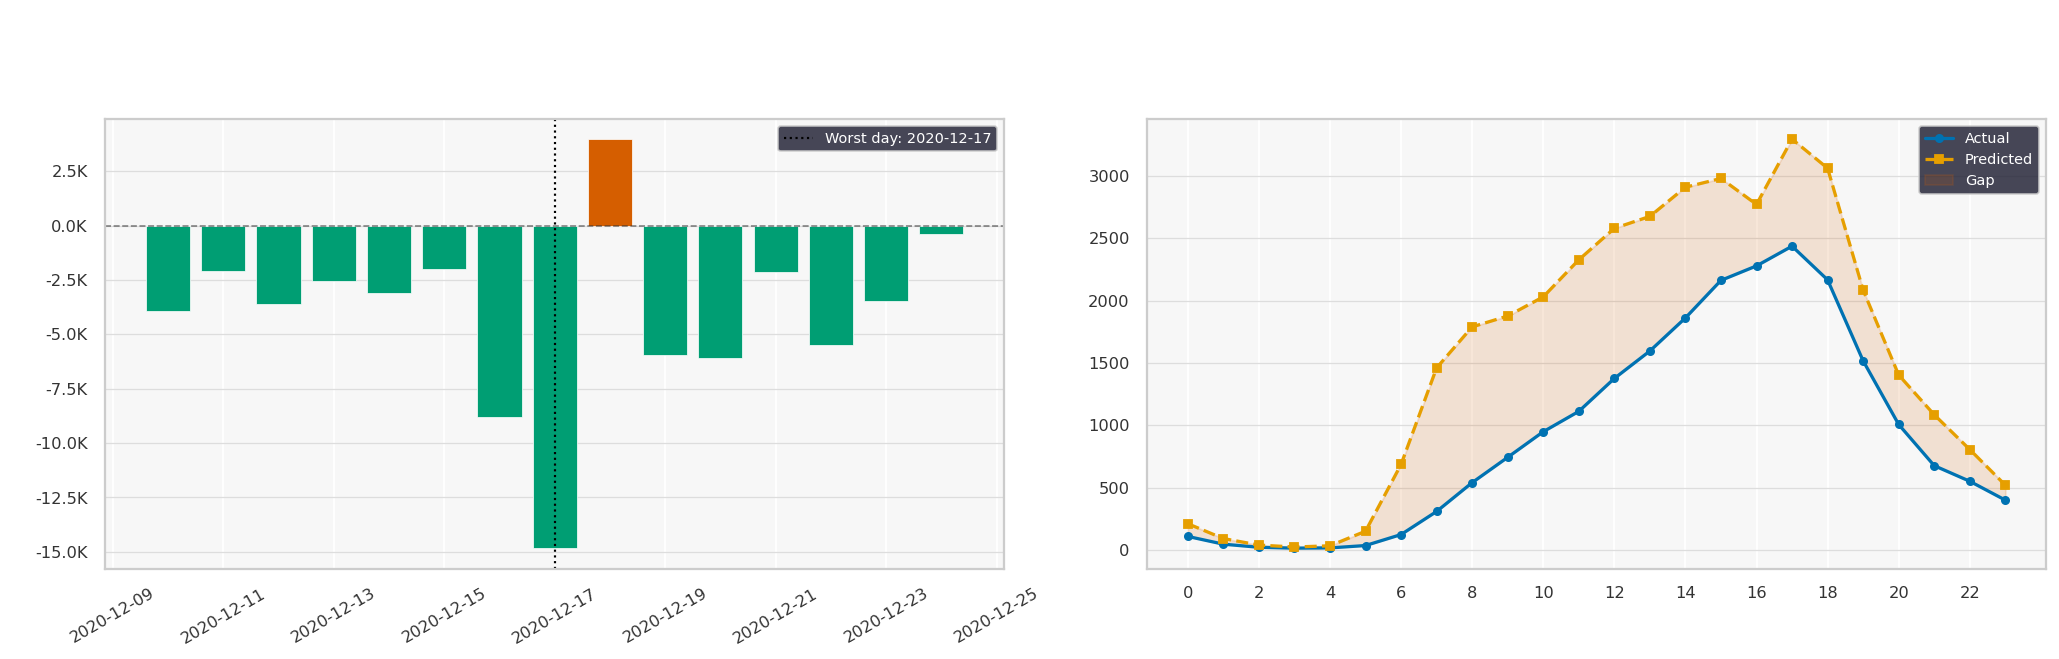

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# DRILL-DOWN — Manhattan mid-December spike
# ══════════════════════════════════════════════════════════════════════════════

# ── Isolate Manhattan, mid-Dec window ────────────────────────────────────────
# Adjust the date window if the spike looks earlier/later in your plot
MID_DEC_START = '2020-12-10'
MID_DEC_END   = '2020-12-25'

spike = df[
    (df['borough'].str.lower() == 'manhattan') &
    (df['pickup_hour_ts'] >= MID_DEC_START) &
    (df['pickup_hour_ts'] <  MID_DEC_END)
].copy()

spike['residual']  = spike['trip_count'] - spike['y_pred']
spike['pct_error'] = spike['residual'] / spike['trip_count'].replace(0, np.nan) * 100
spike['date']      = spike['pickup_hour_ts'].dt.date
spike['hour']      = spike['pickup_hour_ts'].dt.hour

# ── 1. Daily summary — where exactly is the spike? ───────────────────────────
spike_daily = (
    spike.groupby('date')
    .agg(
        actual     = ('trip_count', 'sum'),
        predicted  = ('y_pred',     'sum'),
        abs_error  = ('abs_error',  'sum'),
        residual   = ('residual',   'sum'),
    )
    .reset_index()
)
spike_daily['date']  = pd.to_datetime(spike_daily['date'])
spike_daily['wmape'] = spike_daily['abs_error'] / spike_daily['actual'].replace(0, np.nan) * 100

print("── Daily breakdown (Manhattan, mid-Dec) ──")
print(spike_daily.sort_values('wmape', ascending=False).to_string(index=False))

# ── 2. Hourly breakdown on the worst day ─────────────────────────────────────
worst_day = spike_daily.loc[spike_daily['wmape'].idxmax(), 'date']
print(f"\n── Worst day identified: {worst_day.date()} ──")

worst_hourly = (
    spike[spike['date'] == worst_day.date()]
    .groupby('hour')
    .agg(
        actual    = ('trip_count', 'sum'),
        predicted = ('y_pred',     'sum'),
        abs_error = ('abs_error',  'sum'),
        residual  = ('residual',   'sum'),
    )
    .reset_index()
)
worst_hourly['wmape'] = worst_hourly['abs_error'] / worst_hourly['actual'].replace(0, np.nan) * 100
print(worst_hourly.sort_values('wmape', ascending=False).to_string(index=False))

# ── 3. Raw entries with the largest absolute residuals ───────────────────────
top_entries = (
    spike[['pickup_hour_ts', 'borough', 'hour', 'trip_count', 'y_pred', 'residual', 'pct_error', 'abs_error']]
    .sort_values('abs_error', ascending=False)
    .head(30)
)
print("\n── Top 30 highest-error hourly entries (Manhattan, mid-Dec) ──")
print(top_entries.to_string(index=False))

# ── 4. Visual — actual vs predicted on worst day ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')

for ax in axes:
    ax.set_facecolor('#f7f7f7')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    ax.tick_params(colors='#333333', labelsize=9)

# Panel A: daily residuals across the full mid-Dec window
ax = axes[0]
ax.bar(spike_daily['date'], spike_daily['residual'],
       color=[CB['wmape'] if r > 0 else CB['residual'] for r in spike_daily['residual']],
       width=0.8, edgecolor='white', linewidth=0.4)
ax.axhline(0, color='#333333', linewidth=0.9, linestyle='--', alpha=0.6)
ax.axvline(worst_day, color=CB['covid'], linewidth=1.2,
           linestyle=':', label=f'Worst day: {worst_day.date()}')
ax.set_title('Daily Residuals — Manhattan Dec 10–25', fontsize=11, pad=8)
ax.set_ylabel('Residual (actual − predicted trips)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.1f}K'))
ax.legend(fontsize=8)
ax.grid(axis='y', color='#dddddd', linewidth=0.7)
ax.tick_params(axis='x', rotation=30)

# Panel B: actual vs predicted hour-by-hour on worst day
ax = axes[1]
ax.plot(worst_hourly['hour'], worst_hourly['actual'],
        color=CB['actual'], linewidth=1.8, label='Actual', marker='o', markersize=4)
ax.plot(worst_hourly['hour'], worst_hourly['predicted'],
        color=CB['predicted'], linewidth=1.8, label='Predicted',
        linestyle='--', marker='s', markersize=4)
ax.fill_between(worst_hourly['hour'],
                worst_hourly['actual'], worst_hourly['predicted'],
                alpha=0.15, color=CB['wmape'], label='Gap')
ax.set_title(f'Actual vs Predicted by Hour — {worst_day.date()} (Manhattan)', fontsize=11, pad=8)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Trip count')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8, framealpha=0.8)
ax.grid(axis='y', color='#dddddd', linewidth=0.7)

plt.suptitle('Manhattan Mid-December Spike — Root Entry Analysis',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'manhattan_dec_spike.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

Turns out on December 17, 2020, Manhattan was hit by **Winter Storm Gail**, one of the most significant early-season nor'easters in years. The storm dumped about \(10\) inches of snow in Central Park, causing a public spectacle while creating unique logistical challenges amid the COVID-\(19\) pandemic.

##### BM Plot 3: Actuals vs predicted WMAPE

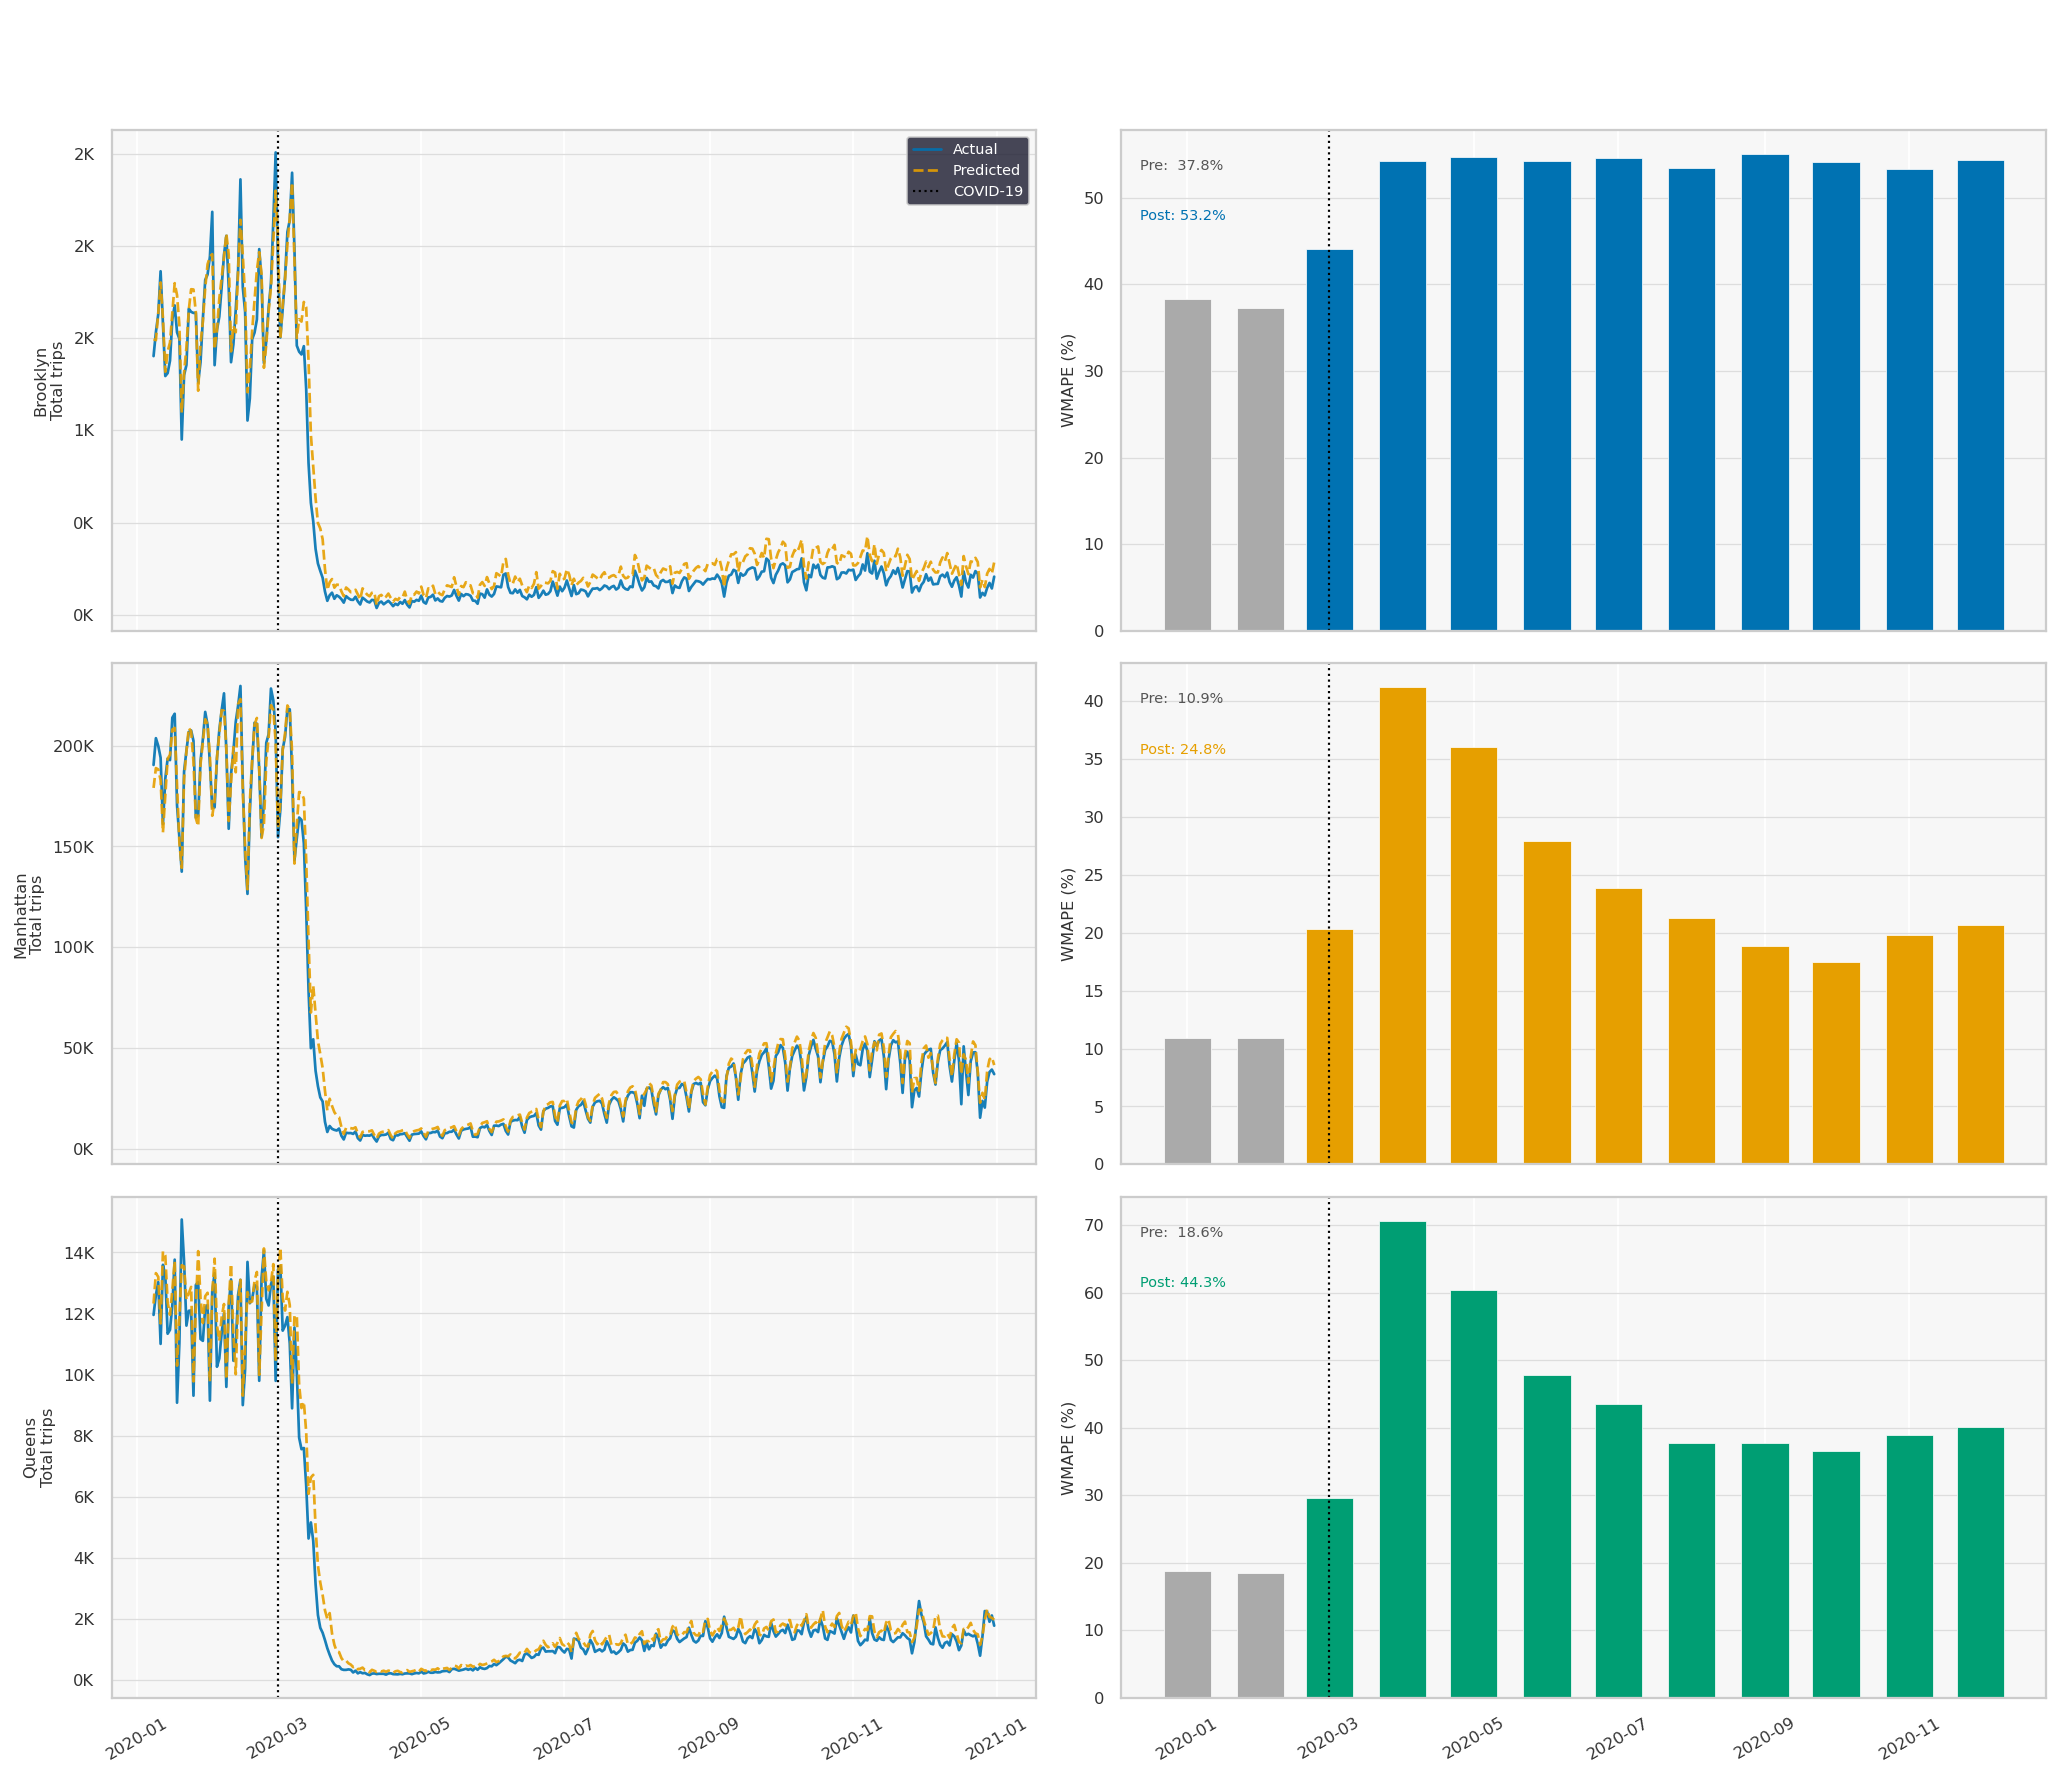

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — By borough: actuals vs predicted  +  WMAPE
# ══════════════════════════════════════════════════════════════════════════════
daily_b = (
    df.groupby(['date', 'borough'])
    .agg(actual=('trip_count','sum'), predicted=('y_pred','sum'),
         abs_error=('abs_error','sum'))
    .reset_index()
)
daily_b['date']  = pd.to_datetime(daily_b['date'])
daily_b['wmape'] = daily_b['abs_error'] / daily_b['actual'].replace(0, np.nan) * 100

monthly_b = (
    df.groupby(['month', 'borough'])
    .agg(actual=('trip_count','sum'), predicted=('y_pred','sum'),
         abs_error=('abs_error','sum'))
    .reset_index()
)
monthly_b['wmape']    = monthly_b['abs_error'] / monthly_b['actual'].replace(0, np.nan) * 100
monthly_b['month_dt'] = pd.to_datetime(monthly_b['month'])

fig, axes = plt.subplots(len(boroughs), 2,
                          figsize=(16, 4.5 * len(boroughs)),
                          sharex='col')
fig.patch.set_facecolor('white')

for ax in axes.flat:
    ax.set_facecolor('#f7f7f7')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    ax.tick_params(colors='#333333', labelsize=9)
    ax.xaxis.label.set_color('#333333')
    ax.yaxis.label.set_color('#333333')

for row, (borough, colour) in enumerate(zip(boroughs, CB['borough'])):

    b_daily   = daily_b[daily_b['borough']   == borough]
    b_monthly = monthly_b[monthly_b['borough'] == borough]

    # ── Left: actuals vs predicted ───────────────────────────────────────────
    ax = axes[row, 0]
    ax.plot(b_daily['date'], b_daily['actual'],
            color=CB['actual'], linewidth=1.5, label='Actual', alpha=0.9)
    ax.plot(b_daily['date'], b_daily['predicted'],
            color=CB['predicted'], linewidth=1.5, label='Predicted',
            linestyle='--', alpha=0.9)
    ax.axvline(pd.to_datetime(COVID_DATE), color=CB['covid'],
               linewidth=1.2, linestyle=':', label='COVID-19')

    ax.set_ylabel(f'{borough}\nTotal trips', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
    ax.grid(axis='y', color='#dddddd', linewidth=0.7)
    ax.tick_params(axis='x', rotation=30)
    if row == 0:
        ax.set_title('Daily Actual vs Predicted', fontsize=11, pad=8)
        ax.legend(fontsize=8, framealpha=0.8)

    # ── Right: WMAPE ─────────────────────────────────────────────────────────
    ax = axes[row, 1]
    bar_colours = [
        colour if str(m) >= '2020-03' else '#aaaaaa'
        for m in b_monthly['month']
    ]
    ax.bar(b_monthly['month_dt'], b_monthly['wmape'],
           color=bar_colours, width=20,
           edgecolor='white', linewidth=0.4)
    ax.axvline(pd.to_datetime(COVID_DATE), color=CB['covid'],
               linewidth=1.2, linestyle=':')

    pre  = b_monthly[b_monthly['month'] <  '2020-03']['wmape'].mean()
    post = b_monthly[b_monthly['month'] >= '2020-03']['wmape'].mean()
    ax.text(0.02, 0.92, f'Pre:  {pre:.1f}%',
            transform=ax.transAxes, fontsize=8, color='#555555')
    ax.text(0.02, 0.82, f'Post: {post:.1f}%',
            transform=ax.transAxes, fontsize=8, color=colour)

    ax.set_ylabel('WMAPE (%)', fontsize=9)
    ax.grid(axis='y', color='#dddddd', linewidth=0.7)
    ax.tick_params(axis='x', rotation=30)
    if row == 0:
        ax.set_title('Monthly WMAPE', fontsize=11, pad=8)

plt.suptitle('Model Performance by Borough — 2020',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'covid_by_borough.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


### Save results

In [ ]:
# Save results
df_2020_dat_with_trained_feats_only.to_parquet(PREDICT_DIR / "2020_predictions_with_top_3_boroughs_only.parquet", index=False)


### Save baseline snapshot

In [ ]:
def save_distribution_snapshot(df, features, label, save_dir):
    """
    Persist feature distribution statistics for a reference window.
    Saves mean, std, quantiles, and a sample for future KS re-testing.
    """
    snapshot = {
        "label": label,
        "created_at": pd.Timestamp.now().isoformat(),
        "n_rows": len(df),
        "features": {}
    }
    for col in features:
        vals = pd.to_numeric(df[col], errors='coerce').dropna()
        snapshot["features"][col] = {
            "mean":   round(float(vals.mean()), 6),
            "std":    round(float(vals.std()),  6),
            "min":    round(float(vals.min()),  6),
            "max":    round(float(vals.max()),  6),
            "q25":    round(float(vals.quantile(0.25)), 6),
            "q50":    round(float(vals.quantile(0.50)), 6),
            "q75":    round(float(vals.quantile(0.75)), 6),
            "sample": vals.sample(min(500, len(vals)), random_state=42).tolist()
        }

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    out_path = save_dir / f"snapshot_{label}.json"
    with open(out_path, "w") as f:
        json.dump(snapshot, f)
    print(f"Snapshot saved → {out_path}")
    return snapshot

# --- Call this right after training your baseline model ---
SNAPSHOT_DIR = BASE / "baseline_snapshots"

numerical_features = [
    'pct_cash_payment_lag_1h', 'avg_duration_mins_lag_1h',
    'avg_passenger_count_lag_1h', 'lag_1h_log', 'lag_24h_log', 'lag_168h_log'
]


In [ ]:
save_distribution_snapshot(
    df      = baseline_model_data_with_prepared_feats,
    features= numerical_features,
    label   = "2019_baseline",
    save_dir= SNAPSHOT_DIR
)

# Section 9: Drift Detection

## Prepare reference and monitoring datasets

In [ ]:
# TODO: Update dataframe name to df_2020_dat_with_trained_feats_only or assign it as monitoring data

In [ ]:
# Check if any NAs exist (returns True/False)
df_2020_data_with_prepared_feats['is_airport'].isna().any()

# Count how many NAs are in the column
df_2020_data_with_prepared_feats['is_airport'].isna().sum()

df_2020_data_with_prepared_feats['is_airport'].unique()

[0.0, NaN, 1.0]
Categories (2, float64): [0.0, 1.0]

In [ ]:
# Display only the rows where this column has an NA
df_2020_data_with_prepared_feats[df_2020_data_with_prepared_feats['is_airport'].isna()]

,zone,pickup_hour_ts,file_month,borough,service_zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,avg_passenger_count_lag_1h,avg_duration_mins_lag_1h,avg_fare_amount_lag_1h,avg_trip_distance_lag_1h,lag_1h,lag_24h,lag_168h,lag_1h_log,lag_24h_log,lag_168h_log
1,Cobble Hill,2020-01-08 00:00:00,2020-01,Brooklyn,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,2.0,0.000000,0.000000,1.098612
4,South Jamaica,2020-01-08 00:00:00,2020-01,Queens,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,1.0,0.0,0.000000,0.693147,0.000000
5,Clinton Hill,2020-01-08 00:00:00,2020-01,Brooklyn,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,1.5,5.5,5.75,0.95,2.0,1.0,9.0,1.098612,0.693147,2.302585
6,South Ozone Park,2020-01-08 00:00:00,2020-01,Queens,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,1.0,0.000000,0.000000,0.693147
8,South Williamsburg,2020-01-08 00:00:00,2020-01,Brooklyn,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,1.0,0.0,0.000000,0.693147,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688723,North Corona,2020-12-31 23:00:00,2020-12,Queens,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,1.0,26.0,13.50,3.82,1.0,0.0,0.0,0.693147,0.000000,0.000000
1688724,Murray Hill-Queens,2020-12-31 23:00:00,2020-12,Queens,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.000000,0.000000,0.000000
1688727,Midwood,2020-12-31 23:00:00,2020-12,Brooklyn,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.000000,0.000000,0.000000
1688732,Middle Village,2020-12-31 23:00:00,2020-12,Queens,Boro Zone,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.000000,0.000000,0.000000


In [ ]:
df_2020_data_with_prepared_feats[df_2020_data_with_prepared_feats['is_airport']== 0.0]

,zone,pickup_hour_ts,file_month,borough,service_zone,trip_count,avg_trip_distance,avg_fare_amount,avg_duration_mins,avg_passenger_count,...,avg_passenger_count_lag_1h,avg_duration_mins_lag_1h,avg_fare_amount_lag_1h,avg_trip_distance_lag_1h,lag_1h,lag_24h,lag_168h,lag_1h_log,lag_24h_log,lag_168h_log
0,Alphabet City,2020-01-08 00:00:00,2020-01,Manhattan,Yellow Zone,7.0,3.0029,10.8571,7.7143,1.0000,...,1.5000,29.7500,22.3750,7.0975,4.0,4.0,53.0,1.609438,1.609438,3.988984
2,SoHo,2020-01-08 00:00:00,2020-01,Manhattan,Yellow Zone,28.0,3.0793,11.9286,11.8214,1.5714,...,1.1556,10.6222,11.0444,2.5800,45.0,18.0,115.0,3.828641,2.944439,4.753590
3,Clinton West,2020-01-08 00:00:00,2020-01,Manhattan,Yellow Zone,26.0,2.5169,9.9038,9.0385,1.4615,...,1.4783,9.1957,10.3152,2.6278,46.0,16.0,180.0,3.850148,2.833213,5.198497
7,Clinton East,2020-01-08 00:00:00,2020-01,Manhattan,Yellow Zone,134.0,2.5845,11.0224,9.1493,1.6716,...,1.6679,12.1547,12.1038,3.1139,265.0,125.0,440.0,5.583496,4.836282,6.089045
9,Chinatown,2020-01-08 00:00:00,2020-01,Manhattan,Yellow Zone,10.0,3.6640,13.2000,11.7000,1.2000,...,1.3889,12.2778,11.6944,2.8922,18.0,10.0,40.0,2.944439,2.397895,3.713572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688729,Midtown North,2020-12-31 23:00:00,2020-12,Manhattan,Yellow Zone,13.0,2.4692,10.1923,10.3846,1.4615,...,1.7857,11.4286,13.5000,3.4336,14.0,7.0,10.0,2.708050,2.079442,2.397895
1688730,Midtown East,2020-12-31 23:00:00,2020-12,Manhattan,Yellow Zone,13.0,2.6515,10.9231,10.4615,1.3846,...,1.1154,9.3462,10.1731,2.5896,26.0,17.0,21.0,3.295837,2.890372,3.091042
1688731,Midtown Center,2020-12-31 23:00:00,2020-12,Manhattan,Yellow Zone,19.0,2.6237,11.8947,13.4737,2.0000,...,1.4231,9.5000,9.0769,2.0735,26.0,20.0,11.0,3.295837,3.044522,2.484907
1688733,Meatpacking/West Village West,2020-12-31 23:00:00,2020-12,Manhattan,Yellow Zone,2.0,1.1000,6.0000,4.5000,2.0000,...,1.7500,13.2500,12.7500,3.3850,8.0,0.0,2.0,2.197225,0.000000,1.098612


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════════════════════════

# Fix is_airport nulls before anything else
ref_data = baseline_model_data_with_prepared_feats.copy()
mon_data = df_2020_data_with_prepared_feats_only.copy()

ref_data['is_airport'] = ref_data['is_airport'].fillna(0)
mon_data['is_airport'] = mon_data['is_airport'].fillna(0)

# Feature groups
exogenous_features = [
    'hour_of_day', 'day_of_week', 'month_of_year',
    'is_weekend',  'is_holiday',  'is_airport',
]
demand_derived_features = [
    'pct_cash_payment_lag_1h',
    'avg_duration_mins_lag_1h',
    'avg_passenger_count_lag_1h',
    'lag_1h_log',
    'lag_24h_log',
    'lag_168h_log',
]
features_to_monitor = exogenous_features + demand_derived_features

# Thresholds
THRESHOLDS = {
    'psi':        {'moderate': 0.10, 'significant': 0.20},
    'js':         {'moderate': 0.05, 'significant': 0.10},
    'wass_norm':  {'moderate': 0.05, 'significant': 0.10},
}

MONTHS_2020 = [f'2020-{m:02d}' for m in range(1, 13)]

NameError: name 'df_2020_data_with_prepared_feats_only' is not defined

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# METRIC FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════

def compute_psi(ref, cur, bins=10):
    """PSI — magnitude of population shift."""
    ref = pd.to_numeric(ref, errors='coerce').dropna()
    cur = pd.to_numeric(cur, errors='coerce').dropna()
    if len(ref) == 0 or len(cur) == 0:
        return np.nan

    breakpoints = np.linspace(ref.min(), ref.max(), bins + 1)
    breakpoints[0]  -= 1e-6
    breakpoints[-1] += 1e-6

    ref_counts, _ = np.histogram(ref, bins=breakpoints)
    cur_counts, _ = np.histogram(cur, bins=breakpoints)

    ref_pct = ref_counts / len(ref)
    cur_pct = cur_counts / len(cur)

    # Avoid log(0) — replace zeros with small value
    ref_pct = np.where(ref_pct == 0, 1e-6, ref_pct)
    cur_pct = np.where(cur_pct == 0, 1e-6, cur_pct)

    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))


def compute_js(ref, cur, bins=10):
    """JS divergence — bounded [0,1], symmetric."""
    ref = pd.to_numeric(ref, errors='coerce').dropna()
    cur = pd.to_numeric(cur, errors='coerce').dropna()
    if len(ref) == 0 or len(cur) == 0:
        return np.nan

    breakpoints = np.linspace(
        min(ref.min(), cur.min()),
        max(ref.max(), cur.max()),
        bins + 1
    )
    ref_counts, _ = np.histogram(ref, bins=breakpoints)
    cur_counts, _ = np.histogram(cur, bins=breakpoints)

    ref_pct = ref_counts / ref_counts.sum()
    cur_pct = cur_counts / cur_counts.sum()

    return float(jensenshannon(ref_pct, cur_pct))


def compute_wasserstein_norm(ref, cur):
    """Wasserstein distance normalised by reference std — comparable across features."""
    ref = pd.to_numeric(ref, errors='coerce').dropna()
    cur = pd.to_numeric(cur, errors='coerce').dropna()
    if len(ref) == 0 or len(cur) == 0:
        return np.nan

    ref_std = ref.std()
    if ref_std == 0:
        return 0.0

    return float(wasserstein_distance(ref, cur) / ref_std)


def compute_ks(ref, cur):
    """KS test — returns (statistic, p_value). Shown but not in vote."""
    ref = pd.to_numeric(ref, errors='coerce').dropna()
    cur = pd.to_numeric(cur, errors='coerce').dropna()
    if len(ref) == 0 or len(cur) == 0:
        return np.nan, np.nan

    stat, pval = ks_2samp(ref, cur)
    return round(float(stat), 4), round(float(pval), 4)


def classify_drift(psi, js, wass_norm):
    """
    Voting logic — 2/3 metrics must agree to flag drift.
    Level is determined by how many flag significant vs moderate.
    """
    def level(val, metric):
        if pd.isna(val):
            return 0
        t = THRESHOLDS[metric]
        if val >= t['significant']:
            return 2
        elif val >= t['moderate']:
            return 1
        return 0

    levels = [level(psi, 'psi'), level(js, 'js'), level(wass_norm, 'wass_norm')]
    votes_drifted    = sum(l >= 1 for l in levels)
    votes_significant = sum(l >= 2 for l in levels)

    if votes_drifted    >= 2 and votes_significant >= 2:
        return 'SIGNIFICANT DRIFT'
    elif votes_drifted  >= 2:
        return 'MODERATE DRIFT'
    else:
        return 'STABLE'

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MAIN DRIFT LOOP
# ══════════════════════════════════════════════════════════════════════════════

def run_drift_analysis(ref_df, mon_df, features, group_label='Overall'):
    """
    Runs drift analysis for each feature × month.
    Returns a detailed DataFrame with all metric scores + drift label.
    """
    records = []

    for month in MONTHS_2020:
        cur = mon_df[mon_df['file_month'] == month]
        if cur.empty:
            continue

        for feat in features:
            if feat not in ref_df.columns or feat not in cur.columns:
                continue

            ref_vals = ref_df[feat]
            cur_vals = cur[feat]

            psi       = compute_psi(ref_vals, cur_vals)
            js        = compute_js(ref_vals, cur_vals)
            wass_norm = compute_wasserstein_norm(ref_vals, cur_vals)
            ks_stat, ks_pval = compute_ks(ref_vals, cur_vals)
            label     = classify_drift(psi, js, wass_norm)

            records.append({
                'group'         : group_label,
                'feature'       : feat,
                'month'         : month,
                'psi'           : round(psi,       4) if not np.isnan(psi)       else np.nan,
                'js'            : round(js,        4) if not np.isnan(js)        else np.nan,
                'wass_norm'     : round(wass_norm, 4) if not np.isnan(wass_norm) else np.nan,
                'ks_stat'       : ks_stat,
                'ks_pval'       : ks_pval,
                'drift_label'   : label,
            })

    return pd.DataFrame(records)


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY PIVOT
# ══════════════════════════════════════════════════════════════════════════════

def make_summary_pivot(detail_df):
    """
    Pivot detailed results into a feature × month summary table.
    Each cell shows the drift label — easy to scan for patterns.
    """
    pivot = detail_df.pivot_table(
        index   = ['group', 'feature'],
        columns = 'month',
        values  = 'drift_label',
        aggfunc = 'first'
    )
    # Shorten month labels for readability
    pivot.columns = [m[5:] for m in pivot.columns]  # '2020-03' → '03'
    return pivot

## Covariate Drift Results

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# RUN — Overall, Service Zone, Borough
# ══════════════════════════════════════════════════════════════════════════════

all_results = []

# ── Overall ───────────────────────────────────────────────────────────────────
print("Running overall drift...")
overall = run_drift_analysis(ref_data, mon_data, features_to_monitor, 'Overall')
all_results.append(overall)

# ── By service zone ───────────────────────────────────────────────────────────
for sz in ref_data['service_zone'].dropna().unique():
    print(f"Running drift — service zone: {sz}...")
    ref_sz = ref_data[ref_data['service_zone'] == sz]
    mon_sz = mon_data[mon_data['service_zone'] == sz]
    result = run_drift_analysis(ref_sz, mon_sz, features_to_monitor, f'SZ: {sz}')
    all_results.append(result)

# ── By borough ────────────────────────────────────────────────────────────────
for b in ref_data['borough'].astype(str).unique():
    if b in ['EWR', 'Unknown']:
        continue
    print(f"Running drift — borough: {b}...")
    ref_b = ref_data[ref_data['borough'].astype(str) == b]
    mon_b = mon_data[mon_data['borough'].astype(str) == b]
    result = run_drift_analysis(ref_b, mon_b, features_to_monitor, f'Borough: {b}')
    all_results.append(result)

# ── Combine ───────────────────────────────────────────────────────────────────
drift_detailed = pd.concat(all_results, ignore_index=True)
drift_summary  = make_summary_pivot(drift_detailed)

print(f"\nDone — {len(drift_detailed):,} feature-month-group combinations")

Running overall drift...
Running drift — service zone: Yellow Zone...
Running drift — service zone: Boro Zone...
Running drift — service zone: Airports...
Running drift — borough: Manhattan...
Running drift — borough: Brooklyn...
Running drift — borough: Queens...

Done — 1,008 feature-month-group combinations


In [ ]:
# Save results

# ── Save detailed table ───────────────────────────────────────────────────────
drift_detailed.to_csv(DRIFT_DIR / 'drift_detailed.csv', index=False)
print(f"Saved detailed: {len(drift_detailed):,} rows")

# ── Save summary pivot ────────────────────────────────────────────────────────
# Reset index so group and feature become regular columns
drift_summary.reset_index().to_csv(DRIFT_DIR / 'drift_summary.csv', index=False)
print("Saved summary")

# ── Reload ────────────────────────────────────────────────────────────────────
# drift_detailed = pd.read_csv(DRIFT_DIR / 'drift_detailed.csv')
# drift_summary  = pd.read_csv(DRIFT_DIR / 'drift_summary.csv').set_index(['group', 'feature'])

Saved detailed: 1,008 rows
Saved summary


In [ ]:
# ── View detailed table for a specific group ──────────────────────────────────
def view_detailed(group_label):
    df = drift_detailed[drift_detailed['group'] == group_label].copy()
    df = df.drop(columns='group').sort_values(['feature', 'month'])

    # Changed applymap to map to keep up with modern Pandas syntax
    display(df.style.map(
        lambda v: 'background-color: #ffcccc; color: black;' if v == 'SIGNIFICANT DRIFT'
             else 'background-color: #fff3cc; color: black;' if v == 'MODERATE DRIFT'
             else '',
        subset=['drift_label']
    ))

# ── View summary pivot for a specific group ───────────────────────────────────
def view_summary(group_label):
    df = drift_summary.loc[[group_label]] if group_label in drift_summary.index.get_level_values(0) else drift_summary

    # Appended color: black; to all styled states
    display(df.style.map(
        lambda v: 'background-color: #ffcccc; font-weight: bold; color: black;' if v == 'SIGNIFICANT DRIFT'
             else 'background-color: #fff3cc; color: black;'                    if v == 'MODERATE DRIFT'
             else 'background-color: #e8f5e9; color: black;'                    if v == 'STABLE'
             else ''
    ))

# ── Usage ─────────────────────────────────────────────────────────────────────
view_detailed('Overall')
view_summary('Overall')

view_detailed('SZ: Yellow Zone')
view_summary('SZ: Yellow Zone')

view_detailed('Borough: Manhattan')
view_summary('Borough: Manhattan')

,feature,month,psi,js,wass_norm,ks_stat,ks_pval,drift_label
7,avg_duration_mins_lag_1h,2020-01,0.043400,0.073300,0.179000,0.089200,0.000000,MODERATE DRIFT
19,avg_duration_mins_lag_1h,2020-02,0.035300,0.066200,0.166200,0.075600,0.000000,MODERATE DRIFT
31,avg_duration_mins_lag_1h,2020-03,0.128400,0.124900,0.358900,0.213400,0.000000,SIGNIFICANT DRIFT
43,avg_duration_mins_lag_1h,2020-04,0.399200,0.210300,0.603000,0.388000,0.000000,SIGNIFICANT DRIFT
55,avg_duration_mins_lag_1h,2020-05,0.325400,0.192500,0.561600,0.352100,0.000000,SIGNIFICANT DRIFT
67,avg_duration_mins_lag_1h,2020-06,0.228800,0.164400,0.493300,0.294200,0.000000,SIGNIFICANT DRIFT
79,avg_duration_mins_lag_1h,2020-07,0.213000,0.158900,0.465400,0.271300,0.000000,SIGNIFICANT DRIFT
91,avg_duration_mins_lag_1h,2020-08,0.194600,0.152400,0.441800,0.252200,0.000000,SIGNIFICANT DRIFT
103,avg_duration_mins_lag_1h,2020-09,0.172100,0.143900,0.414500,0.230000,0.000000,SIGNIFICANT DRIFT
115,avg_duration_mins_lag_1h,2020-10,0.166100,0.141300,0.404100,0.217300,0.000000,SIGNIFICANT DRIFT


,feature,month,psi,js,wass_norm,ks_stat,ks_pval,drift_label
151,avg_duration_mins_lag_1h,2020-01,0.038400,0.068500,0.227800,0.121200,0.000000,MODERATE DRIFT
163,avg_duration_mins_lag_1h,2020-02,0.022400,0.052400,0.169200,0.084600,0.000000,MODERATE DRIFT
175,avg_duration_mins_lag_1h,2020-03,0.392600,0.197600,0.706200,0.317900,0.000000,SIGNIFICANT DRIFT
187,avg_duration_mins_lag_1h,2020-04,1.401700,0.403600,1.481600,0.624200,0.000000,SIGNIFICANT DRIFT
199,avg_duration_mins_lag_1h,2020-05,1.082100,0.193600,1.276200,0.538900,0.000000,SIGNIFICANT DRIFT
211,avg_duration_mins_lag_1h,2020-06,0.655100,0.282100,0.977900,0.410800,0.000000,SIGNIFICANT DRIFT
223,avg_duration_mins_lag_1h,2020-07,0.540400,0.256800,0.833300,0.363900,0.000000,SIGNIFICANT DRIFT
235,avg_duration_mins_lag_1h,2020-08,0.425200,0.228400,0.726400,0.323400,0.000000,SIGNIFICANT DRIFT
247,avg_duration_mins_lag_1h,2020-09,0.296500,0.192300,0.641000,0.273200,0.000000,SIGNIFICANT DRIFT
259,avg_duration_mins_lag_1h,2020-10,0.218200,0.164300,0.566500,0.233400,0.000000,SIGNIFICANT DRIFT


,feature,month,psi,js,wass_norm,ks_stat,ks_pval,drift_label
583,avg_duration_mins_lag_1h,2020-01,0.061800,0.087500,0.181400,0.108100,0.000000,MODERATE DRIFT
595,avg_duration_mins_lag_1h,2020-02,0.035900,0.066800,0.143700,0.078200,0.000000,MODERATE DRIFT
607,avg_duration_mins_lag_1h,2020-03,0.127800,0.125100,0.541500,0.290000,0.000000,SIGNIFICANT DRIFT
619,avg_duration_mins_lag_1h,2020-04,0.327400,0.194600,1.104900,0.564200,0.000000,SIGNIFICANT DRIFT
631,avg_duration_mins_lag_1h,2020-05,0.239900,0.168800,0.946400,0.484000,0.000000,SIGNIFICANT DRIFT
643,avg_duration_mins_lag_1h,2020-06,0.145600,0.133200,0.723200,0.364500,0.000000,SIGNIFICANT DRIFT
655,avg_duration_mins_lag_1h,2020-07,0.138700,0.130100,0.621300,0.317200,0.000000,SIGNIFICANT DRIFT
667,avg_duration_mins_lag_1h,2020-08,0.123300,0.122900,0.546600,0.282900,0.000000,SIGNIFICANT DRIFT
679,avg_duration_mins_lag_1h,2020-09,0.116900,0.119700,0.492700,0.240300,0.000000,SIGNIFICANT DRIFT
691,avg_duration_mins_lag_1h,2020-10,0.099600,0.110700,0.439500,0.206100,0.000000,SIGNIFICANT DRIFT


## Change-Point Detection: When exactly does our data changes?

**TODO:** Test to see if ADWIN appears more apparent for daily data rather than for weekly aggregated data.

In [ ]:
# Install river package
# If not installed - need to downgrade numpy before installing
!pip install "numpy<2.1,>=1.22"
!pip install river --break-system-packages -q

# If prompted to restart do not restart if you intend to proceed with the analysis below.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 18.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.6 which is incompatible.


In [ ]:
from river.drift import ADWIN, PageHinkley

# ══════════════════════════════════════════════════════════════════════════════
# SETUP
# ══════════════════════════════════════════════════════════════════════════════

mon_data = df_2020_dat_with_trained_feats_only.copy()
# mon_data = baseline_model_data_with_prepared_feats.copy()

# NYC COVID policy dates for validation
COVID_DATES = {
    '2020-01-21': 'First US COVID case',
    '2020-03-01': 'First NYC COVID case',
    '2020-03-07': 'NY State of Emergency',
    '2020-03-22': 'NY PAUSE (lockdown)',
    '2020-06-08': 'NYC Phase 1 reopening',
    '2020-07-06': 'NYC Phase 3 reopening',
    '2020-09-30': 'Indoor dining resumed',
    '2020-10-06': 'Zoned shutdown (micro-cluster)',
    '2020-12-11': 'Indoor dining banned'
    #'2020-12-15': 'First Winter Storm'
}


In [ ]:
# ── Weekly aggregation ────────────────────────────────────────────────────────
def make_weekly_stream(df, value_col, borough=None):
    """
    Aggregate to weekly level for a given column.
    borough=None returns overall stream.
    """
    d = df.copy()
    if borough:
        d = d[d['borough'].astype(str) == borough]

    d['week'] = pd.to_datetime(d['pickup_hour_ts']).dt.to_period('W').dt.start_time

    weekly = (
        d.groupby('week')[value_col]
        .mean()
        .reset_index()
        .sort_values('week')
        .rename(columns={value_col: 'value'})
    )
    weekly['borough'] = borough if borough else 'Overall'
    return weekly

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# DETECTOR
# ══════════════════════════════════════════════════════════════════════════════

def run_detectors(weekly_df, stream_name):
    """
    Run ADWIN and Page-Hinkley (downward) on a weekly stream.
    Returns a DataFrame of detected change points.
    """

    # Previous parameters
    adwin  = ADWIN(delta=0.01,
                   min_window_length = 5)        # lower delta = more sensitive
    ph  = PageHinkley(               # downward shift detection
        min_instances=5,
        delta=0.005,
        threshold=25,                  # higher = less sensitive to noise
        alpha=0.9999
    )

    # ph = drift.PageHinkley(
    # min_instances=4,
    # delta=0.001,
    # threshold=0.05,
    # alpha=0.99
    # )

    change_points = []
    values        = weekly_df['value'].tolist()
    weeks         = weekly_df['week'].tolist()
    borough       = weekly_df['borough'].iloc[0]

    for i, (week, val) in enumerate(zip(weeks, values)):

        # ADWIN — feed negative value to detect downward shift
        adwin.update(-val)
        if adwin.drift_detected:
            change_points.append({
                'week'    : week,
                'borough' : borough,
                'stream'  : stream_name,
                'detector': 'ADWIN',
                'value'   : round(val, 3),
            })

        # Page-Hinkley — negate stream for downward detection
        ph.update(-val)
        if ph.drift_detected:
            change_points.append({
                'week'    : week,
                'borough' : borough,
                'stream'  : stream_name,
                'detector': 'PageHinkley',
                'value'   : round(val, 3),
            })

    return pd.DataFrame(change_points)



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# RUN — both streams, both detectors, all boroughs
# ══════════════════════════════════════════════════════════════════════════════
boroughs     = [b for b in mon_data['borough'].astype(str).unique()
                if b not in ['EWR', 'Unknown']]
all_cp       = []

for stream_col, stream_name in [('trip_count', 'Trip Count'),
                                  ('residual',   'Residual')]:
    print(f"\n── Stream: {stream_name} ──")

    # Overall
    weekly = make_weekly_stream(mon_data, stream_col)
    cp     = run_detectors(weekly, stream_name)
    all_cp.append(cp)
    print(f"  Overall      — {len(cp)} change points")

    # Per borough
    for b in boroughs:
        weekly = make_weekly_stream(mon_data, stream_col, borough=b)
        cp     = run_detectors(weekly, stream_name)
        all_cp.append(cp)
        print(f"  {b:<15} — {len(cp)} change points")

cp_df = pd.concat(all_cp, ignore_index=True)
cp_df['week'] = pd.to_datetime(cp_df['week'])
print(f"\nTotal change points detected: {len(cp_df)}")


── Stream: Trip Count ──
  Overall      — 4 change points
  Manhattan       — 5 change points
  Brooklyn        — 1 change points
  Queens          — 3 change points

── Stream: Residual ──
  Overall      — 1 change points
  Manhattan       — 2 change points
  Brooklyn        — 0 change points
  Queens          — 0 change points

Total change points detected: 16


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BOROUGH CONSISTENCY CHECK
# ══════════════════════════════════════════════════════════════════════════════
def check_borough_consistency(cp_df, boroughs, stream_name, detector):
    """
    For each detected week, count how many boroughs fired.
    Flags weeks where 2+ boroughs agree — stronger signal.
    """
    subset = cp_df[
        (cp_df['stream']   == stream_name) &
        (cp_df['detector'] == detector)    &
        (cp_df['borough'].isin(boroughs))
    ]
    if subset.empty:
        return pd.DataFrame()

    summary = (
        subset.groupby('week')
        .agg(
            boroughs_fired = ('borough', lambda x: ', '.join(sorted(x))),
            n_boroughs     = ('borough', 'count'),
        )
        .reset_index()
        .sort_values('week')
    )
    summary['consensus'] = summary['n_boroughs'] >= 2
    return summary


print("\n── Borough consistency ──")
for stream_name in ['Trip Count', 'Residual']:
    for detector in ['ADWIN', 'PageHinkley']:
        cons = check_borough_consistency(cp_df, boroughs, stream_name, detector)
        if cons.empty:
            continue
        agreed = cons[cons['consensus']]
        print(f"\n  {stream_name} | {detector} — "
              f"{len(agreed)} weeks with 2+ borough agreement:")
        if not agreed.empty:
            for _, row in agreed.iterrows():
                nearest = min(
                    COVID_DATES.keys(),
                    key=lambda d: abs(pd.to_datetime(d) - row['week'])
                )
                days_diff = (row['week'] - pd.to_datetime(nearest)).days
                print(f"    {str(row['week'])[:10]}  |  "
                      f"boroughs: {row['boroughs_fired']}  |  "
                      f"nearest policy date: {nearest} "
                      f"({COVID_DATES[nearest]}, {days_diff:+d} days)")



── Borough consistency ──

  Trip Count | ADWIN — 1 weeks with 2+ borough agreement:
    2020-08-10  |  boroughs: Manhattan, Queens  |  nearest policy date: 2020-07-06 (NYC Phase 3 reopening, +35 days)

  Trip Count | PageHinkley — 0 weeks with 2+ borough agreement:

  Residual | PageHinkley — 0 weeks with 2+ borough agreement:


In [ ]:
# Print all change points with their dates — do this before tuning anything
print(cp_df.sort_values(['stream', 'borough', 'week'])
      [['stream', 'detector', 'borough', 'week', 'value']]
      .to_string(index=False))


    stream    detector   borough       week   value
  Residual PageHinkley Manhattan 2020-03-09 -12.246
  Residual PageHinkley Manhattan 2020-04-27  -1.509
  Residual PageHinkley   Overall 2020-03-16 -12.845
Trip Count PageHinkley  Brooklyn 2020-07-13   1.235
Trip Count PageHinkley Manhattan 2020-03-09  87.926
Trip Count PageHinkley Manhattan 2020-05-04   7.323
Trip Count PageHinkley Manhattan 2020-07-20  17.963
Trip Count       ADWIN Manhattan 2020-08-10  21.196
Trip Count PageHinkley Manhattan 2020-09-21  32.965
Trip Count PageHinkley   Overall 2020-03-09  58.175
Trip Count PageHinkley   Overall 2020-07-20  15.005
Trip Count       ADWIN   Overall 2020-08-10  17.587
Trip Count PageHinkley   Overall 2020-09-28  26.470
Trip Count PageHinkley    Queens 2020-03-23   3.181
Trip Count       ADWIN    Queens 2020-08-10   6.156
Trip Count PageHinkley    Queens 2020-08-17   6.534


In [ ]:
def check_borough_consistency_window(cp_df, boroughs, stream_name,
                                     detector, window_weeks=2):
    """
    Flags weeks where 2+ boroughs fire within a rolling window.
    More realistic than exact-week matching for weekly data.
    """
    subset = cp_df[
        (cp_df['stream']   == stream_name) &
        (cp_df['detector'] == detector)    &
        (cp_df['borough'].isin(boroughs))
    ].copy()

    if subset.empty:
        return pd.DataFrame()

    subset = subset.sort_values('week')
    records = []

    # For each change point, check if another borough fires within window
    for _, row in subset.iterrows():
        window_start = row['week'] - pd.Timedelta(weeks=window_weeks)
        window_end   = row['week'] + pd.Timedelta(weeks=window_weeks)

        nearby = subset[
            (subset['week']    >= window_start) &
            (subset['week']    <= window_end)   &
            (subset['borough'] != row['borough'])
        ]

        if not nearby.empty:
            records.append({
                'anchor_borough' : row['borough'],
                'anchor_week'    : row['week'],
                'nearby_boroughs': ', '.join(sorted(nearby['borough'].unique())),
                'nearby_weeks'   : ', '.join(
                    nearby['week'].dt.strftime('%Y-%m-%d').unique()
                ),
                'n_boroughs'     : len(nearby['borough'].unique()) + 1,
                'stream'         : stream_name,
                'detector'       : detector,
            })

    if not records:
        return pd.DataFrame()

    result = (
        pd.DataFrame(records)
        .drop_duplicates(subset=['anchor_week', 'stream', 'detector'])
        .sort_values('anchor_week')
    )

    # Add nearest COVID policy date
    result['nearest_policy'] = result['anchor_week'].apply(
        lambda w: min(COVID_DATES.keys(),
                      key=lambda d: abs(pd.to_datetime(d) - w))
    )
    result['policy_label'] = result['nearest_policy'].map(COVID_DATES)
    result['days_from_policy'] = result.apply(
        lambda r: (r['anchor_week'] -
                   pd.to_datetime(r['nearest_policy'])).days, axis=1
    )
    return result

# ── Run with 2-week window ────────────────────────────────────────────────────
print("── Borough consistency (±2 week window) ──\n")
for stream_name in ['Trip Count', 'Residual']:
    for detector in ['ADWIN', 'PageHinkley']:
        cons = check_borough_consistency_window(
            cp_df, boroughs, stream_name, detector, window_weeks=2
        )
        if cons.empty:
            print(f"  {stream_name} | {detector} — no agreement within window")
            continue
        print(f"  {stream_name} | {detector} — "
              f"{len(cons)} cluster(s) with 2+ borough agreement:")
        display(cons[[
            'anchor_week', 'anchor_borough', 'nearby_boroughs',
            'nearby_weeks', 'n_boroughs',
            'nearest_policy', 'policy_label', 'days_from_policy'
        ]])

── Borough consistency (±2 week window) ──

  Trip Count | ADWIN — 1 cluster(s) with 2+ borough agreement:


,anchor_week,anchor_borough,nearby_boroughs,nearby_weeks,n_boroughs,nearest_policy,policy_label,days_from_policy
0,2020-08-10,Manhattan,Queens,2020-08-10,2,2020-07-06,NYC Phase 3 reopening,35


  Trip Count | PageHinkley — 4 cluster(s) with 2+ borough agreement:


,anchor_week,anchor_borough,nearby_boroughs,nearby_weeks,n_boroughs,nearest_policy,policy_label,days_from_policy
0,2020-03-09,Manhattan,Queens,2020-03-23,2,2020-03-07,NY State of Emergency,2
1,2020-03-23,Queens,Manhattan,2020-03-09,2,2020-03-22,NY PAUSE (lockdown),1
2,2020-07-13,Brooklyn,Manhattan,2020-07-20,2,2020-07-06,NYC Phase 3 reopening,7
3,2020-07-20,Manhattan,Brooklyn,2020-07-13,2,2020-07-06,NYC Phase 3 reopening,14


  Residual | ADWIN — no agreement within window
  Residual | PageHinkley — no agreement within window


Plot results

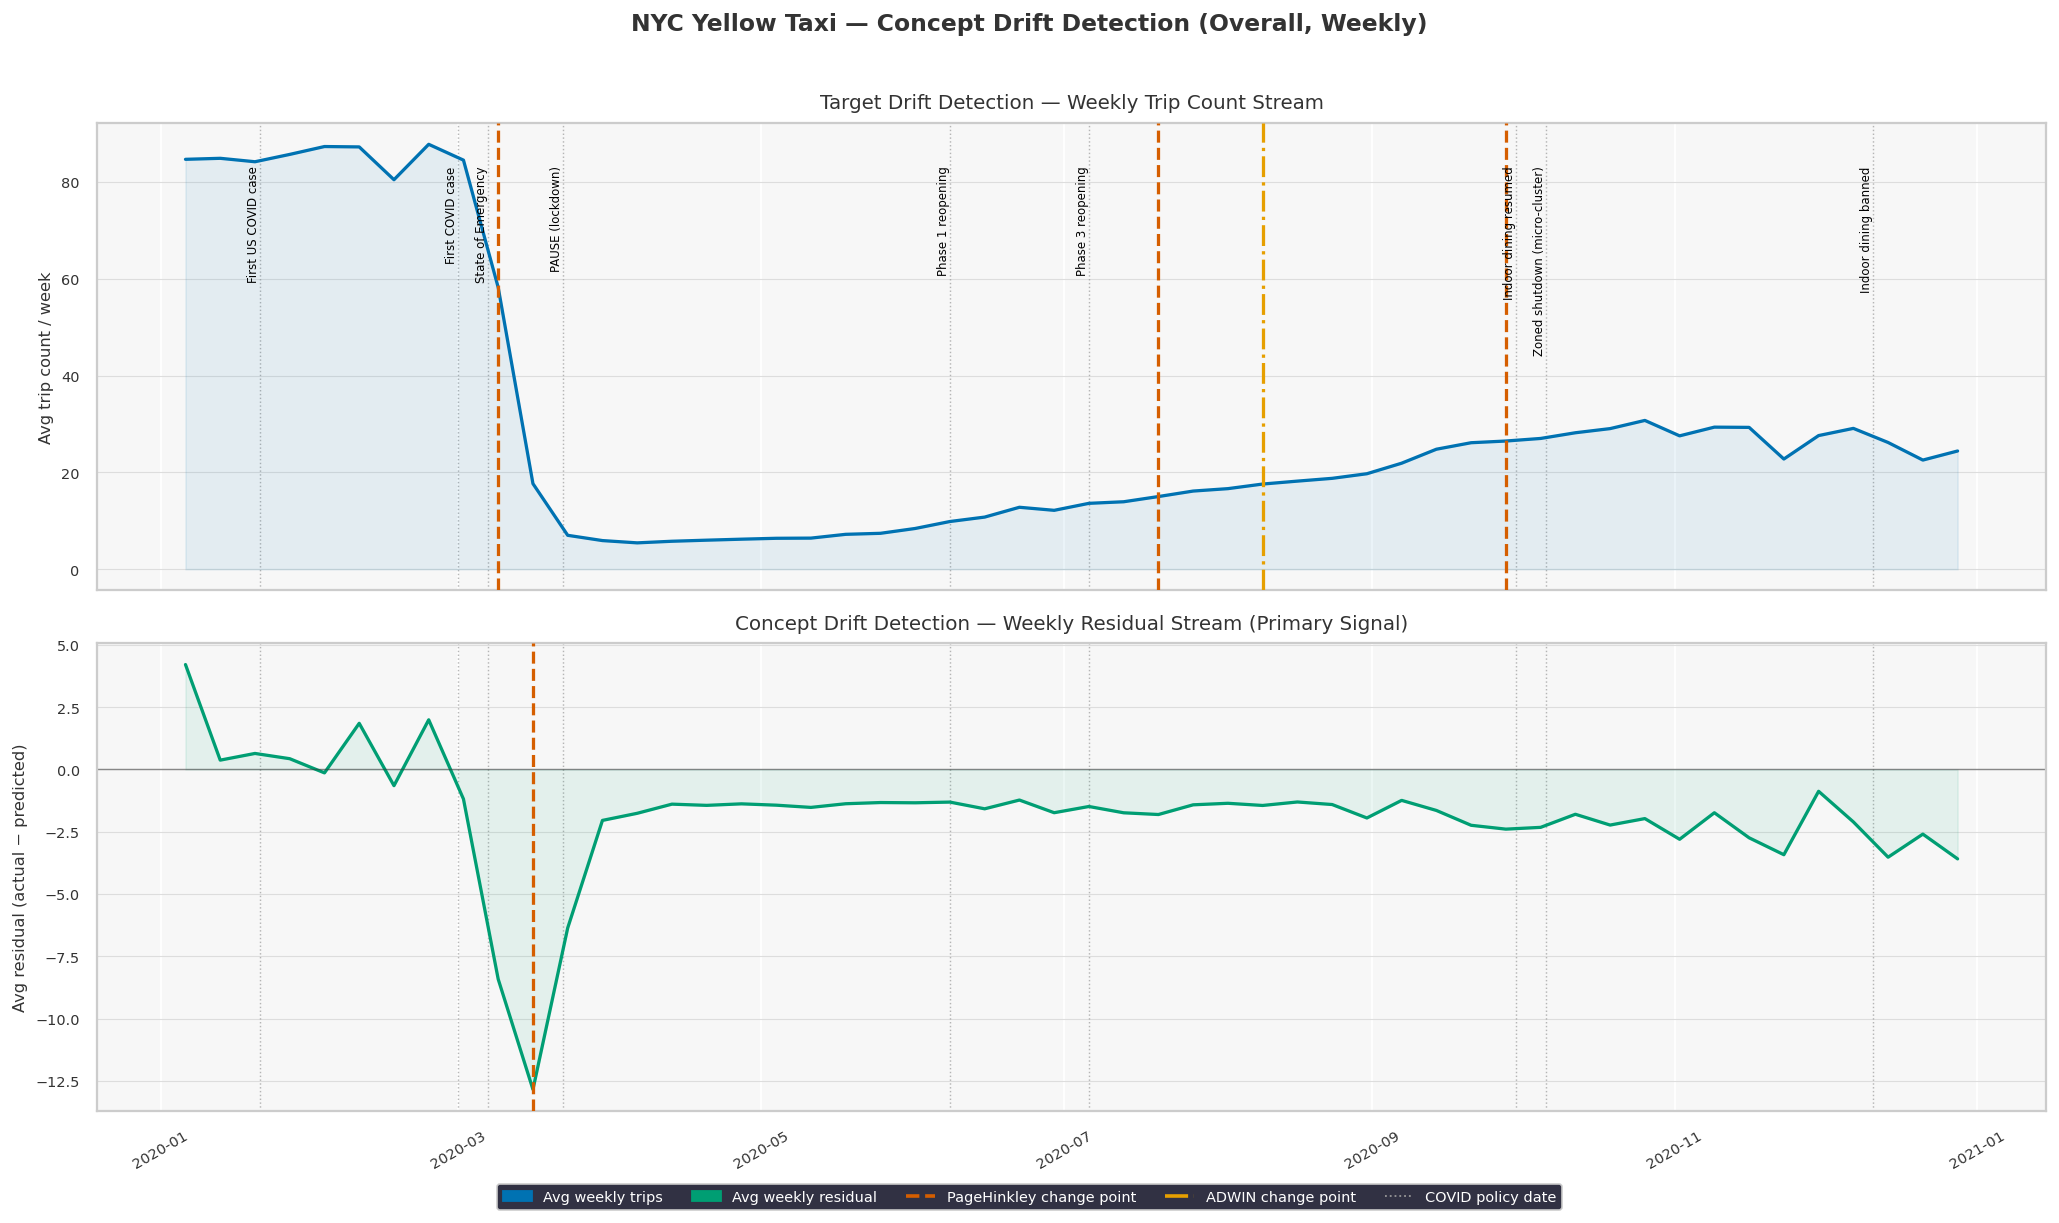

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

# ── Weekly aggregation ────────────────────────────────────────────────────────
df = df_2020_dat_with_trained_feats_only.copy()
df['pickup_hour_ts'] = pd.to_datetime(df['pickup_hour_ts'])
df['week'] = df['pickup_hour_ts'].dt.to_period('W').dt.start_time

weekly = (
    df.groupby('week')
    .agg(
        trip_count = ('trip_count', 'mean'),
        residual   = ('residual',   'mean'),
    )
    .reset_index()
)
weekly['week'] = pd.to_datetime(weekly['week'])

# ── Colour palette (colorblind-friendly) ──────────────────────────────────────
CB = {
    'trip_count' : '#0072B2',   # deep blue
    'residual'   : '#009E73',   # teal
    'ph'         : '#D55E00',   # vermillion — PageHinkley
    'adwin'      : '#E69F00',   # orange — ADWIN
    'covid'      : '#999999',   # grey — policy dates
}

# ── Change points ─────────────────────────────────────────────────────────────
# Filter to Overall only for the overview plot — cleaner narrative
cp_overall = cp_df[cp_df['borough'].isin(['Overall'])].copy()
cp_overall['week'] = pd.to_datetime(cp_overall['week'])

# ── COVID policy dates ────────────────────────────────────────────────────────
covid_dt = {pd.to_datetime(k): v for k, v in COVID_DATES.items()}

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE — two panels stacked: trip count + residual
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
fig.patch.set_facecolor('white')

for ax in axes:
    ax.set_facecolor('#f7f7f7')
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')
    ax.tick_params(colors='#333333', labelsize=8)
    ax.yaxis.label.set_color('#333333')
    ax.grid(axis='y', color='#dddddd', linewidth=0.6)

    # COVID policy date lines — light grey, labelled on top panel only
    for dt, label in covid_dt.items():
        ax.axvline(dt, color=CB['covid'], linewidth=0.8,
                   linestyle=':', alpha=0.7, zorder=1)

def add_change_points(ax, stream_name):
    """Add PageHinkley and ADWIN vertical markers for a given stream."""
    sub = cp_overall[cp_overall['stream'] == stream_name]

    ph    = sub[sub['detector'] == 'PageHinkley']
    adwin = sub[sub['detector'] == 'ADWIN']

    for _, row in ph.iterrows():
        ax.axvline(row['week'], color=CB['ph'], linewidth=1.8,
                   linestyle='--', zorder=3, label='_ph')

    for _, row in adwin.iterrows():
        ax.axvline(row['week'], color=CB['adwin'], linewidth=1.8,
                   linestyle='-.', zorder=3, label='_adwin')

# ── Panel A: Trip Count ───────────────────────────────────────────────────────
ax = axes[0]
ax.plot(weekly['week'], weekly['trip_count'],
        color=CB['trip_count'], linewidth=1.8, label='Avg weekly trips')
ax.fill_between(weekly['week'], weekly['trip_count'],
                alpha=0.08, color=CB['trip_count'])
add_change_points(ax, 'Trip Count')

ax.set_ylabel('Avg trip count / week')
ax.set_title('Target Drift Detection — Weekly Trip Count Stream',
             fontsize=11, pad=8, color='#333333')

# COVID labels on top panel only
label_y = weekly['trip_count'].max() * 0.95
for dt, label in covid_dt.items():
    short = label.replace('NYC ', '').replace('NY ', '')
    ax.text(dt, label_y, short,
            rotation=90, fontsize=6.5, color='black',
            va='top', ha='right')

# ── Panel B: Residual ─────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(weekly['week'], weekly['residual'],
        color=CB['residual'], linewidth=1.8, label='Avg weekly residual')
ax.fill_between(weekly['week'], weekly['residual'],
                alpha=0.08, color=CB['residual'])
ax.axhline(0, color='#333333', linewidth=0.8, linestyle='-', alpha=0.5)
add_change_points(ax, 'Residual')

ax.set_ylabel('Avg residual (actual − predicted)')
ax.set_title('Concept Drift Detection — Weekly Residual Stream (Primary Signal)',
             fontsize=11, pad=8, color='#333333')
ax.tick_params(axis='x', rotation=30)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(color=CB['trip_count'], label='Avg weekly trips'),
    mpatches.Patch(color=CB['residual'],   label='Avg weekly residual'),
    plt.Line2D([0], [0], color=CB['ph'],    linewidth=2,
               linestyle='--', label='PageHinkley change point'),
    plt.Line2D([0], [0], color=CB['adwin'], linewidth=2,
               linestyle='-.', label='ADWIN change point'),
    plt.Line2D([0], [0], color=CB['covid'], linewidth=1,
               linestyle=':',  label='COVID policy date'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           fontsize=8, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('NYC Yellow Taxi — Concept Drift Detection (Overall, Weekly)',
             fontsize=13, fontweight='bold', y=1.01, color='#333333')
plt.tight_layout()
plt.savefig(OUT_DIR / 'concept_drift_detection.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

## Drift vs WMAPE Impact Plot

In [ ]:
def plot_drift_vs_performance(drift_detailed, df_2020_preds, covid_dates, save_path=None):
    """
    Overlay monthly drift signal intensity against monthly WMAPE.
    Makes the drift → degradation relationship explicit.
    """
    # --- Monthly WMAPE from predictions ---
    df = df_2020_preds.copy()
    df['month'] = pd.to_datetime(df['pickup_hour_ts']).dt.to_period('M').astype(str)
    monthly_perf = (
        df.groupby('month')
        .apply(lambda g: pd.Series({
            'wmape': np.abs(g['trip_count'] - g['y_pred']).sum()
                     / g['trip_count'].sum() * 100
        }))
        .reset_index()
    )
    monthly_perf['month_dt'] = pd.to_datetime(monthly_perf['month'])

    # --- Monthly drift intensity: % of feature-month combos flagged as drifted ---
    overall_drift = drift_detailed[drift_detailed['group'] == 'Overall'].copy()
    drift_intensity = (
        overall_drift.groupby('month')
        .apply(lambda g: pd.Series({
            'pct_drifted': (g['drift_label'] != 'STABLE').mean() * 100,
            'pct_significant': (g['drift_label'] == 'SIGNIFICANT DRIFT').mean() * 100
        }))
        .reset_index()
    )
    drift_intensity['month_dt'] = pd.to_datetime(drift_intensity['month'])

    # --- Plot ---
    fig, ax1 = plt.subplots(figsize=(14, 5))
    fig.patch.set_facecolor('white')
    ax1.set_facecolor('#f7f7f7')

    ax2 = ax1.twinx()

    # WMAPE line
    ax1.plot(monthly_perf['month_dt'], monthly_perf['wmape'],
             color='#0072B2', linewidth=2.2, marker='o', markersize=6,
             label='Monthly WMAPE (%)', zorder=4)
    ax1.set_ylabel('WMAPE (%)', color='#0072B2', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='#0072B2')

    # Drift intensity bars
    ax2.bar(drift_intensity['month_dt'], drift_intensity['pct_significant'],
            width=20, color='#D55E00', alpha=0.5, label='% Significant Drift', zorder=2)
    ax2.bar(drift_intensity['month_dt'], drift_intensity['pct_drifted'],
            width=20, color='#E69F00', alpha=0.3, label='% Any Drift',
            bottom=0, zorder=2)
    ax2.set_ylabel('% Features Drifted', color='#D55E00', fontsize=10)
    ax2.tick_params(axis='y', labelcolor='#D55E00')

    # COVID policy lines
    for date_str, label in covid_dates.items():
        ax1.axvline(pd.to_datetime(date_str), color='#999999',
                    linewidth=0.9, linestyle=':', alpha=0.8, zorder=1)

    ax1.axvline(pd.to_datetime('2020-03-01'), color='black',
                linewidth=1.5, linestyle='--', label='COVID-19 (Mar 2020)', zorder=5)

    # Annotations
    ax1.text(pd.to_datetime('2020-03-15'), monthly_perf['wmape'].max() * 0.9,
             'Drift onset\naligns with\nWMAPE spike',
             fontsize=8, color='black',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc='upper left', fontsize=8, framealpha=0.9)

    ax1.set_xlabel('Month')
    ax1.set_title('Data Drift vs Model Performance Degradation — 2020',
                  fontsize=12, fontweight='bold', pad=10)
    ax1.tick_params(axis='x', rotation=30)
    ax1.grid(axis='y', color='#dddddd', linewidth=0.6)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"Saved → {save_path}")
    plt.show()


In [ ]:
# --- Run it ---
plot_drift_vs_performance(
    drift_detailed    = drift_detailed,
    df_2020_preds     = df_2020_dat_with_trained_feats_only,
    covid_dates       = COVID_DATES,
    save_path         = OUT_DIR / 'drift_vs_performance.png'
)

# Section 10: Quarterly Retraining Experiment

In [ ]:
# Design: Detect drift in March 2020 → retrain on Apr-Jun 2020 data
# → evaluate retrained model on Jul-Dec 2020 → compare against baseline model

def train_quarterly_model(train_df, features, target, categorical_cols, params):
    """Train a LightGBM model on a given window of data."""
    df = train_df.dropna(subset=features + [target]).copy()
    X  = df[features].copy()
    y  = df[target].copy()

    for col in categorical_cols:
        if col in X.columns:
            X[col] = X[col].astype('category')

    model = lgb.LGBMRegressor(**params)
    model.fit(X, y,
              categorical_feature=[c for c in categorical_cols if c in X.columns],
              callbacks=[lgb.log_evaluation(period=-1)])  # silent
    return model

In [ ]:
def evaluate_on_window(model, eval_df, features, target, categorical_cols, label):
    """Score a model on a given evaluation window."""
    df = eval_df.dropna(subset=features + [target]).copy()
    X  = df[features].copy()
    y  = df[target].values

    for col in categorical_cols:
        if col in X.columns:
            X[col] = X[col].astype('category')

    preds  = np.clip(model.predict(X), 0, None)
    mae    = mean_absolute_error(y, preds)
    wmape  = np.abs(preds - y).sum() / y.sum() * 100 if y.sum() > 0 else np.nan

    return {"period": label, "mae": round(mae, 3), "wmape": round(wmape, 2),
            "n_rows": len(df), "preds": preds, "actuals": y}



In [ ]:
# ── Define windows ────────────────────────────────────────────────────────────
# Drift detected: March 2020
# Retraining window: April–June 2020 (first full quarter after drift)
# Evaluation window: July–December 2020

mon_full = df_2020_dat_with_trained_feats_only.copy()
mon_full['pickup_hour_ts'] = pd.to_datetime(mon_full['pickup_hour_ts'])

retrain_data = mon_full[
    (mon_full['pickup_hour_ts'] >= '2020-04-01') &
    (mon_full['pickup_hour_ts'] <  '2020-07-01')
].copy()

eval_data = mon_full[
    mon_full['pickup_hour_ts'] >= '2020-07-01'
].copy()

print(f"Retrain window (Apr–Jun 2020): {len(retrain_data):,} rows")
print(f"Evaluation window (Jul–Dec 2020): {len(eval_data):,} rows")

# ── Train retrained model ─────────────────────────────────────────────────────
print("\nTraining retrained model on Apr–Jun 2020...")
retrained_model = train_quarterly_model(
    retrain_data, FEATURES, TARGET, categorical_cols, params
)


In [ ]:
# ── Save retrained model snapshot ────────────────────────────────────────────
with open(MODEL_DIR / "retrained_model_apr_jun_2020.pkl", "wb") as f:
    pickle.dump(retrained_model, f)

save_distribution_snapshot(
    df      = retrain_data,
    features= numerical_features,
    label   = "2020_Q2_retrain",
    save_dir= SNAPSHOT_DIR
)

In [ ]:
# ── Compare baseline vs retrained on Jul–Dec 2020 ────────────────────────────
results_baseline  = evaluate_on_window(
    baseline_model, eval_data, FEATURES, TARGET, categorical_cols,
    label="Baseline (2019-trained) on Jul–Dec 2020"
)
results_retrained = evaluate_on_window(
    retrained_model, eval_data, FEATURES, TARGET, categorical_cols,
    label="Retrained (Apr–Jun 2020) on Jul–Dec 2020"
)


In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
comparison_df = pd.DataFrame([
    {k: v for k, v in results_baseline.items()  if k not in ['preds','actuals']},
    {k: v for k, v in results_retrained.items() if k not in ['preds','actuals']},
])
print("\n── Retraining Impact Summary ──")
print(comparison_df.to_string(index=False))

wmape_improvement = results_baseline['wmape'] - results_retrained['wmape']
print(f"\nWMAPE improvement from retraining: {wmape_improvement:+.1f} percentage points")


In [ ]:
# ── Plot side-by-side ─────────────────────────────────────────────────────────
eval_data = eval_data.copy()
eval_data['month'] = eval_data['pickup_hour_ts'].dt.to_period('M').astype(str)

for label, preds in [('baseline', results_baseline['preds']),
                      ('retrained', results_retrained['preds'])]:
    eval_data[f'y_pred_{label}'] = preds

monthly_compare = (
    eval_data.groupby('month')
    .apply(lambda g: pd.Series({
        'actual':              g['trip_count'].sum(),
        'wmape_baseline':      np.abs(g['y_pred_baseline']  - g['trip_count']).sum()
                               / g['trip_count'].sum() * 100,
        'wmape_retrained':     np.abs(g['y_pred_retrained'] - g['trip_count']).sum()
                               / g['trip_count'].sum() * 100,
    }))
    .reset_index()
)
monthly_compare['month_dt'] = pd.to_datetime(monthly_compare['month'])

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f7f7f7')

x     = np.arange(len(monthly_compare))
width = 0.35

ax.bar(x - width/2, monthly_compare['wmape_baseline'],
       width, color='#0072B2', alpha=0.8, label='Baseline model (2019-trained)')
ax.bar(x + width/2, monthly_compare['wmape_retrained'],
       width, color='#009E73', alpha=0.8, label='Retrained model (Apr–Jun 2020)')

ax.set_xticks(x)
ax.set_xticklabels(monthly_compare['month'], rotation=30, ha='right')
ax.set_ylabel('WMAPE (%)')
ax.set_title('Baseline vs Retrained Model — Monthly WMAPE (Jul–Dec 2020)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', color='#dddddd', linewidth=0.6)

plt.tight_layout()
plt.savefig(OUT_DIR / 'retraining_comparison.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# Save results
comparison_df.to_csv(DRIFT_DIR / 'retraining_impact_summary.csv', index=False)
monthly_compare.to_csv(DRIFT_DIR / 'retraining_monthly_comparison.csv', index=False)
print("Saved retraining results")